In [2]:
import pandas as pd

df = pd.read_csv ('participant_content.csv')

In [3]:
df = df[df.userContent == 1]
df

,sessionId,treatmentArm,participantCode,profilePicture,firstName,lastName,bio,postOrCommentId,userContent,staticContent,dynamicContent,postOrCommentText,postOrCommentDate,postLikes,postDislikes,participantLiked,participantDisliked,parentPost,previousCommentOrPost,dwellTimeInSeconds
44,657896b96d158d001f181516,imm_treat,8gch37,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,Yelena22,NaN,NC girl,657898246d158d001f18395d,1,0,0,Yes! People are so closed-minded. America was ...,2023-12-12T17:28:03.930Z,NaN,NaN,NaN,NaN,654e2ecbf18dbd001f7aaf46,654e2ecbf18dbd001f7aaf46,0
95,657896b96d158d001f181516,imm_treat,8gch37,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,Yelena22,NaN,NC girl,657899456d158d001f185f72,1,0,0,As if there aren’t millions of citizens using ...,2023-12-12T17:32:53.700Z,NaN,NaN,NaN,NaN,654e2ecdf18dbd001f7ab3ec,654e2ecdf18dbd001f7ab3ec,0
103,657896b96d158d001f181516,imm_treat,8gch37,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,Yelena22,NaN,NC girl,657897ad6d158d001f1824be,1,0,0,Most Americans wouldn’t be able to pass the im...,2023-12-12T17:26:05.474Z,5.0,1.0,0.0,0.0,NaN,NaN,66
184,6578987d6d158d001f1847ac,gc_control3,nyuhem,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,SFon85,NaN,"Hello, I'm a 38 year old married man. I love ...",65789b036d158d001f188a87,1,0,0,I honestly think people should have to have a ...,2023-12-12T17:40:19.333Z,6.0,4.0,0.0,0.0,NaN,NaN,105
185,6578987d6d158d001f1847ac,gc_control3,nyuhem,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,SFon85,NaN,"Hello, I'm a 38 year old married man. I love ...",65789bb66d158d001f18b972,1,0,0,People's rights are infringed every day. Felo...,2023-12-12T17:43:18.590Z,NaN,NaN,NaN,NaN,65789b036d158d001f188a87,65789b036d158d001f188a87,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104317,657b61122855e7001f93f0ef,imm_control3,pqdpcp,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,Cbros,NaN,Baba,657b62628b12dc001f05d62b,1,0,0,"20,000,000 illegal immigrants this year alone",2023-12-14T20:15:32.087Z,3.0,3.0,0.0,0.0,NaN,NaN,0
104351,657b64a78b12dc001f06215b,imm_control3,h63zav,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,Shan,NaN,"Jersey girl, born and raised!!! I love animals...",657b65a88b12dc001f069f70,1,0,0,Our society is being washed away right in fron...,2023-12-14T20:29:28.539Z,NaN,NaN,NaN,NaN,655d0ae8f1c1b5001f5cb577,655d0ae8f1c1b5001f5cb577,0
104353,657b64a78b12dc001f06215b,imm_control3,h63zav,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,Shan,NaN,"Jersey girl, born and raised!!! I love animals...",657b66162855e7001f9554e3,1,0,0,I can agree with that but there needs to be a ...,2023-12-14T20:31:18.583Z,NaN,NaN,NaN,NaN,655d0ae8f1c1b5001f5cb577,657b65bd8b12dc001f06b363,0
104407,657b64a78b12dc001f06215b,imm_control3,h63zav,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,Shan,NaN,"Jersey girl, born and raised!!! I love animals...",657b66cb8b12dc001f07eca7,1,0,0,"The over crowding, congestion and increased de...",2023-12-14T20:34:19.040Z,0.0,3.0,0.0,0.0,NaN,NaN,0


In [1]:
! pip install pyzipcode
! pip install matplotlib-venn

In [2]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import seaborn as sb
import matplotlib.pyplot as plt
from pyzipcode import ZipCodeDatabase
from numpy import nan
from collections import Counter
from nltk.tokenize import TweetTokenizer
tknzr = TweetTokenizer()
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk
nltk.download('vader_lexicon')
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')
nltk.download('stopwords')
from nltk.corpus import stopwords
from datetime import datetime
import statsmodels.formula.api as smf

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Austin\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Austin\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Austin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [3]:
def third_order_f(x):

    qs = ['third_order_A1', 'third_order_A2',
          'third_order_B1', 'third_order_B2']

    return sum([x[i] if pd.notnull(x[i]) else 0 for i in qs])


def pos_aff(x):

    d = {"Very slightly or not at all": 0,
         "A little": 1,
         "Moderately": 2,
         "Quite a bit": 3,
         "Extremely": 4}

    score = 0

    for q in ['active', 'attentive', 'alert', 'determined', 'inspired']:
        if pd.notnull(x['panas_' + q]):
          score += d[x['panas_' + q]]
        else:
          return None

    return score

def neg_aff(x):

    d = {"Very slightly or not at all": 0,
         "A little": 1,
         "Moderately": 2,
         "Quite a bit": 3,
         "Extremely": 4}

    score = 0

    for q in ['hostile', 'ashamed', 'upset', 'afraid', ]:
        if pd.notnull(x['panas_' + q]):
          score += d[x['panas_' + q]]
        else:
          return None

    return score

def smu(x):
    #if sum([pd.isnull(x['platforms_{}_n'.format(i)]) for i in ['fb', 'insta', 'tiktok', 'truth', 'x']]) != 0:
    #    return None
    #else:
    return sum([x['platforms_{}_n'.format(i)] for i in ['fb', 'insta', 'tiktok', 'truth', 'x']])

In [4]:
new_codes = {'56e130548b1c33000a388671': 'VATZ46',
             '6287f4819c5fc8c4d48cc885': 'AVX9QE',
             '601d69a993d94008fb2b25dc': 'YWTGUB',
             '650464007006929ee0cd9695': 'ZWTG94',
             '614ce6a7a33bac955957f7a6': 'TPZZQA',
             '6317511c1dd0acb82cf4b131': 'VQWK3M',
             '5e3ae8e5ebfb032f9058ef33': 'KB39HV',
             '6554d0515dc2a90a0f6b3ae3': 'VNPHMU',
             '5ec59e86c9569f5e8000717b': 'ZN3EYY',
             '5ee834d45f0f48129a79b683': 'UGED4M'}

drops = {'a43n36','a6punv','84z39x','9eemkf','7wgznu','xx43nc'}

intake = pd.read_csv("intake.csv").dropna(subset="participant_code")
intake['participant_code'] = intake.apply(lambda x: x['participant_code'] if x['PROLIFIC_PID'] not in new_codes else new_codes[x['PROLIFIC_PID']], axis=1)
intake['participant_code'] = intake.participant_code.apply(lambda x: x.lower())

d = {"Not at all": 0,
     "Some": 1,
     "A lot": 2}

for plat in ['fb', 'insta', 'tiktok', 'truth', 'x']:
    intake['platforms_{}_n'.format(plat)] = intake['platforms_{}'.format(plat)].apply(lambda x: d[x] if pd.notnull(x) else None)
    
    
intake['smu'] = intake.apply(lambda x: smu(x), axis=1)

pretreat = pd.read_csv("pre.csv")
pretreat['treatment'] = pretreat.treatment_arm.apply(lambda x: int(x[-5:] == "treat"))
    

posttreat = pd.read_csv("post.csv")
posttreat['third_order'] = posttreat.apply(third_order_f, axis=1)
posttreat['panas_neg'] = posttreat.apply(neg_aff, axis=1)
posttreat['panas_pos'] = posttreat.apply(pos_aff, axis=1)
posttreat['panas'] = posttreat.panas_pos - posttreat.panas_neg

df = posttreat.merge(pretreat, on="participant_code", suffixes=('_post', '_pre'))
df = df.merge(intake, on="participant_code")
df = df[[i not in drops for i in df.participant_code]]

condition = {'imm_treat': "treat",
             'gc_treat': "treat",
             'imm_pc': "pure_control",
             'gc_pc': "pure_control",
             "imm_control1": "control",
             "imm_control2": "control",
             "imm_control3": "control",
             "gc_control1": "control",
             "gc_control2": "control",
             "gc_control3": "control"}

df['condition'] = df.treatment_arm.apply(lambda x: condition[x])

d = {'Not at all well': 0,'Not too well': 1,'Somewhat well': 2,'Very well': 3,'Extremely well': 4}

pre_ih = []
post_ih = []
delta_ih = []

for i, row in df.iterrows():
  pre = []
  post = []
  for i in range(1,7):
    if (row['pre_ih_' + str(i)] != None) and pd.notnull(row['pre_ih_' + str(i)]):
      pre.append(d[row['pre_ih_' + str(i)]])
    else:
      pre.append(None)
    if (row['post_ih_' + str(i)] != None) and pd.notnull(row['post_ih_' + str(i)]):
      post.append(d[row['post_ih_' + str(i)]])
    else:
      post.append(None)
  if None not in pre:
    pre_ih.append(sum(pre))
  else:
    pre_ih.append(None)
  if None not in post:
    post_ih.append(sum(post))
  else:
    post_ih.append(None)
  if (None not in pre) and (None not in post):
    delta_ih.append(sum(post) - sum(pre))
  else:
    delta_ih.append(None)


df['pre_ih'] = pre_ih
df['post_ih'] = post_ih
df['delta_ih'] = delta_ih

df

df = df[df.condition != "pure_control"]

# Demographics

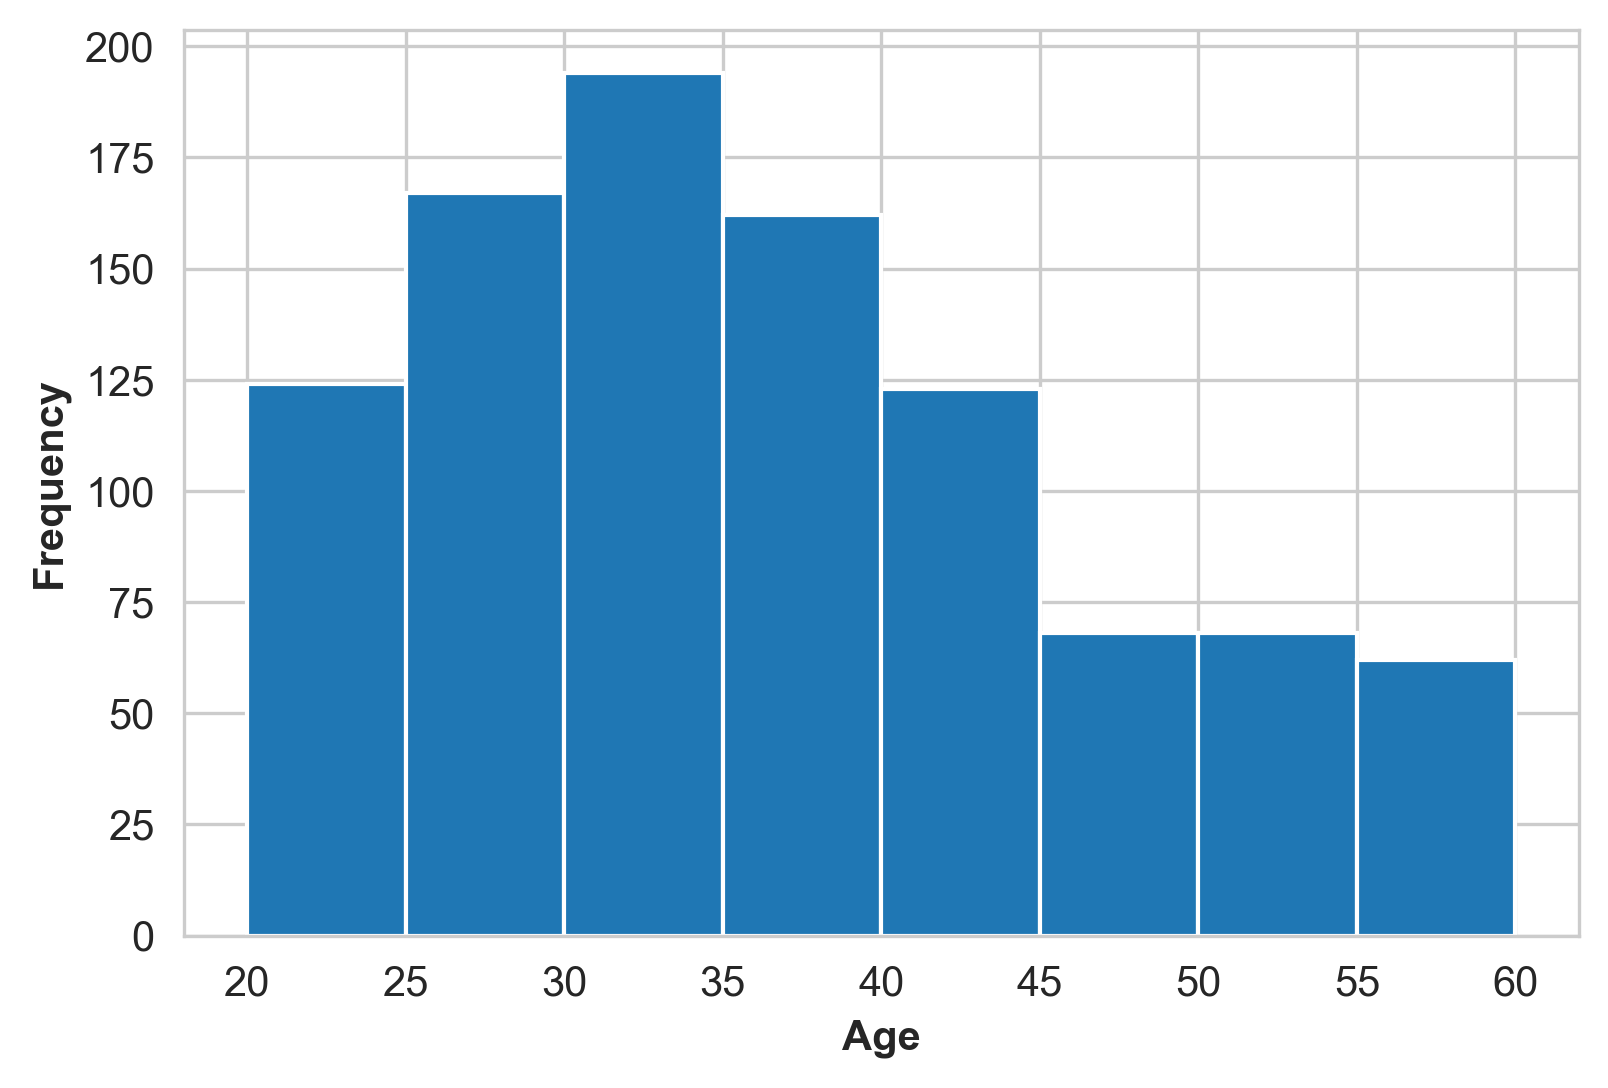

37.52732502396932
35.0


In [5]:
plt.figure(dpi=300)
sb.set_style("whitegrid")
plt.hist(df.age, bins=[20,25,30,35,40,45,50,55,60])
plt.xlabel("Age", fontweight="bold")
plt.ylabel("Frequency", fontweight="bold")
plt.show()
print(np.mean(df.dropna(subset=['age']).age))
print(np.median(df.dropna(subset=['age']).age))

In [6]:
min(df.age), max(df.age)

(18.0, 78.0)

In [7]:
race_new = []
for i, row in df.iterrows():
  if row['race '] == "Hispanic,White":
    race_new.append('Hispanic')
  elif row['race '] == "Something else":
    race_new.append("Mixed/Other")
  elif len(row['race '].split(',')) > 1:
    race_new.append('Mixed/Other')
  else:
    race_new.append(row['race '])

df['race_new'] = race_new
print(df.groupby('race_new').size())
print()
print(df.groupby('race_new').size()/len(df))

race_new
Asian                         93
Black or African American    158
Hispanic                      94
Mixed/Other                   73
White                        625
dtype: int64

race_new
Asian                        0.089166
Black or African American    0.151486
Hispanic                     0.090125
Mixed/Other                  0.069990
White                        0.599233
dtype: float64


In [8]:
print(df.groupby('pid3').size())
print()
print(df.groupby('pid3').size()/len(df))

pid3
Democrat       498
Independent    307
Other           41
Republican     197
dtype: int64

pid3
Democrat       0.477469
Independent    0.294343
Other          0.039310
Republican     0.188878
dtype: float64


In [9]:
pid7 = []
for i, row in df.iterrows():
  if row['pid3'] in ['Other', 'Independent']:
    if row['pid_lean'] == "Closer to Republican Party":
      pid7.append("Lean Republican")
    elif row['pid_lean'] == 'Closer to Democratic Party':
      pid7.append("Lean Democrat")
    elif row['pid_lean'] == "Neither":
      pid7.append("True Independent/Other")
    else:
      pid7.append("N/A")
  elif row['pid3'] == "Republican":
    if row['pid_strong'] == "Not very strong ${q://QID41/ChoiceGroup/SelectedChoices}":
      pid7.append("Weak Republican")
    elif row['pid_strong'] == 'Strong ${q://QID41/ChoiceGroup/SelectedChoices}':
      pid7.append("Strong Republican")
    else:
      pid7.append("N/A")
  elif row['pid3'] == "Democrat":
    if row['pid_strong'] == "Not very strong ${q://QID41/ChoiceGroup/SelectedChoices}":
      pid7.append("Weak Democrat")
    elif row['pid_strong'] == 'Strong ${q://QID41/ChoiceGroup/SelectedChoices}':
      pid7.append("Strong Democrat")
    else:
      pid7.append("N/A")
  else:
    print(row['pid3'])

df['pid7'] = pid7

print(df.groupby('pid7').size())
print()
print(df.groupby('pid7').size()/len(df))

pid7
Lean Democrat             141
Lean Republican            52
Strong Democrat           268
Strong Republican          85
True Independent/Other    155
Weak Democrat             230
Weak Republican           112
dtype: int64

pid7
Lean Democrat             0.135187
Lean Republican           0.049856
Strong Democrat           0.256951
Strong Republican         0.081496
True Independent/Other    0.148610
Weak Democrat             0.220518
Weak Republican           0.107383
dtype: float64


In [10]:
print(df.groupby('ideo7').size())
print()
print(df.groupby('ideo7').size()/len(df))

ideo7
Conservative                       97
Extremely conservative             35
Extremely liberal                 173
Liberal                           251
Moderate or middle of the road    241
Somewhat conservative              97
Somewhat liberal                  149
dtype: int64

ideo7
Conservative                      0.093001
Extremely conservative            0.033557
Extremely liberal                 0.165868
Liberal                           0.240652
Moderate or middle of the road    0.231064
Somewhat conservative             0.093001
Somewhat liberal                  0.142857
dtype: float64


In [197]:
0.165868 + 0.240652 + 0.142857

0.549377

In [11]:
new_educ = []

for i, row in df.iterrows():
  for n in range(1,10):
    if pd.notnull(row['educ_' + str(n)]):
      new_educ.append(row['educ_' + str(n)])

df['new_educ'] = new_educ
print(df.groupby('new_educ').size())
print()
print(df.groupby('new_educ').size()/len(df))

new_educ
Associate degree in college                 128
Bachelor’s degree                           356
High school graduate or equivalent (GED)    145
Less than high school                        13
Post-graduate degree                        137
Some college but no degree                  264
dtype: int64

new_educ
Associate degree in college                 0.122723
Bachelor’s degree                           0.341323
High school graduate or equivalent (GED)    0.139022
Less than high school                       0.012464
Post-graduate degree                        0.131352
Some college but no degree                  0.253116
dtype: float64


In [12]:
d = {"Less than high school": 1,
     "High school graduate or equivalent (GED)": 2,
     "Some college but no degree": 3,
     "Associate degree in college": 4,
     "Bachelor’s degree": 5,
     "Post-graduate degree": 6}

df['new_educ_num'] = df.new_educ.apply(lambda x: d[x] if x in d else None)

# Time spent completing study

1202.653883029722
877.0


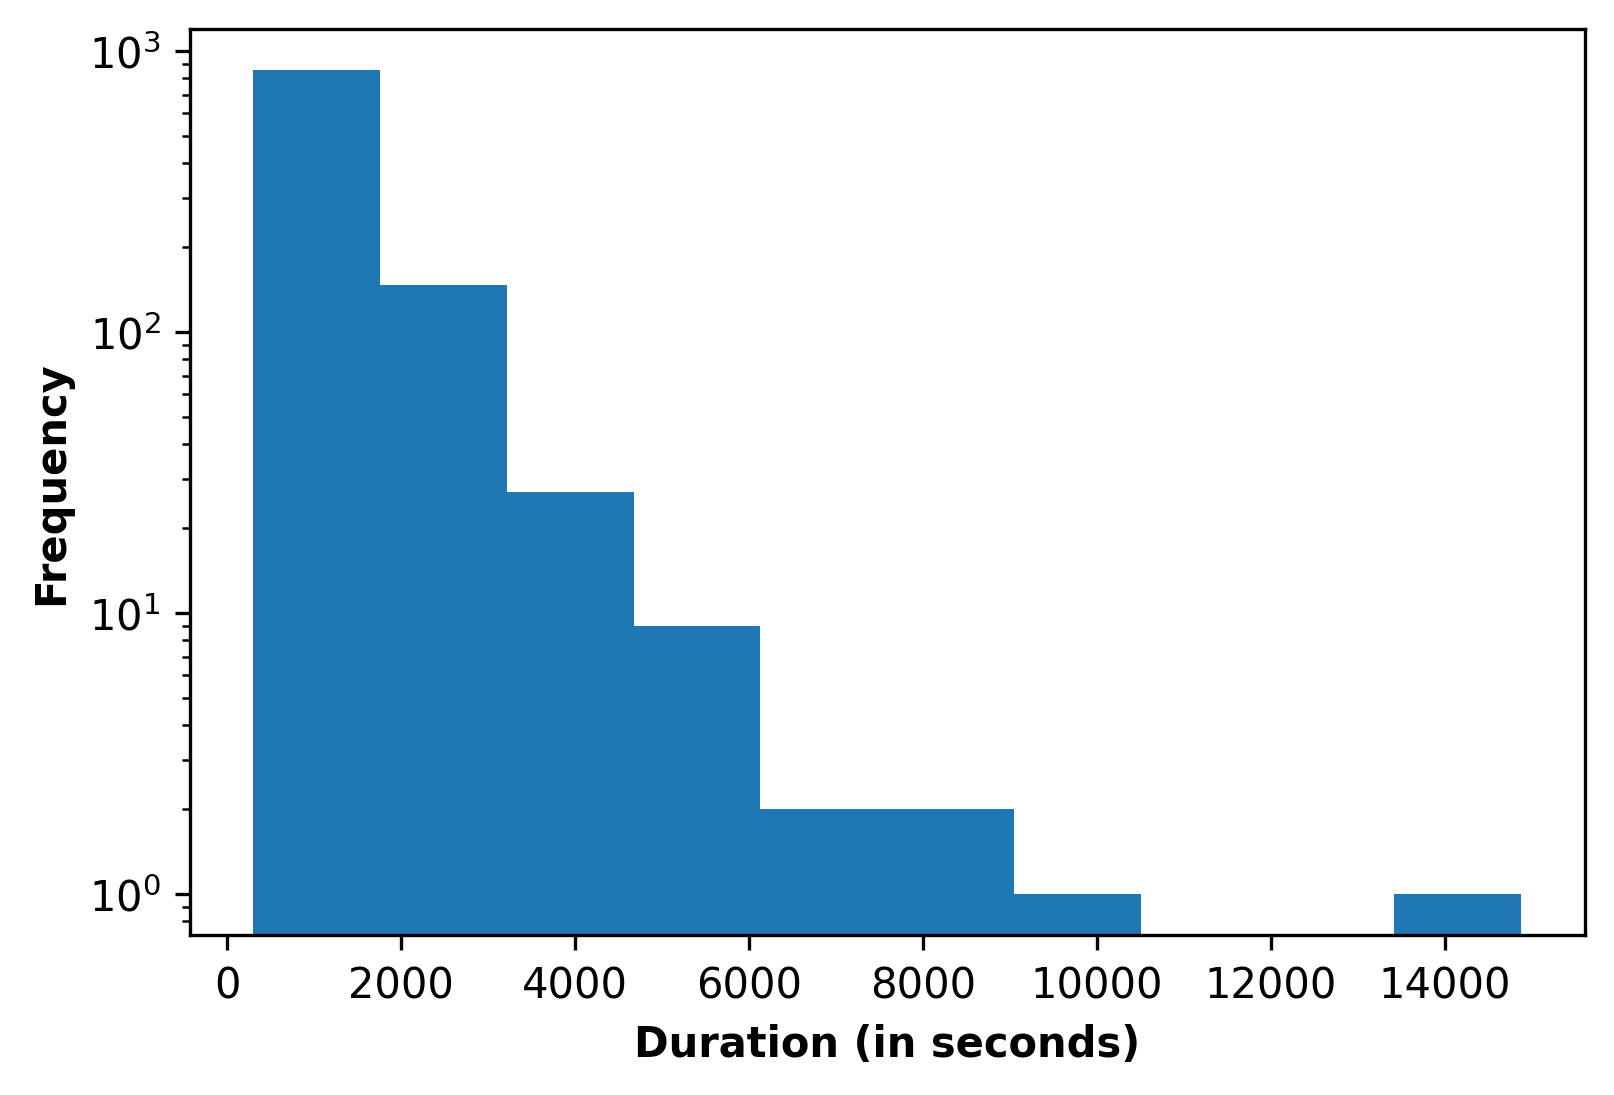

In [13]:
plt.figure(dpi=300)
plt.rcdefaults()
df['total_duration'] = df["Duration (in seconds)_post"] + df["Duration (in seconds)_pre"] + df["Duration (in seconds)"]
print(np.mean(df.total_duration))
print(np.median(df.total_duration))
plt.hist(df.total_duration)
plt.xlabel("Duration (in seconds)", fontweight="bold")
plt.ylabel("Frequency", fontweight="bold")
plt.yscale('log')
plt.show()

In [201]:
877.0 / 60

14.616666666666667

1202.653883029722
877.0


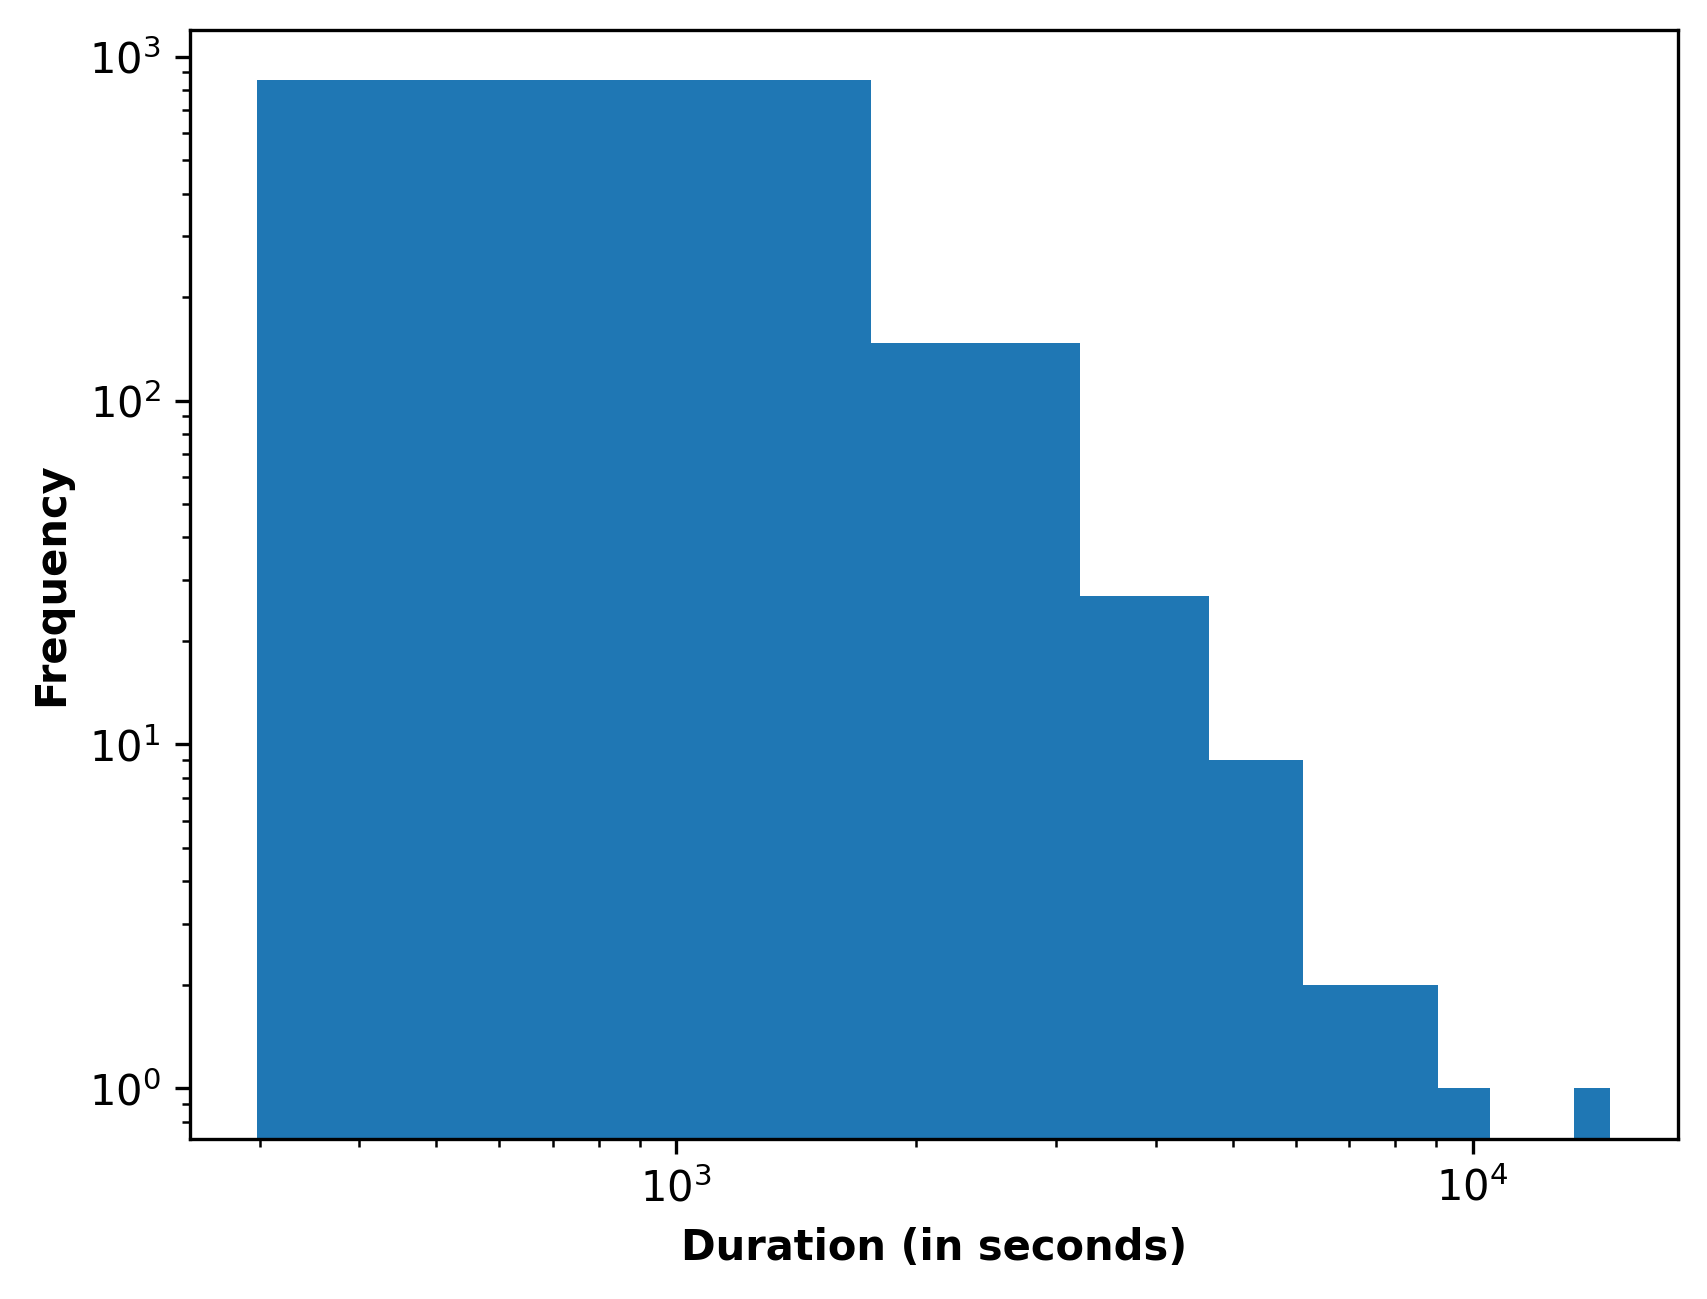

In [14]:
plt.figure(dpi=300)
plt.rcdefaults()
df['total_duration'] = df["Duration (in seconds)_post"] + df["Duration (in seconds)_pre"] + df["Duration (in seconds)"]
print(np.mean(df.total_duration))
print(np.median(df.total_duration))
plt.hist(df.total_duration)
plt.xlabel("Duration (in seconds)", fontweight="bold")
plt.ylabel("Frequency", fontweight="bold")
plt.yscale('log')
plt.xscale('log')
plt.show()

# ZIP code / state match

In [15]:
zcdb = ZipCodeDatabase()
state_abb = {"AL":"Alabama","AK":"Alaska","AZ":"Arizona","AR":"Arkansas","CA":"California","CO":"Colorado",
          "CT":"Connecticut","DE":"Delaware","FL":"Florida","GA":"Georgia","HI":"Hawaii","ID":"Idaho",
          "IL":"Illinois","IN":"Indiana","IA":"Iowa","KS":"Kansas","KY":"Kentucky","LA":"Louisiana","ME":"Maine",
          "MD":"Maryland","MA":"Massachusetts","MI":"Michigan","MN":"Minnesota","MS":"Mississippi","MO":"Missouri",
          "MT":"Montana","NE":"Nebraska","NV":"Nevada","NH":"New Hampshire","NJ":"New Jersey","NM":"New Mexico",
          "NY":"New York","NC":"North Carolina","ND":"North Dakota","OH":"Ohio","OK":"Oklahoma","OR":"Oregon",
          "PA":"Pennsylvania","RI":"Rhode Island","SC":"South Carolina","SD":"South Dakota","TN":"Tennessee","TX":"Texas",
          "UT":"Utah","VT":"Vermont","VA":"Virginia","WA":"Washington","WV":"West Virginia","WI":"Wisconsin","WY":"Wyoming",
          "DC": "District of Columbia", "PR": "Puerto Rico"}

# ZIP codes that are not in the database for some reason
other_zips = {'77407': "TX",
              '85756': "AZ",
              '49519': "MI",
              "34638": "FL",
              "25405": "WV",
              "10065": "NY",
              "89183": "NV",
              "89178": "NV",
              "85143": "AZ",
              "85140": "AZ",
              "32163": "FL",
              "85119": "AZ",
              "29486": "SC",
              "85142": "AZ",
              "60169": "IL",
              "98391": "WA",
              "80923": "CO"}

# ZIP codes that are processed incorrectly
change_zips = {"7086": "07086",
               "7712": "07712"}

zip_state = []

for i, row in df.iterrows():
  #print(i)
  x = str(int(row['zip']))
  if x in change_zips:
    x = change_zips[x]
    zip_state.append(state_abb[zcdb[str(int(x))].state])
  elif x in zcdb:
    zip_state.append(state_abb[zcdb[str(int(x))].state])
  elif x in other_zips:
    zip_state.append(state_abb[other_zips[str(int(x))]])
  else:
    zip_state.append(None)

df['zip_state'] = zip_state

In [16]:
df[['zip','zip_state','state']]

,zip,zip_state,state
0,27265.0,North Carolina,North Carolina
2,52353.0,Iowa,Iowa
5,6354.0,Connecticut,Connecticut
6,95315.0,California,California
10,30518.0,Georgia,Georgia
...,...,...,...
1538,80923.0,Colorado,Colorado
1540,12590.0,New York,New York
1542,77388.0,Texas,Texas
1544,30058.0,Georgia,Georgia


In [17]:
df[df.zip_state != df.state][['zip','zip_state','state']]

,zip,zip_state,state
268,7712.0,New Jersey,New York
497,10486.0,None,New York
502,20147.0,Virginia,New Jersey
567,42101.0,Kentucky,Indiana
1064,0.0,None,California
1157,90210.0,California,New Hampshire
1197,35601.0,Alabama,South Dakota
1327,29575.0,South Carolina,South Dakota
1491,90289.0,None,California
1497,90268.0,None,California


In [18]:
sum(df.zip_state == df.state)/len(df)

0.9904122722914669

# Why were posts highlighted?

In [19]:
pd.crosstab(df.manip_check, df.condition)

condition,control,treat
manip_check,,
"The degree to which the user is ""popular"", or the degree to which they are able to achieve ""likes"".",439,34
The degree to which users respectfully engage with and learn from differing opinions.,25,476
There were no user badges on the platform.,33,36


In [20]:
sum(sum(pd.crosstab(df.manip_check, df.condition).values))

1043

In [21]:
(439 + 476)/1043

0.8772770853307766

# Which post would get more likes? 

In [22]:
third_order = pd.read_csv('third-order.csv')
third_order['nas'] = third_order.apply(lambda x: sum(pd.isnull([x[i] for i in ['third_order_A1', 'third_order_A2', 
                                                                          'third_order_B1', 'third_order_B2']])), axis=1)
third_order = third_order[third_order.nas < 4]
df = df.drop(columns=['third_order_A1','third_order_A2',
                           'third_order_B1','third_order_B2']).merge(third_order.drop(columns="nas"), on="participant_code")
df['third_order'] = df.apply(lambda x: sum(x[['third_order_A1','third_order_A2',
                           'third_order_B1','third_order_B2']].fillna(0)), axis=1)
df

,StartDate_post,EndDate_post,Status_post,IPAddress_post,Progress_post,Duration (in seconds)_post,Finished_post,RecordedDate_post,ResponseId_post,RecipientLastName_post,...,race_new,pid7,new_educ,new_educ_num,total_duration,zip_state,third_order_A1,third_order_A2,third_order_B1,third_order_B2
0,12/12/2023 10:34,12/12/2023 10:37,IP Address,71.71.112.54,100,217,True,12/12/2023 10:37,R_2ARnUkZ40c702IE,NaN,...,White,Strong Democrat,Associate degree in college,4,388,North Carolina,NaN,NaN,1.0,1.0
1,12/12/2023 10:46,12/12/2023 10:52,IP Address,172.58.10.215,100,374,True,12/12/2023 10:52,R_27amtKO2JE7Iho9,NaN,...,Hispanic,Lean Republican,High school graduate or equivalent (GED),2,2408,Iowa,1.0,1.0,NaN,NaN
2,12/12/2023 10:47,12/12/2023 10:56,IP Address,66.212.218.70,100,520,True,12/12/2023 10:56,R_2Cy58sTvdtprJbm,NaN,...,White,Weak Democrat,Some college but no degree,3,911,Connecticut,0.0,0.0,NaN,NaN
3,12/12/2023 10:55,12/12/2023 11:00,IP Address,68.116.85.163,100,260,True,12/12/2023 11:00,R_3QXJjMxRbpGVqnN,NaN,...,White,Lean Democrat,Some college but no degree,3,632,California,1.0,0.0,NaN,NaN
4,12/12/2023 10:52,12/12/2023 11:06,IP Address,174.215.176.210,100,885,True,12/12/2023 11:06,R_2YLnKFzaVR8F7Mj,NaN,...,Black or African American,Weak Democrat,Some college but no degree,3,1274,Georgia,NaN,NaN,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1038,12/12/2023 11:18,12/12/2023 11:25,IP Address,73.3.224.41,93,434,False,12/15/2023 0:33,R_1ddeajwrFRZrG73,NaN,...,White,Lean Republican,Associate degree in college,4,761,Colorado,NaN,NaN,1.0,1.0
1039,12/12/2023 11:59,12/12/2023 12:02,IP Address,100.40.186.229,93,189,False,12/15/2023 0:33,R_27fMb9wZPSEktas,NaN,...,White,Lean Republican,Bachelor’s degree,5,1028,New York,NaN,NaN,1.0,1.0
1040,12/12/2023 11:32,12/12/2023 11:35,IP Address,172.56.15.42,93,197,False,12/15/2023 0:33,R_2ZKzyLxSf1s9NeJ,NaN,...,Hispanic,Weak Democrat,Bachelor’s degree,5,538,Texas,1.0,0.0,NaN,NaN
1041,12/13/2023 13:25,12/13/2023 13:29,IP Address,24.99.26.176,93,222,False,12/15/2023 0:33,R_15KKEVD99jKy9Di,NaN,...,Black or African American,Weak Democrat,Bachelor’s degree,5,745,Georgia,NaN,NaN,1.0,1.0


In [23]:
stats.mannwhitneyu(df[df.condition == "treat"].dropna(subset=['third_order']).third_order,
                   df[df.condition == "control"].dropna(subset=['third_order']).third_order)

MannwhitneyuResult(statistic=148052.5, pvalue=0.002952331408492987)

In [24]:
stats.ttest_ind(df[df.condition == "treat"].dropna(subset=['third_order']).third_order,
                   df[df.condition == "control"].dropna(subset=['third_order']).third_order)

Ttest_indResult(statistic=3.350797087689167, pvalue=0.0008347342181353903)

In [25]:
df[df.condition == "treat"].third_order.mean()

1.5732600732600732

In [26]:
df[df.condition == "control"].third_order.mean()

1.4265593561368208

In [27]:
print(len(df[(df.condition == "treat")&(df.third_order == 0)])/len(df[(df.condition == "treat")]))
print(len(df[(df.condition == "treat")&(df.third_order == 1)])/len(df[(df.condition == "treat")]))
print(len(df[(df.condition == "treat")&(df.third_order == 2)])/len(df[(df.condition == "treat")]))

0.09157509157509157
0.24358974358974358
0.6648351648351648


In [28]:
print(len(df[(df.condition == "control")&(df.third_order == 0)])/len(df[(df.condition == "control")]))
print(len(df[(df.condition == "control")&(df.third_order == 1)])/len(df[(df.condition == "control")]))
print(len(df[(df.condition == "control")&(df.third_order == 2)])/len(df[(df.condition == "control")]))

0.16498993963782696
0.24346076458752516
0.5915492957746479


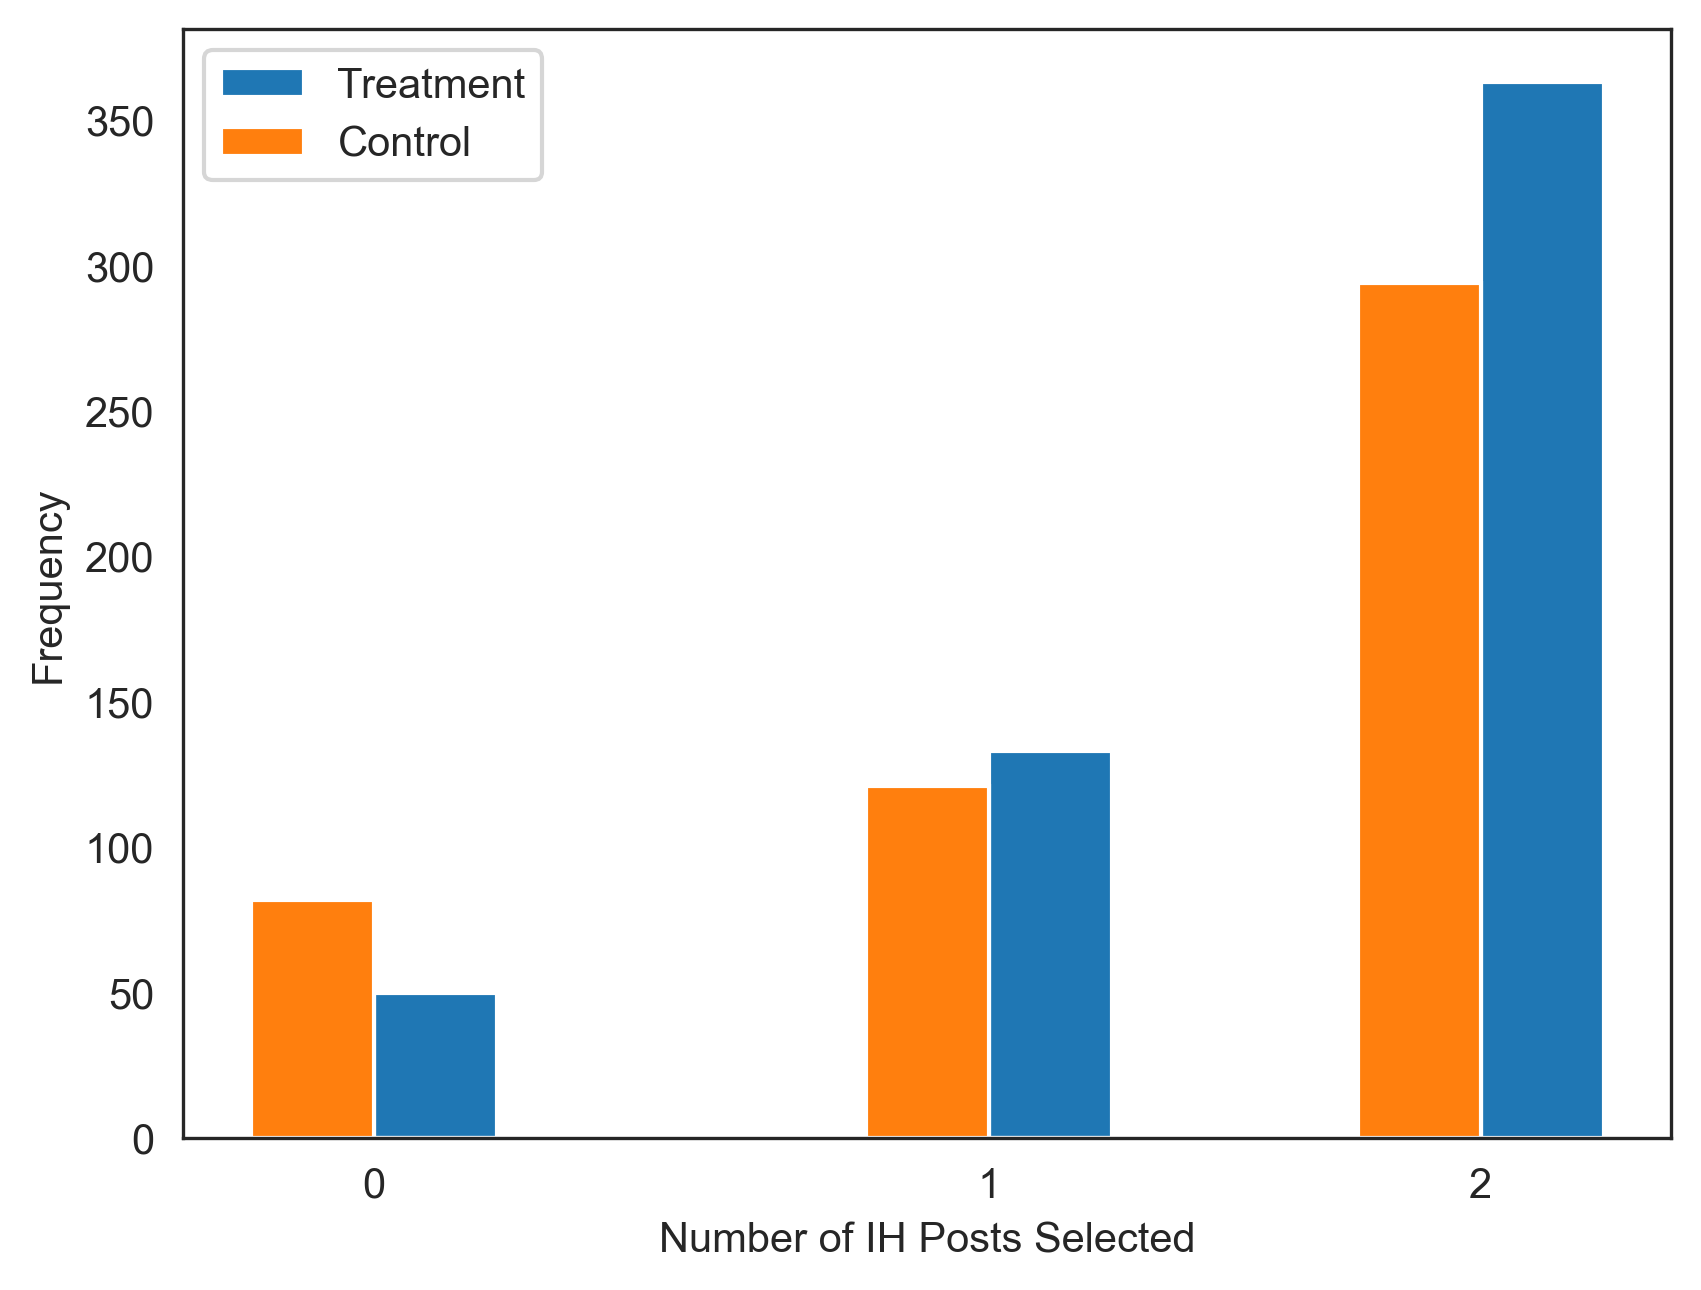

In [29]:
sb.set_style("white")
plt.figure(dpi=300)
plt.hist(df[df.condition == "treat"].third_order, label="Treatment")
plt.hist(df[df.condition == "control"].third_order-0.2, label="Control")
plt.xticks([0,1,1.8],['0','1','2'])
plt.xlabel("Number of IH Posts Selected")
plt.ylabel("Frequency")
plt.legend()

Text(0.5, 0, 'Condition')

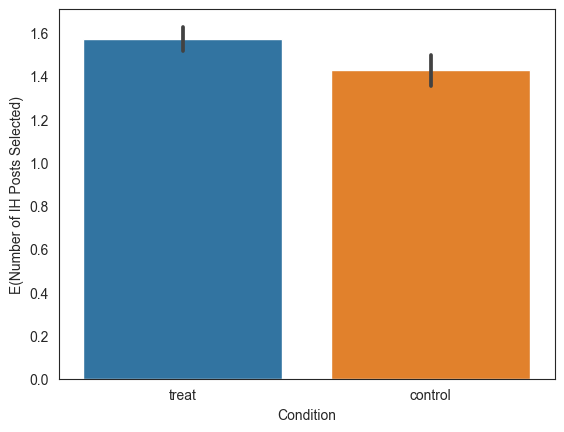

In [30]:
sb.barplot(data=df[df.condition != "pure_control"],
          x = "condition",
          y = "third_order")
plt.ylabel("E(Number of IH Posts Selected)")
plt.xlabel("Condition")

## Subgroup Analysis

In [31]:
df_ = df[df.pid3 == "Democrat"]

x1 = df_[df_.condition == "treat"].dropna(subset=['third_order']).third_order
x2 = df_[df_.condition == "control"].dropna(subset=['third_order']).third_order
x_pooled = pd.concat([x1, x2])

print(stats.mannwhitneyu(x1,x2))
print(stats.ttest_ind(x1,x2))

print((x1.mean() - x2.mean())/x_pooled.std())

MannwhitneyuResult(statistic=31456.5, pvalue=0.6749587724048435)
Ttest_indResult(statistic=0.8592331253069648, pvalue=0.3906269783745665)
0.07718611188515598


In [32]:
df_ = df[df.pid3 == "Republican"]

x1 = df_[df_.condition == "treat"].dropna(subset=['third_order']).third_order
x2 = df_[df_.condition == "control"].dropna(subset=['third_order']).third_order
x_pooled = pd.concat([x1, x2])

print(stats.mannwhitneyu(x1,x2))
print(stats.ttest_ind(x1,x2))

print((x1.mean() - x2.mean())/x_pooled.std())

MannwhitneyuResult(statistic=5564.5, pvalue=0.01941787093123694)
Ttest_indResult(statistic=1.9921357514262599, pvalue=0.04775132374944042)
0.2833565237231326


In [33]:
df_ = df[df.smu > df.smu.median()]

x1 = df_[df_.condition == "treat"].dropna(subset=['third_order']).third_order
x2 = df_[df_.condition == "control"].dropna(subset=['third_order']).third_order
x_pooled = pd.concat([x1, x2])

print(stats.mannwhitneyu(x1,x2))
print(stats.ttest_ind(x1,x2))

print((x1.mean() - x2.mean())/x_pooled.std())

MannwhitneyuResult(statistic=16622.0, pvalue=0.0514422461181225)
Ttest_indResult(statistic=2.181582628781068, pvalue=0.029812889304952246)
0.23318867124237258


In [34]:
df_ = df[df.smu < df.smu.median()]

x1 = df_[df_.condition == "treat"].dropna(subset=['third_order']).third_order
x2 = df_[df_.condition == "control"].dropna(subset=['third_order']).third_order
x_pooled = pd.concat([x1, x2])

print(stats.mannwhitneyu(x1,x2))
print(stats.ttest_ind(x1,x2))

print((x1.mean() - x2.mean())/x_pooled.std())

MannwhitneyuResult(statistic=31949.5, pvalue=0.014145911928922058)
Ttest_indResult(statistic=2.6965652857406175, pvalue=0.007253179541533791)
0.2446698752623877


In [35]:
df_ = df[df.pre_ih > df.pre_ih.median()]

x1 = df_[df_.condition == "treat"].dropna(subset=['third_order']).third_order
x2 = df_[df_.condition == "control"].dropna(subset=['third_order']).third_order
x_pooled = pd.concat([x1, x2])

print(stats.mannwhitneyu(x1,x2))
print(stats.ttest_ind(x1,x2))

print((x1.mean() - x2.mean())/x_pooled.std())

MannwhitneyuResult(statistic=26129.0, pvalue=0.025518798423592302)
Ttest_indResult(statistic=2.709890819002691, pvalue=0.006996535816649506)
0.25877324430800097


In [36]:
df_ = df[df.pre_ih < df.pre_ih.median()]

x1 = df_[df_.condition == "treat"].dropna(subset=['third_order']).third_order
x2 = df_[df_.condition == "control"].dropna(subset=['third_order']).third_order
x_pooled = pd.concat([x1, x2])

print(stats.mannwhitneyu(x1,x2))
print(stats.ttest_ind(x1,x2))

print((x1.mean() - x2.mean())/x_pooled.std())

MannwhitneyuResult(statistic=36111.0, pvalue=0.034055050208466664)
Ttest_indResult(statistic=2.1405477841681573, pvalue=0.03278225147915743)
0.1881980171907388


# PANAS

In [37]:
stats.ttest_ind(df[df.condition == "treat"].dropna(subset=['panas_pos']).panas_pos,
                df[df.condition == "control"].dropna(subset=['panas_pos']).panas_pos,
                equal_var=False)

Ttest_indResult(statistic=1.9897454770097518, pvalue=0.04688409012123823)

In [38]:
stats.mannwhitneyu(df[df.condition == "treat"].dropna(subset=['panas_pos']).panas_pos,
                   df[df.condition == "control"].dropna(subset=['panas_pos']).panas_pos)

MannwhitneyuResult(statistic=144517.5, pvalue=0.0682859366459212)

In [39]:
stats.ttest_ind(df[df.condition == "treat"].dropna(subset=['panas_neg']).panas_neg,
                df[df.condition == "control"].dropna(subset=['panas_neg']).panas_neg,
                equal_var=False)

Ttest_indResult(statistic=-1.2227476077296402, pvalue=0.22170348465615317)

In [40]:
stats.ttest_ind(df[df.condition == "treat"].dropna(subset=['panas']).panas,
                df[df.condition == "control"].dropna(subset=['panas']).panas,
                equal_var=False)

Ttest_indResult(statistic=2.223585296603898, pvalue=0.026391308424460438)

In [41]:
stats.mannwhitneyu(df[df.condition == "treat"].dropna(subset=['panas']).panas,
                df[df.condition == "control"].dropna(subset=['panas']).panas)

MannwhitneyuResult(statistic=147524.0, pvalue=0.014618282723028606)

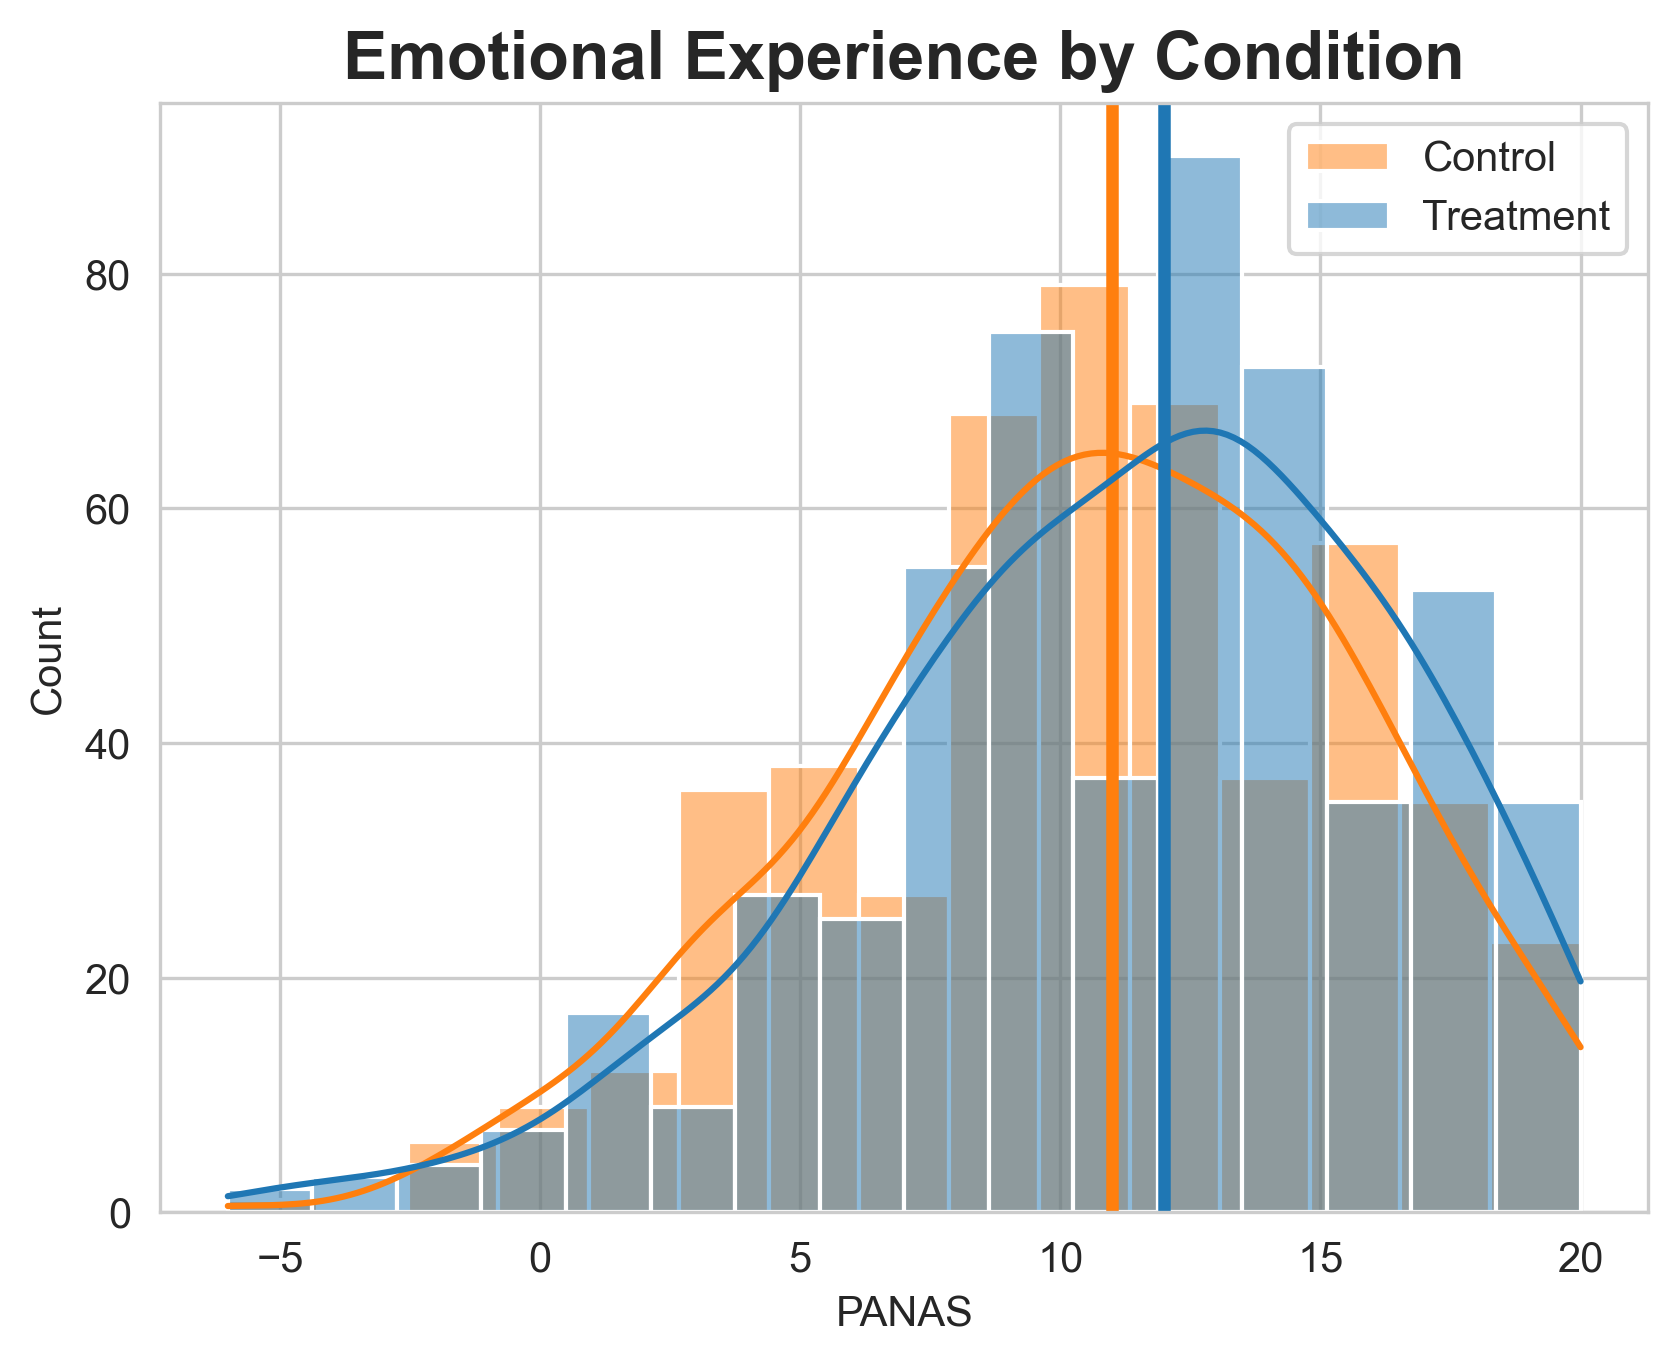

In [42]:
plt.figure(dpi=300)
sb.set_style("whitegrid")
sb.histplot(df[df.condition=="control"].dropna(subset=['panas']).panas, color="tab:orange", label="Control", alpha=0.5, kde=True)
plt.axvline(np.median(df[df.condition=="control"].dropna(subset=['panas']).panas), color="tab:orange", lw=3)
#sb.histplot(df[df.condition=="pure_control"].dropna(subset=['panas']).panas, color="tab:green", label="Pure Control", alpha=0.5)
#plt.axvline(np.mean(df[df.condition=="pure_control"].dropna(subset=['panas']).panas), color="tab:green", lw=3)
sb.histplot(df[df.condition=="treat"].dropna(subset=['panas']).panas, color="tab:blue", label="Treatment", alpha=0.5, kde=True)
plt.axvline(np.median(df[df.condition=="treat"].dropna(subset=['panas']).panas), color="tab:blue", lw=3)
plt.xlabel("PANAS")
plt.legend()
plt.title("Emotional Experience by Condition", fontweight="bold", fontsize=16)
plt.show()

In [43]:
m1 = np.mean(df[df.condition == "treat"].dropna(subset=['panas']).panas)
m2 = np.mean(df[df.condition == "control"].dropna(subset=['panas']).panas)
sd = np.std(df[(df.condition == "control") | (df.condition == "treat")].dropna(subset=['panas']).panas)

print(round((m1 - m2)/sd, 3))

0.137


In [44]:
print(np.mean(df[df.condition == "treat"].dropna(subset=['panas']).panas))
print(np.mean(df[df.condition == "pure_control"].dropna(subset=['panas']).panas))
print(np.mean(df[df.condition == "control"].dropna(subset=['panas']).panas))

11.293040293040294
nan
10.601609657947686


In [45]:
print(np.mean(df[df.condition == "treat"].dropna(subset=['panas']).panas) - np.mean(df[df.condition == "control"].dropna(subset=['panas']).panas))

print(np.median(df[df.condition == "treat"].dropna(subset=['panas']).panas) - np.median(df[df.condition == "control"].dropna(subset=['panas']).panas))

0.6914306350926083
1.0


# Intellectual Humility

In [46]:
print(stats.ttest_ind(df[df.condition == "treat"].dropna(subset=['delta_ih']).delta_ih,
                      df[df.condition == "control"].dropna(subset=['delta_ih']).delta_ih,
                      equal_var=False))

print(stats.mannwhitneyu(df[df.condition == "treat"].dropna(subset=['delta_ih']).delta_ih,
                df[df.condition == "control"].dropna(subset=['delta_ih']).delta_ih))

Ttest_indResult(statistic=1.221014661142677, pvalue=0.22236016588015473)
MannwhitneyuResult(statistic=141321.0, pvalue=0.21152095934994797)


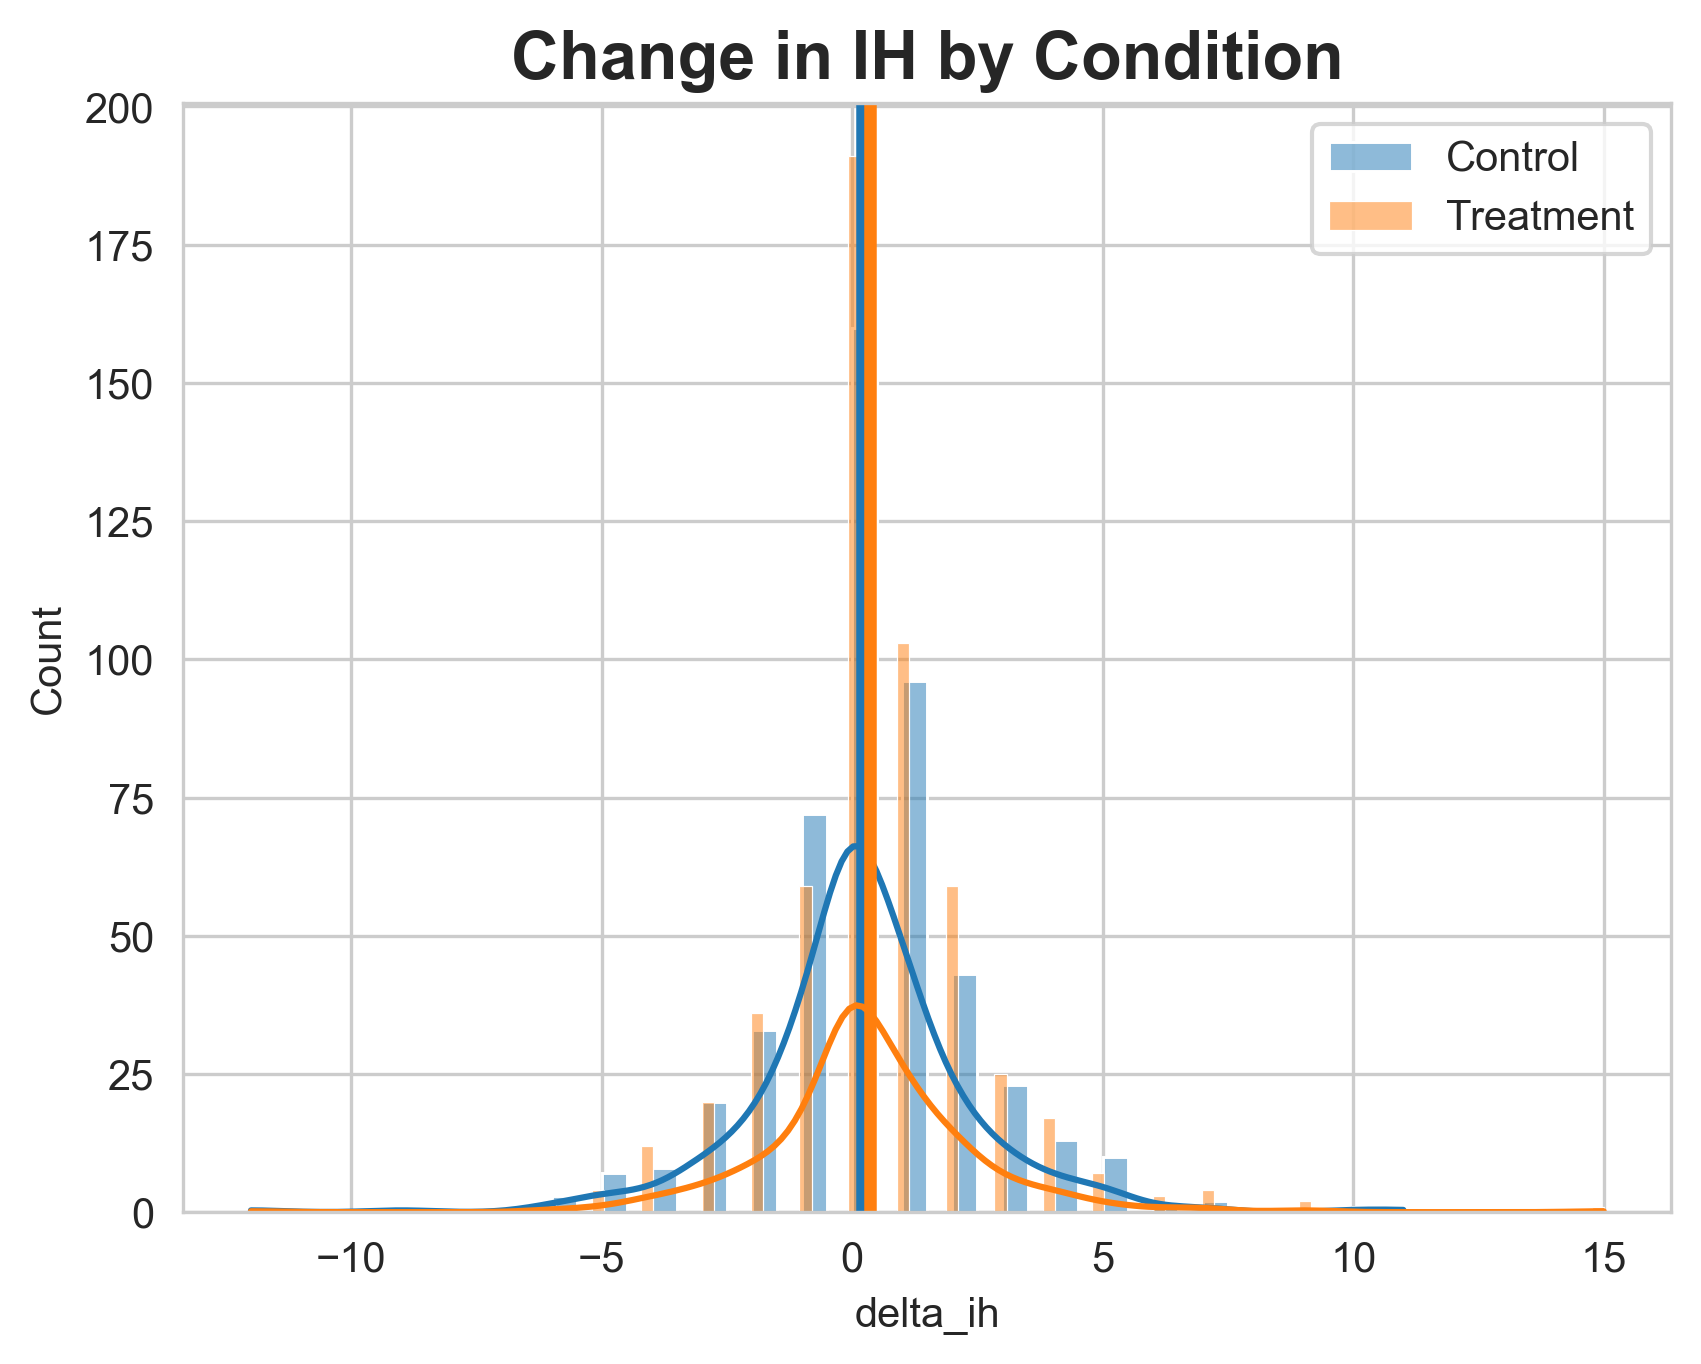

In [47]:
plt.figure(dpi=300)
sb.histplot(df[df.condition=="control"].dropna(subset=['delta_ih']).delta_ih, color="tab:blue", label="Control", alpha=0.5, kde=True)
plt.axvline(np.mean(df[df.condition=="control"].dropna(subset=['delta_ih']).delta_ih), color="tab:blue", lw=3)
#sb.histplot(df[df.condition=="pure_control"].dropna(subset=['panas']).panas, color="tab:green", label="Pure Control", alpha=0.5)
#plt.axvline(np.mean(df[df.condition=="pure_control"].dropna(subset=['panas']).panas), color="tab:green", lw=3)
sb.histplot(df[df.condition=="treat"].dropna(subset=['delta_ih']).delta_ih, color="tab:orange", label="Treatment", alpha=0.5, kde=True)
plt.axvline(np.mean(df[df.condition=="treat"].dropna(subset=['delta_ih']).delta_ih), color="tab:orange", lw=3)
plt.legend()
plt.title("Change in IH by Condition", fontweight="bold", fontsize=16)
plt.show()

# Use this platform?

In [48]:
df['future_use_n'] = df.future_use.apply(lambda x: {'Very unlikely': 1,
                                                   'Somewhat unlikely': 2,
                                                   'Neither unlikely nor likely': 3,
                                                   'Somewhat likely': 4,
                                                   'Very likely': 5,
                                                   nan: None}[x])

pd.crosstab(df.future_use_n, df.condition)

condition,control,treat
future_use_n,,
1,66,74
2,77,50
3,94,110
4,176,216
5,84,96


In [49]:
print(stats.mannwhitneyu(df[df.condition == "control"].dropna(subset=['future_use_n']).future_use_n,
                         df[df.condition == "treat"].dropna(subset=['future_use_n']).future_use_n))

stats.ttest_ind(df[df.condition == "control"].dropna(subset=['future_use_n']).future_use_n,
                   df[df.condition == "treat"].dropna(subset=['future_use_n']).future_use_n,
                equal_var=False)

MannwhitneyuResult(statistic=128915.0, pvalue=0.14879344981603035)


Ttest_indResult(statistic=-1.4327046351117352, pvalue=0.1522462590441715)

In [50]:
print(np.median(df[df.condition == "control"].dropna(subset=['future_use_n']).future_use_n))
print(np.median(df[df.condition == "treat"].dropna(subset=['future_use_n']).future_use_n))

4.0
4.0


In [51]:
print(np.mean(df[df.condition == "control"].dropna(subset=['future_use_n']).future_use_n))
print(np.mean(df[df.condition == "treat"].dropna(subset=['future_use_n']).future_use_n))

3.271629778672032
3.3846153846153846


# Description of platform

In [52]:
d = {"Not at all": 1,
     "Very little": 2,
     "Some": 3,
     "Quite a bit": 4,
     "A great deal": 5,
     nan: None}

d_r = {"Not at all": 5,
     "Very little": 4,
     "Some": 3,
     "Quite a bit": 2,
     "A great deal": 1,
     nan: None}

df['engaging'] = df.desc_platform_engaging.apply(lambda x: d_r[x])
df['toxic'] = df.desc_platform_toxic.apply(lambda x: d[x])
df['exhausting'] = df.desc_platform_exhausting.apply(lambda x: d[x])

In [53]:
stats.ttest_ind(df[df.condition == "control"].dropna(subset=['engaging']).engaging,
                df[df.condition == "treat"].dropna(subset=['engaging']).engaging,
                equal_var=False)

Ttest_indResult(statistic=1.141907563101783, pvalue=0.25375699616836694)

In [54]:
print(np.mean(df[df.condition == "treat"].dropna(subset=['engaging']).engaging))
print(np.mean(df[df.condition == "pure_control"].dropna(subset=['engaging']).engaging))
print(np.mean(df[df.condition == "control"].dropna(subset=['engaging']).engaging))

2.0366300366300365
nan
2.10261569416499


In [55]:
stats.ttest_ind(df[df.condition == "control"].dropna(subset=['toxic']).toxic,
                df[df.condition == "treat"].dropna(subset=['toxic']).toxic,
                equal_var=False)

Ttest_indResult(statistic=0.7074150499232528, pvalue=0.4794689210143722)

In [56]:
print(np.mean(df[df.condition == "treat"].dropna(subset=['toxic']).toxic))
print(np.mean(df[df.condition == "pure_control"].dropna(subset=['toxic']).toxic))
print(np.mean(df[df.condition == "control"].dropna(subset=['toxic']).toxic))

1.8131868131868132
nan
1.8551307847082494


In [57]:
stats.ttest_ind(df[df.condition == "control"].dropna(subset=['exhausting']).exhausting,
                df[df.condition == "treat"].dropna(subset=['exhausting']).exhausting,
                equal_var=False)

Ttest_indResult(statistic=0.6389346500239972, pvalue=0.5230082511088769)

In [58]:
print(np.mean(df[df.condition == "treat"].dropna(subset=['exhausting']).exhausting))
print(np.mean(df[df.condition == "pure_control"].dropna(subset=['exhausting']).exhausting))
print(np.mean(df[df.condition == "control"].dropna(subset=['exhausting']).exhausting))

1.901098901098901
nan
1.9456740442655935


In [59]:
df['platform'] = np.mean(df[['engaging', 'toxic', 'exhausting']], axis=1)
stats.ttest_ind(df[df.condition == "control"].dropna(subset=['platform']).platform,
                df[df.condition == "treat"].dropna(subset=['platform']).platform)

Ttest_indResult(statistic=1.0238171444371067, pvalue=0.3061595016928737)

# Decription of Users

In [60]:
d = {"Not at all": 1,
     "Very little": 2,
     "Some": 3,
     "Quite a bit": 4,
     "A great deal": 5,
     nan: None}

d_r = {"Not at all": 5,
     "Very little": 4,
     "Some": 3,
     "Quite a bit": 2,
     "A great deal": 1,
     nan: None}

df['polite'] = df.desc_users_polite.apply(lambda x: d[x])
df['aggressive'] = df.desc_users_aggressive.apply(lambda x: d_r[x])
df['tolerant'] = df.desc_users_tolerant.apply(lambda x: d[x])

In [61]:
print(np.mean(df[df.condition == "treat"].dropna(subset=['polite']).polite))
print(np.mean(df[df.condition == "pure_control"].dropna(subset=['polite']).polite))
print(np.mean(df[df.condition == "control"].dropna(subset=['polite']).polite))

stats.ttest_ind(df[df.condition == "control"].dropna(subset=['polite']).polite,
                df[df.condition == "treat"].dropna(subset=['polite']).polite)

3.9194139194139193
nan
3.847082494969819


Ttest_indResult(statistic=-1.4239613534411495, pvalue=0.154757324861688)

In [62]:
print(np.mean(df[df.condition == "treat"].dropna(subset=['aggressive']).aggressive))
print(np.mean(df[df.condition == "pure_control"].dropna(subset=['aggressive']).aggressive))
print(np.mean(df[df.condition == "control"].dropna(subset=['aggressive']).aggressive))

stats.ttest_ind(df[df.condition == "control"].dropna(subset=['aggressive']).aggressive,
                df[df.condition == "treat"].dropna(subset=['aggressive']).aggressive)

4.0256410256410255
nan
3.9839034205231387


Ttest_indResult(statistic=-0.7155412824161639, pvalue=0.4744350973109025)

In [63]:
print(np.mean(df[df.condition == "treat"].dropna(subset=['tolerant']).tolerant))
print(np.mean(df[df.condition == "pure_control"].dropna(subset=['tolerant']).tolerant))
print(np.mean(df[df.condition == "control"].dropna(subset=['tolerant']).tolerant))

stats.ttest_ind(df[df.condition == "control"].dropna(subset=['tolerant']).tolerant,
                df[df.condition == "treat"].dropna(subset=['tolerant']).tolerant)

3.597069597069597
nan
3.5030181086519114


Ttest_indResult(statistic=-1.6675173310388975, pvalue=0.09571234746616551)

In [64]:
df['users'] = np.mean(df[['polite', 'aggressive', 'tolerant']], axis=1)
print(stats.ttest_ind(df[df.condition == "control"].dropna(subset=['users']).users,
                df[df.condition == "treat"].dropna(subset=['users']).users))
print(stats.mannwhitneyu(df[df.condition == "control"].dropna(subset=['users']).users,
                df[df.condition == "treat"].dropna(subset=['users']).users))

Ttest_indResult(statistic=-1.5597504784955825, pvalue=0.11912279781767453)
MannwhitneyuResult(statistic=126116.0, pvalue=0.04678404935603496)


In [65]:
df['users_b'] = np.mean(df[['polite', 'tolerant']], axis=1)
print(stats.ttest_ind(df[df.condition == "control"].dropna(subset=['users_b']).users_b,
                df[df.condition == "treat"].dropna(subset=['users_b']).users_b))
print(stats.mannwhitneyu(df[df.condition == "control"].dropna(subset=['users_b']).users_b,
                df[df.condition == "treat"].dropna(subset=['users_b']).users_b))

Ttest_indResult(statistic=-1.722370289568061, pvalue=0.08529948134875316)
MannwhitneyuResult(statistic=124191.5, pvalue=0.015756829196414336)


# Comfort Sharing Ideas

In [66]:
d = {"Not at all comfortable": 1,
     "Slightly comfortable": 2,
     "Moderately comfortable": 3,
     "Very comfortable": 4,
     "Extremely comfortable": 5,
     nan: None}

df['comfort'] = df.comfort_sharing.apply(lambda x: d[x])

stats.ttest_ind(df[df.condition == "control"].dropna(subset=['comfort']).comfort,
                df[df.condition == "treat"].dropna(subset=['comfort']).comfort)

Ttest_indResult(statistic=-0.45202422572453566, pvalue=0.6513456984424238)

In [67]:
print(np.mean(df[df.condition == "treat"].dropna(subset=['comfort']).comfort))
print(np.mean(df[df.condition == "pure_control"].dropna(subset=['comfort']).comfort))
print(np.mean(df[df.condition == "control"].dropna(subset=['comfort']).comfort))

3.587912087912088
nan
3.5553319919517103


In [68]:
stats.ttest_ind(df[df.condition == "control"].dropna(subset=['comfort']).comfort,
                df[df.condition == "pure_control"].dropna(subset=['comfort']).comfort)

Ttest_indResult(statistic=nan, pvalue=nan)

# Estimation of Bots

In [69]:
print(df.groupby('bots').size())
print()
print(df.groupby('bots').size()/len(df))

bots
No, I did not encounter any bots      468
Yes, I encountered many bots          111
Yes, I encountered one or two bots    323
Yes, I encountered several bots       141
dtype: int64

bots
No, I did not encounter any bots      0.448706
Yes, I encountered many bots          0.106424
Yes, I encountered one or two bots    0.309684
Yes, I encountered several bots       0.135187
dtype: float64


# Engagement

In [70]:
ih_posts = {"A lot of reporting I've seen suggests that the illegal crossing are very dangerous. If that's true, we should do everything we can to deter this. I've heard that many die every year crossing in unsafe areas, and that even when they make it across they die of heat and thrust or crammed in the back of trucks. It seems like, then, a border wall is for their safety as well as ours.",
            "I get the reason some people want gun control.  I want them to understand that where I live, we need guns. We are over run with coyotes. They kill our pets. We try and kill them. You have to use a weapon with range. What youd call an assault weapon is perfect for that, and they are popular here for coyotes. I just scare them with my gun, because I don't ever hit them",
            "I might be wrong but it seems like the places that have the most mayhem are those with the most restrictive laws. I think about the pressure cooker bombs a few years back at the marathon.",
            "I totally understand, it's not the guns fault. We shouldn't do away with guns because of recent incidents, but it seems to me that we need to look at those who use the guns. I think regulating who can get access to them could help solve this issue. I agree that people have the need to feel safe and they should secure their environment the way they feel comfortable",
            "I try not to be naive that utopia exists or can exist. I know some people think differently, but I do believe in laws and rules and that people are basically good and follow them most of the time. I'd love to see data on this, but I feel like it's only the fringe that does not follow them and causes mayhem for the rest of us.",
            "I understand it is a complex issue and I actually have no problem with asylum seekers. I personally believe that we should be letting in people who will come in to this country the legal way and assimilate into our country. This is just my perspective and open to hear the views of others.",
            "I understand why people are worried about the Southern Border situation, but I don't think that has much to do with terrorism. I might be wrong, but I think that more terrorists are coming over the Canadian border.",
            "I understand why some people want  gun control.  It would help insure guns aren't  given to unstable people. But I also believe that as an American I have every right to defend my property, family, and myself with a gun or guns. I worry only criminals would have weapons.",
            "I'm honestly curious about what the other side thinks. I agree that the gangs and the drugs that come over here from Mexico are a problem. At the same time,  I think we already have gangs and drugs over here before Mexico brought them over.",
            "I'm no psychologist, but I don't think that criminals care what the laws are and what they can or can't do. If that is true, they will obtain a gun by whatever means they can, carry it illegally, use it in a crime and possibly use it to rob you.",
            "I'm not an expert on gun policy, but I did write research papers on the topic in college. While doing research, I was persuaded there was a lot misinformation put out by the NRA, which wa led by someone personally enriching himself from the sales of ammunition.",
            "I'm open to hearing other views, but it sure seems like gun control doesn't work. I've heard that the states with the strictest gun control has the highest crime rates and murder rates. I would think that's because only criminal have the guns.",
            "I'm sure others disagree, but I don't think it's our responsibility as a nation to take care of people from other countries who can't get any help from their own government. I think we have enough AMERICANS who need assistance, and we should help them first. I guess I just don't understand why we should be paying for anyone who manages to sneak in to our country.",
            "It's been a long time since I took US history, but I believe this land as far as Texas, New Mexico, Arizona, California, we're all Mexico territory before The United States took it from them. So I guess it would make sense that They're going to come back, maybe because they never left.",
            "Living close to the border has made me think that we need a wall. Our border patrol, who are the real experts, has asked for a wall. I haven't dug into the numbers, but I've heard the wall has already made in a difference in the areas it is in place. I feel we shouldn't ask our border patrol to risk their lives and not give them the tools they ask for.",
            "Others might disagree, but I don't understand the argument that  Mexicans are taking jobs.  If you are unemployed, couldn't find a job anywhere, and a lettuce field in your city that was hiring, would you apply? My sense is that most Americans would say no.",
            "Others might disagree, but I think we need reasonable and uniform NATIONAL gun legislation. I think one reason for the failure of gun control laws in the US is the pathwork of state-to-state differences. I might be wrong, but I think Congress even forbid the government trackingof gun violence deaths.",
            "I'm not an expert, but it seems like more immigration can only hurt me. I'm interesting in hearing the argument for the other side.",
            "I understand the argument that the system needs reform. However, my own view is that many who have immigrated are the epitome of an outstanding citizens that contributes to society and our economy.",
            "I'm open to other ideas, but I wonder if we should require every gun sale to be registered and require gun manufacturers to include trigger locks at no additional charge to the consumer.  It probably won't solve all our problems, but I think that we can take measures to reduce gun deaths without trampling on the 2nd Amendment."}



In [71]:
posts = pd.read_csv("participant-export.csv")
posts = pd.concat([posts, pd.read_csv("export-deleted.csv")])
posts = posts[[i in df.participant_code.values for i in posts.participantCode]]

In [72]:
posts = pd.read_csv("participant-export.csv")
posts = pd.concat([posts, pd.read_csv("export-deleted.csv")]).dropna(subset="treatmentArm")
posts = posts[[i in df.participant_code.values for i in posts.participantCode]]
posts.to_csv("participant_content.csv", index=False)

#condition[nan] = "imm_control3"
posts['condition'] = posts.treatmentArm.apply(lambda x: condition[x])

posts['ih'] = posts.postOrCommentText.apply(lambda x: int(x in ih_posts))

likes = posts[posts.participantLiked == 1]
likes[['condition','postOrCommentText','participantLiked','participantDisliked']]

,condition,postOrCommentText,participantLiked,participantDisliked
16425,treat,"Immigration is the reason several countries, s...",1.0,0.0
16487,treat,"America is a nation of immigrants, and it's ti...",1.0,0.0
16514,control,"I believe in in being cautious, but at what co...",1.0,0.0
16522,control,No more gun control. Just enforce the laws tha...,1.0,0.0
16654,control,Watching Seinfeld and it is still so good!,1.0,0.0
...,...,...,...,...
6324,control,🚨🚨🚨BONUS PAYMENT ALERT🚨🚨🚨\r\n\r\nThanks for he...,1.0,0.0
6338,control,I think its crazy to insist teachers learn spa...,1.0,0.0
6371,control,"In my view, first-generation immigrants are th...",1.0,0.0
6405,control,"As a faithful, family-oriented and cage-rattli...",1.0,0.0


In [73]:
sum(likes.participantDisliked)

0.0

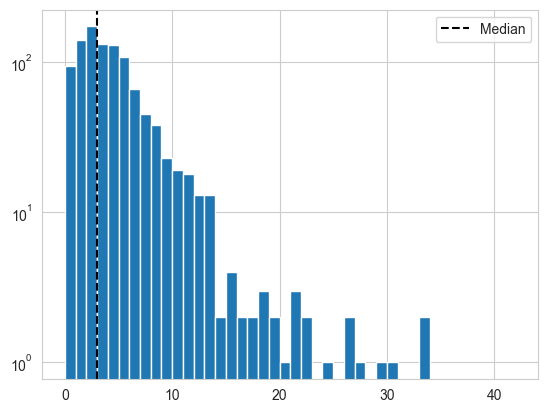

In [74]:
x = list(likes.groupby('participantCode').size().values)
y = [0] * (len(df) - len(x))
x += y
plt.hist(x, bins=[i for i in range(43)])
plt.axvline(np.median(x), label="Median", ls="--", color="black")
plt.yscale('log')
plt.legend()
plt.show()

In [75]:
for x in range(44):
  print(x, sum([i == x for i in likes.groupby('participantCode').size()]))

0 0
1 141
2 173
3 132
4 130
5 108
6 66
7 45
8 38
9 23
10 19
11 18
12 13
13 13
14 2
15 4
16 2
17 2
18 3
19 2
20 1
21 3
22 2
23 0
24 1
25 0
26 2
27 1
28 0
29 1
30 1
31 0
32 0
33 2
34 0
35 0
36 0
37 0
38 0
39 0
40 0
41 0
42 0
43 0


In [76]:
(201 + 248)/len(df)

0.4304889741131352

In [77]:
len(likes.groupby('participantCode').size())/len(df)

0.9089165867689357

In [78]:
total_likes = likes.groupby('participantCode').size().to_dict()
df['total_likes'] = df.participant_code.apply(lambda x: total_likes[x] if x in total_likes else 0)

ih_likes = likes[likes.ih == 1].groupby('participantCode').size().to_dict()
df['ih_likes'] = df.participant_code.apply(lambda x: ih_likes[x] if x in ih_likes else 0)

df['p_likes_ih'] = df.ih_likes / df.total_likes.apply(float)

(array([546., 100., 148.,  55.,  16.,  51.,   8.,   0.,   2.,  22.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

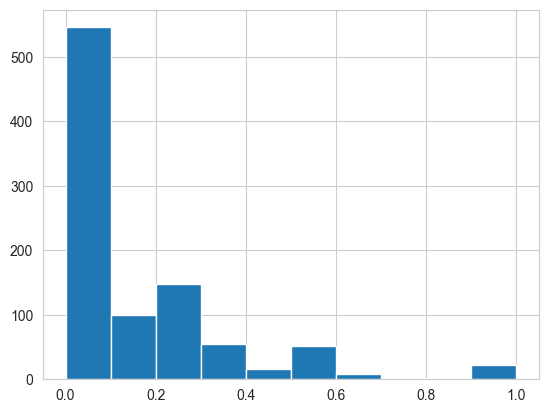

In [79]:
plt.hist(df.p_likes_ih)

In [80]:
print(np.mean(df[df.condition == "treat"].total_likes))
print(np.mean(df[df.condition == "pure_control"].total_likes))
print(np.mean(df[df.condition == "control"].total_likes))
print()
print(np.median(df[df.condition == "treat"].total_likes))
print(np.median(df[df.condition == "pure_control"].total_likes))
print(np.median(df[df.condition == "control"].total_likes))
print()
print(stats.ttest_ind(df[df.condition == "control"].total_likes,
                df[df.condition == "treat"].total_likes))

print(stats.mannwhitneyu(df[df.condition == "control"].total_likes,
                df[df.condition == "treat"].total_likes))

4.485347985347985
nan
4.084507042253521

3.5
nan
3.0

Ttest_indResult(statistic=-1.5596046259188516, pvalue=0.11915728265389616)
MannwhitneyuResult(statistic=129171.0, pvalue=0.177434301502728)


C:\Users\Austin\anaconda3\lib\site-packages\numpy\core\fromnumeric.py:3440: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\Austin\anaconda3\lib\site-packages\numpy\core\_methods.py:189: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


In [81]:
print(np.mean(df[df.condition == "treat"].ih_likes))
print(np.mean(df[df.condition == "pure_control"].ih_likes))
print(np.mean(df[df.condition == "control"].ih_likes))
print()
print(np.median(df[df.condition == "treat"].ih_likes))
print(np.median(df[df.condition == "pure_control"].ih_likes))
print(np.median(df[df.condition == "control"].ih_likes))
print()
print(stats.ttest_ind(df[df.condition == "control"].ih_likes,
                df[df.condition == "treat"].ih_likes))

print(stats.mannwhitneyu(df[df.condition == "control"].ih_likes,
                df[df.condition == "treat"].ih_likes))

0.7124542124542125
nan
0.6177062374245473

0.0
nan
0.0

Ttest_indResult(statistic=-1.343409711873838, pvalue=0.1794321154658753)
MannwhitneyuResult(statistic=135262.5, pvalue=0.9216610317260964)


In [82]:
print(np.mean(df[df.condition == "treat"].p_likes_ih))
print(np.mean(df[df.condition == "pure_control"].p_likes_ih))
print(np.mean(df[df.condition == "control"].p_likes_ih))
print()
print(stats.ttest_ind(df[df.condition == "control"].dropna(subset=['p_likes_ih']).p_likes_ih,
                df[df.condition == "treat"].dropna(subset=['p_likes_ih']).p_likes_ih))

print(stats.mannwhitneyu(df[df.condition == "control"].dropna(subset=['p_likes_ih']).p_likes_ih,
                df[df.condition == "treat"].dropna(subset=['p_likes_ih']).p_likes_ih))

0.1297669646760127
nan
0.14682257019996586

Ttest_indResult(statistic=1.253762357721605, pvalue=0.21023813739466105)
MannwhitneyuResult(statistic=113929.0, pvalue=0.6034094126149563)


# Dislikes

In [83]:
dislikes = posts[posts.participantDisliked == 1]
len(dislikes.groupby('participantCode').size())/len(df)


0.5043144774688398

In [84]:
for x in range(1,20):
  print(x, sum([i == x for i in dislikes.groupby('participantCode').size()]))

1 229
2 114
3 66
4 38
5 40
6 11
7 8
8 6
9 2
10 1
11 5
12 1
13 3
14 1
15 1
16 0
17 0
18 0
19 0


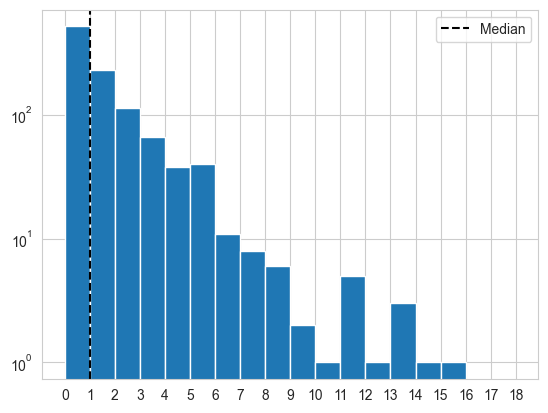

In [85]:
x = list(dislikes.groupby('participantCode').size().values)
y = [0] * (len(df) - len(x))
x += y
plt.hist(x, bins=[i for i in range(19)])
plt.axvline(np.median(x), label="Median", ls="--", color="black")
plt.legend()
plt.yscale('log')
plt.xticks([i for i in range(19)])
plt.show()

In [86]:
len(dislikes)

1340

In [87]:
492/len(df)

0.47171620325982744

In [88]:
total_dislikes = dislikes.groupby('participantCode').size().to_dict()
df['total_dislikes'] = df.participant_code.apply(lambda x: total_dislikes[x] if x in total_dislikes else 0)

ih_dislikes = dislikes[dislikes.ih == 1].groupby('participantCode').size().to_dict()
df['ih_dislikes'] = df.participant_code.apply(lambda x: ih_dislikes[x] if x in ih_dislikes else 0)

df['p_dislikes_ih'] = df.ih_dislikes / df.total_dislikes.apply(float)

In [89]:
print(np.mean(df[df.condition == "treat"].total_dislikes))
print(np.mean(df[df.condition == "pure_control"].total_dislikes))
print(np.mean(df[df.condition == "control"].total_dislikes))
print()
print(np.median(df[df.condition == "treat"].total_dislikes))
print(np.median(df[df.condition == "pure_control"].total_dislikes))
print(np.median(df[df.condition == "control"].total_dislikes))
print()
print(stats.ttest_ind(df[df.condition == "control"].total_dislikes,
                df[df.condition == "treat"].total_dislikes))

print(stats.mannwhitneyu(df[df.condition == "control"].total_dislikes,
                df[df.condition == "treat"].total_dislikes))

1.358974358974359
nan
1.2032193158953723

0.0
nan
1.0

Ttest_indResult(statistic=-1.2404521420129935, pvalue=0.21508770621541254)
MannwhitneyuResult(statistic=133737.0, pvalue=0.6673156724169836)


C:\Users\Austin\anaconda3\lib\site-packages\numpy\core\fromnumeric.py:3440: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\Austin\anaconda3\lib\site-packages\numpy\core\_methods.py:189: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


In [90]:
print(np.mean(df[df.condition == "treat"].ih_dislikes))
print(np.mean(df[df.condition == "pure_control"].ih_dislikes))
print(np.mean(df[df.condition == "control"].ih_dislikes))
print()
print(np.median(df[df.condition == "treat"].ih_dislikes))
print(np.median(df[df.condition == "pure_control"].ih_dislikes))
print(np.median(df[df.condition == "control"].ih_dislikes))
print()
print(stats.ttest_ind(df[df.condition == "control"].ih_dislikes,
                df[df.condition == "treat"].ih_dislikes))

print(stats.mannwhitneyu(df[df.condition == "control"].ih_dislikes,
                df[df.condition == "treat"].ih_dislikes))

0.17216117216117216
nan
0.15694164989939638

0.0
nan
0.0

Ttest_indResult(statistic=-0.450168937243422, pvalue=0.652682362140125)
MannwhitneyuResult(statistic=135710.5, pvalue=0.9913651592230357)


In [91]:
print(np.mean(df[df.condition == "treat"].p_dislikes_ih))
print(np.mean(df[df.condition == "pure_control"].p_dislikes_ih))
print(np.mean(df[df.condition == "control"].p_dislikes_ih))
print()
print(stats.ttest_ind(df[df.condition == "control"].dropna(subset=['p_dislikes_ih']).p_dislikes_ih,
                df[df.condition == "treat"].dropna(subset=['p_dislikes_ih']).p_dislikes_ih))

print(stats.mannwhitneyu(df[df.condition == "control"].dropna(subset=['p_dislikes_ih']).p_dislikes_ih,
                df[df.condition == "treat"].dropna(subset=['p_dislikes_ih']).p_dislikes_ih))

0.0936954906512102
nan
0.1167575670516847

Ttest_indResult(statistic=1.10549091920605, pvalue=0.2694542361220595)
MannwhitneyuResult(statistic=34727.5, pvalue=0.8912246718780408)


# Content

In [92]:
content = posts[posts.userContent == 1]
content

,sessionId,treatmentArm,participantCode,profilePicture,firstName,lastName,bio,postOrCommentId,userContent,staticContent,...,postOrCommentDate,postLikes,postDislikes,participantLiked,participantDisliked,parentPost,previousCommentOrPost,dwellTimeInSeconds,condition,ih
16426,657896b96d158d001f181516,imm_treat,8gch37,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,Yelena22,NaN,NC girl,657898246d158d001f18395d,1,0,...,2023-12-12T17:28:03.930Z,NaN,NaN,NaN,NaN,654e2ecbf18dbd001f7aaf46,654e2ecbf18dbd001f7aaf46,0,treat,0
16477,657896b96d158d001f181516,imm_treat,8gch37,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,Yelena22,NaN,NC girl,657899456d158d001f185f72,1,0,...,2023-12-12T17:32:53.700Z,NaN,NaN,NaN,NaN,654e2ecdf18dbd001f7ab3ec,654e2ecdf18dbd001f7ab3ec,0,treat,0
16485,657896b96d158d001f181516,imm_treat,8gch37,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,Yelena22,NaN,NC girl,657897ad6d158d001f1824be,1,0,...,2023-12-12T17:26:05.474Z,5.0,1.0,0.0,0.0,NaN,NaN,66,treat,0
16566,6578987d6d158d001f1847ac,gc_control3,nyuhem,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,SFon85,NaN,"Hello, I'm a 38 year old married man. I love ...",65789b036d158d001f188a87,1,0,...,2023-12-12T17:40:19.333Z,6.0,4.0,0.0,0.0,NaN,NaN,105,control,0
16567,6578987d6d158d001f1847ac,gc_control3,nyuhem,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,SFon85,NaN,"Hello, I'm a 38 year old married man. I love ...",65789bb66d158d001f18b972,1,0,...,2023-12-12T17:43:18.590Z,NaN,NaN,NaN,NaN,65789b036d158d001f188a87,65789b036d158d001f188a87,0,control,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6317,657b61122855e7001f93f0ef,imm_control3,pqdpcp,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,Cbros,NaN,Baba,657b62628b12dc001f05d62b,1,0,...,2023-12-14T20:15:32.087Z,3.0,3.0,0.0,0.0,NaN,NaN,0,control,0
6351,657b64a78b12dc001f06215b,imm_control3,h63zav,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,Shan,NaN,"Jersey girl, born and raised!!! I love animals...",657b65a88b12dc001f069f70,1,0,...,2023-12-14T20:29:28.539Z,NaN,NaN,NaN,NaN,655d0ae8f1c1b5001f5cb577,655d0ae8f1c1b5001f5cb577,0,control,0
6353,657b64a78b12dc001f06215b,imm_control3,h63zav,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,Shan,NaN,"Jersey girl, born and raised!!! I love animals...",657b66162855e7001f9554e3,1,0,...,2023-12-14T20:31:18.583Z,NaN,NaN,NaN,NaN,655d0ae8f1c1b5001f5cb577,657b65bd8b12dc001f06b363,0,control,0
6407,657b64a78b12dc001f06215b,imm_control3,h63zav,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,Shan,NaN,"Jersey girl, born and raised!!! I love animals...",657b66cb8b12dc001f07eca7,1,0,...,2023-12-14T20:34:19.040Z,0.0,3.0,0.0,0.0,NaN,NaN,0,control,0


In [93]:
n_posts = content.groupby('participantCode').size().to_dict()
df['n_posts'] = df.participant_code.apply(lambda x: n_posts[x] if x in n_posts else 0)

In [94]:
for i in [0,1,2,3,4,5,6,7,8,9,10]:
  print(i, len(df[df.n_posts == i]), round(len(df[df.n_posts == i])/len(df),3))

0 62 0.059
1 145 0.139
2 341 0.327
3 208 0.199
4 128 0.123
5 78 0.075
6 33 0.032
7 20 0.019
8 7 0.007
9 6 0.006
10 6 0.006


In [95]:
content['length'] = content.postOrCommentText.apply(lambda x: len(tknzr.tokenize(x)))
print(sum(content.length))
print(np.mean(content.length))

63744
21.43375924680565


<ipython-input-95-c43d7e4926e5>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  content['length'] = content.postOrCommentText.apply(lambda x: len(tknzr.tokenize(x)))


In [96]:
total_length = content[['participantCode', 'length']].groupby('participantCode').sum().to_dict()['length']
df['total_length'] = df.participant_code.apply(lambda x: total_length[x] if x in total_length else 0)

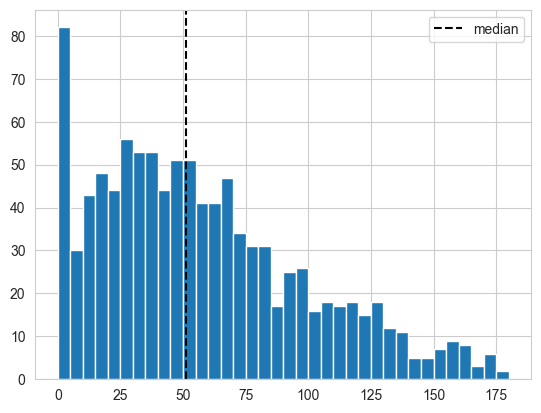

In [97]:
plt.hist(df.total_length, bins=[i for i in range(0,185,5)])
plt.axvline(np.median(df.total_length), color="black", ls="--", label="median")
plt.legend()
#plt.yscale('log')
plt.show()

In [98]:
print(len(df[df.total_length < 10]), round(len(df[df.total_length < 10])/len(df),3))

112 0.107


In [99]:
max(df.total_length)

367

In [100]:
print(np.mean(df[df.condition == "treat"].total_length))
print(np.mean(df[df.condition == "pure_control"].total_length))
print(np.mean(df[df.condition == "control"].total_length))
print()
print(np.median(df[df.condition == "treat"].total_length))
print(np.median(df[df.condition == "pure_control"].total_length))
print(np.median(df[df.condition == "control"].total_length))
print()
print(stats.ttest_ind(df[df.condition == "control"].total_length,
                df[df.condition == "treat"].total_length))

print(stats.mannwhitneyu(df[df.condition == "control"].total_length,
                df[df.condition == "treat"].total_length))

63.95054945054945
nan
58.00201207243461

53.5
nan
49.0

Ttest_indResult(statistic=-1.9731543612303732, pvalue=0.04874218245616906)
MannwhitneyuResult(statistic=126132.0, pvalue=0.04936120941666324)


C:\Users\Austin\anaconda3\lib\site-packages\numpy\core\fromnumeric.py:3440: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\Austin\anaconda3\lib\site-packages\numpy\core\_methods.py:189: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


In [101]:
print(np.mean(df[(df.condition == "treat") & (df.total_length > 0)].total_length))
print(np.mean(df[(df.condition == "pure_control") & (df.total_length > 0)].total_length))
print(np.mean(df[(df.condition == "control") & (df.total_length > 0)].total_length))
print()
print(np.median(df[(df.condition == "treat") & (df.total_length > 0)].total_length))
print(np.median(df[(df.condition == "pure_control") & (df.total_length > 0)].total_length))
print(np.median(df[(df.condition == "control") & (df.total_length > 0)].total_length))
print()
print(stats.ttest_ind(df[(df.condition == "control") & (df.total_length > 0)].total_length,
                df[(df.condition == "treat") & (df.total_length > 0)].total_length))

print(stats.mannwhitneyu(df[(df.condition == "control") & (df.total_length > 0)].total_length,
                df[(df.condition == "treat") & (df.total_length > 0)].total_length))

68.197265625
nan
61.59615384615385

57.0
nan
51.5

Ttest_indResult(statistic=-2.1715304795352615, pvalue=0.030130881938042555)
MannwhitneyuResult(statistic=109727.0, pvalue=0.02274388458921626)


In [102]:
vader = SentimentIntensityAnalyzer()
content['sent_pos'] = content.postOrCommentText.apply(lambda x: vader.polarity_scores(x)['pos'])
content['sent_neg'] = content.postOrCommentText.apply(lambda x: vader.polarity_scores(x)['neg'])
content['sent'] = content.postOrCommentText.apply(lambda x: vader.polarity_scores(x)['compound'])

sent = content[['participantCode', 'sent', 'sent_pos', 'sent_neg']].groupby('participantCode').mean().to_dict()
df['sent_pos'] = df.participant_code.apply(lambda x: sent['sent_pos'][x] if x in sent['sent_pos'] else None)
df['sent_neg'] = df.participant_code.apply(lambda x: sent['sent_neg'][x] if x in sent['sent_neg'] else None)
df['sent'] = df.participant_code.apply(lambda x: sent['sent'][x] if x in sent['sent'] else None)

<ipython-input-102-f4ab75636d6d>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  content['sent_pos'] = content.postOrCommentText.apply(lambda x: vader.polarity_scores(x)['pos'])
<ipython-input-102-f4ab75636d6d>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  content['sent_neg'] = content.postOrCommentText.apply(lambda x: vader.polarity_scores(x)['neg'])
<ipython-input-102-f4ab75636d6d>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer

In [103]:
print(np.mean(df[df.condition == "treat"].dropna(subset=['sent_pos']).sent_pos))
print(np.mean(df[df.condition == "pure_control"].dropna(subset=['sent_pos']).sent_pos))
print(np.mean(df[df.condition == "control"].dropna(subset=['sent_pos']).sent_pos))
print()
print(np.median(df[df.condition == "treat"].dropna(subset=['sent_pos']).sent_pos))
print(np.median(df[df.condition == "pure_control"].dropna(subset=['sent_pos']).sent_pos))
print(np.median(df[df.condition == "control"].dropna(subset=['sent_pos']).sent_pos))
print()
print(stats.ttest_ind(df[df.condition == "control"].dropna(subset=['sent_pos']).sent_pos,
                df[df.condition == "treat"].dropna(subset=['sent_pos']).sent_pos))

print(stats.mannwhitneyu(df[df.condition == "control"].dropna(subset=['sent_pos']).sent_pos,
                df[df.condition == "treat"].dropna(subset=['sent_pos']).sent_pos))

0.20132037733221944
nan
0.20436495756439665

0.16
nan
0.16375

Ttest_indResult(statistic=0.27653711525605335, pvalue=0.7821939266870979)
MannwhitneyuResult(statistic=121031.0, pvalue=0.823430205216128)


C:\Users\Austin\anaconda3\lib\site-packages\numpy\core\fromnumeric.py:3440: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\Austin\anaconda3\lib\site-packages\numpy\core\_methods.py:189: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


In [104]:
print(np.mean(df[df.condition == "treat"].dropna(subset=['sent_neg']).sent_neg))
print(np.mean(df[df.condition == "pure_control"].dropna(subset=['sent_neg']).sent_neg))
print(np.mean(df[df.condition == "control"].dropna(subset=['sent_neg']).sent_neg))
print()
print(np.median(df[df.condition == "treat"].dropna(subset=['sent_neg']).sent_neg))
print(np.median(df[df.condition == "pure_control"].dropna(subset=['sent_neg']).sent_neg))
print(np.median(df[df.condition == "control"].dropna(subset=['sent_neg']).sent_neg))
print()
print(stats.ttest_ind(df[df.condition == "control"].dropna(subset=['sent_neg']).sent_neg,
                df[df.condition == "treat"].dropna(subset=['sent_neg']).sent_neg))

print(stats.mannwhitneyu(df[df.condition == "control"].dropna(subset=['sent_neg']).sent_neg,
                df[df.condition == "treat"].dropna(subset=['sent_neg']).sent_neg))

0.10402344842184023
nan
0.09936306191730872

0.08566666666666667
nan
0.082075

Ttest_indResult(statistic=-0.7870307096254381, pvalue=0.43145436992366604)
MannwhitneyuResult(statistic=117027.5, pvalue=0.49479064078984525)


C:\Users\Austin\anaconda3\lib\site-packages\numpy\core\fromnumeric.py:3440: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\Austin\anaconda3\lib\site-packages\numpy\core\_methods.py:189: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


In [105]:
print(np.mean(df[df.condition == "treat"].dropna(subset=['sent']).sent))
print(np.mean(df[df.condition == "pure_control"].dropna(subset=['sent']).sent))
print(np.mean(df[df.condition == "control"].dropna(subset=['sent']).sent))
print()
print(np.median(df[df.condition == "treat"].dropna(subset=['sent']).sent))
print(np.median(df[df.condition == "pure_control"].dropna(subset=['sent']).sent))
print(np.median(df[df.condition == "control"].dropna(subset=['sent']).sent))
print()
print(stats.ttest_ind(df[df.condition == "control"].dropna(subset=['sent']).sent,
                df[df.condition == "treat"].dropna(subset=['sent']).sent))

print(stats.mannwhitneyu(df[df.condition == "control"].dropna(subset=['sent']).sent,
                df[df.condition == "treat"].dropna(subset=['sent']).sent))

0.06278153273897426
nan
0.03440092108597718

0.07733333333333332
nan
0.053179166666666666

Ttest_indResult(statistic=-1.1947180831611586, pvalue=0.23248654962351828)
MannwhitneyuResult(statistic=115265.5, pvalue=0.28124644416027533)


C:\Users\Austin\anaconda3\lib\site-packages\numpy\core\fromnumeric.py:3440: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\Austin\anaconda3\lib\site-packages\numpy\core\_methods.py:189: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


## Differential Language Analysis

## Combined

In [106]:
def wf_test(d, w, y, y_values, text="text"):
  '''
  d = a Pandas dataframe
  w = the word to be analyzed (i.e., a string)
  y = the characteristic the two groups differ on (name of the column in d)
  y_values = the two values of the y characteristic to test against (e.g., ['D', 'R'])
  Returns: the results of a scipy ranksums test of whether the two groups used
           w at the same rate
  '''
  # For each row in the data, at what rate was the word w used?
  X = d.text.apply(lambda x: x.count(w)/len(x))

  # Create a convenient dataframe with this information as well as each rows'
  # value of Y
  r = pd.DataFrame({'X': X, "Y": d[y]})

  # Compare the two groups' values of X using a ranksums test
  return stats.ranksums(r[r.Y==y_values[0]].X,
                        r[r.Y==y_values[1]].X)

stops = stopwords.words('english')
stops

#Add tokens to our list of stop words
stops += ['.',',','’',':','&','!','qt','-','"','?','“','”',')','(','/',"'",'–',
          '*',';','‘','>','<','u']

#Remove tokens from our list of stop words
for w in ['he','we','she','our','if']:
  stops.remove(w)

grams = Counter()
lemtzr = WordNetLemmatizer()

def clean(s, stops=stops, tknzr=tknzr, lemtzr=lemtzr):
  '''
  Function that takes in a string and returns a "clean" list of words.

  s should be a string, stops should be an iterable (e.g. a list or set), and
  tknzr should be an object with a method .tokenize() which takes in a string
  and returns an iterable (e.g. a list or set).
  '''

  #lowercase the string
  s = s.lower()

  #tokenize the string
  s = tknzr.tokenize(s)

  #remove stop words
  s = [w for w in s if w not in stops]

  #remove empty string chunks and lemmatize
  s = [lemtzr.lemmatize(w) for w in s if len(w) > 0]

  return s

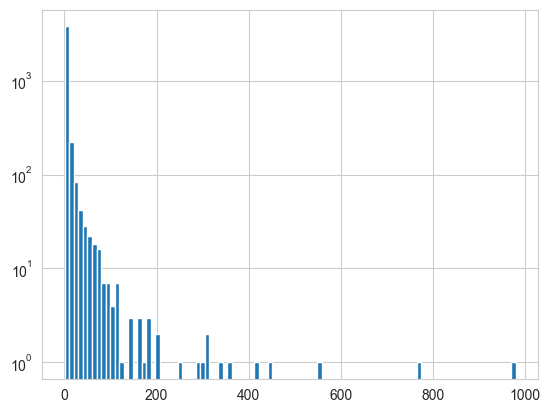

In [107]:
for m in content.postOrCommentText:
  grams.update(clean(m))

plt.hist([i[1] for i in grams.items()], bins=100)
plt.yscale('log')
plt.show()


In [108]:
t = 200
sum([i[1] >= 50 for i in grams.items()])

top_n = 200

vocab = [i[0] for i in sorted(grams.items(), key=lambda x: x[1], reverse=True)[:top_n]]

vocab

['gun',
 'we',
 'people',
 'need',
 'agree',
 'think',
 'our',
 'immigrant',
 'immigration',
 'country',
 'law',
 'if',
 'would',
 'control',
 'get',
 'right',
 'make',
 'way',
 'one',
 'u',
 'many',
 'american',
 'like',
 'want',
 'illegal',
 'good',
 'come',
 'weapon',
 'issue',
 'border',
 'legal',
 'believe',
 'better',
 'citizen',
 'also',
 'stricter',
 'help',
 'criminal',
 'job',
 'problem',
 'work',
 'take',
 'see',
 'point',
 'shooting',
 'state',
 'america',
 'thing',
 'much',
 'well',
 'true',
 'time',
 'mental',
 'mass',
 'could',
 'feel',
 'check',
 'violence',
 'everyone',
 'legally',
 'yes',
 'know',
 'really',
 'background',
 'agreed',
 'definitely',
 'culture',
 'protect',
 'go',
 'government',
 'access',
 'rifle',
 'society',
 'place',
 'still',
 'important',
 'crime',
 'even',
 'absolutely',
 'mean',
 'strict',
 'life',
 'wall',
 'stop',
 'able',
 'health',
 'going',
 'sure',
 'away',
 'assault',
 'keep',
 'exactly',
 'use',
 'something',
 'enough',
 'live',
 'withou

In [109]:
content['text'] = content.postOrCommentText.apply(clean)
content = content[content.text.apply(len) > 0]

<ipython-input-109-04e2f82cc2fd>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  content['text'] = content.postOrCommentText.apply(clean)


In [110]:
d = content[['participantCode','text']].groupby('participantCode').sum().to_dict()['text']
df['text'] = df.participant_code.apply(lambda x: d[x] if x in d else [])

In [111]:
# Create receptacles for the results of the DLA
p_values = []
test_stats = []

# For each of our 1k most frequent words...
for w in vocab:

  # Calculate whether Democrats and Republicans use the word at different rates
  t, p = wf_test(df[[len(t) > 0 for t in df.text]], w, 'condition', ['treat','control'])

  # And add that information to our receptacles
  p_values.append(p)
  test_stats.append(t)

# Put all that information into a convenient dataframe
dla_results = pd.DataFrame({'test_stat': test_stats,
                            'p_values': p_values,
                            'w': vocab})

dla_results['k'] = dla_results.p_values.rank()
m = len(dla_results)
dla_results['p_bh'] = dla_results.apply(lambda x: (x['p_values'] * m)/x['k'], axis=1)
dla_results['t'] = dla_results.apply(lambda x: (x['k']/m)*0.05, axis=1)

dla_results.sort_values('p_values')

,test_stat,p_values,w,k,p_bh,t
6,1.863349,0.062413,our,1.0,12.482636,0.00025
1,1.532795,0.125326,we,2.0,12.532639,0.00050
21,1.330802,0.183254,american,3.0,12.216940,0.00075
2,-1.307982,0.190879,people,4.0,9.543971,0.00100
10,-1.261890,0.206988,law,5.0,8.279539,0.00125
...,...,...,...,...,...,...
67,0.014912,0.988102,protect,196.0,1.008268,0.04900
173,-0.010280,0.991798,language,197.0,1.006901,0.04925
118,0.009151,0.992699,safety,198.0,1.002726,0.04950
54,-0.007456,0.994051,could,199.0,0.999046,0.04975


## Posts

In [112]:
orig_posts = content[pd.isnull(content.parentPost)]

grams = Counter()
lemtzr = WordNetLemmatizer()

for m in orig_posts.postOrCommentText:
  grams.update(clean(m))

top_n = 200

vocab = [i[0] for i in sorted(grams.items(), key=lambda x: x[1], reverse=True)[:top_n]]

vocab

['gun',
 'we',
 'people',
 'need',
 'immigration',
 'think',
 'immigrant',
 'our',
 'country',
 'law',
 'control',
 'if',
 'many',
 'u',
 'would',
 'make',
 'american',
 'get',
 'one',
 'illegal',
 'want',
 'right',
 'believe',
 'way',
 'like',
 'issue',
 'stricter',
 'border',
 'come',
 'weapon',
 'legal',
 'citizen',
 'problem',
 'better',
 'america',
 'state',
 'everyone',
 'work',
 'violence',
 'also',
 'mental',
 'see',
 'help',
 'check',
 'feel',
 'shooting',
 'take',
 'thing',
 'health',
 'criminal',
 'much',
 'mass',
 'rifle',
 'life',
 'background',
 'society',
 'important',
 'time',
 'government',
 'really',
 'legally',
 'assault',
 'coming',
 'job',
 'good',
 'stop',
 'place',
 'going',
 'economy',
 'united',
 'protect',
 'still',
 'enough',
 'ban',
 'home',
 'without',
 'strict',
 'know',
 'access',
 'culture',
 'use',
 'go',
 'keep',
 'able',
 'could',
 'open',
 'family',
 'however',
 'tax',
 'support',
 'away',
 'even',
 'hand',
 'safety',
 'reason',
 'live',
 'year',
 's

In [113]:
orig_posts['text'] = orig_posts.postOrCommentText.apply(clean)
orig_posts = orig_posts[orig_posts.text.apply(len) > 0]
d = orig_posts[['participantCode','text']].groupby('participantCode').sum().to_dict()['text']
df['text'] = df.participant_code.apply(lambda x: d[x] if x in d else [])

<ipython-input-113-2d3105994d43>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  orig_posts['text'] = orig_posts.postOrCommentText.apply(clean)


In [114]:
# Create receptacles for the results of the DLA
p_values = []
test_stats = []

# For each of our 1k most frequent words...
for w in vocab:

  # Calculate whether Democrats and Republicans use the word at different rates
  t, p = wf_test(df[[len(t) > 0 for t in df.text]], w, 'condition', ['treat','control'])

  # And add that information to our receptacles
  p_values.append(p)
  test_stats.append(t)

# Put all that information into a convenient dataframe
dla_results = pd.DataFrame({'test_stat': test_stats,
                            'p_values': p_values,
                            'w': vocab})

dla_results['k'] = dla_results.p_values.rank()
m = len(dla_results)
dla_results['p_bh'] = dla_results.apply(lambda x: (x['p_values'] * m)/x['k'], axis=1)
dla_results['t'] = dla_results.apply(lambda x: (x['k']/m)*0.05, axis=1)

dla_results.sort_values('p_values')

,test_stat,p_values,w,k,p_bh,t
0,-1.739251,0.081991,gun,1.0,16.398139,0.00025
16,1.454707,0.145751,american,2.0,14.575053,0.00050
6,1.212811,0.225202,immigrant,3.0,15.013479,0.00075
3,-1.070072,0.284587,need,4.0,14.229339,0.00100
25,0.986508,0.323884,issue,5.0,12.955351,0.00125
...,...,...,...,...,...,...
185,0.010662,0.991493,owning,196.0,1.011728,0.04900
40,-0.010262,0.991812,mental,197.0,1.006916,0.04925
135,0.003598,0.997129,give,198.0,1.007201,0.04950
60,0.003332,0.997342,legally,199.0,1.002353,0.04975


## Comments

In [115]:
comments = content[pd.notnull(content.parentPost)]

grams = Counter()
lemtzr = WordNetLemmatizer()

for m in comments.postOrCommentText:
  grams.update(clean(m))

top_n = 200

vocab = [i[0] for i in sorted(grams.items(), key=lambda x: x[1], reverse=True)[:top_n]]

vocab

['agree',
 'gun',
 'we',
 'people',
 'need',
 'think',
 'our',
 'if',
 'law',
 'would',
 'immigrant',
 'right',
 'country',
 'get',
 'way',
 'make',
 'one',
 'immigration',
 'good',
 'like',
 'u',
 'true',
 'agreed',
 'point',
 'many',
 'want',
 'american',
 'control',
 'job',
 'yes',
 'exactly',
 'weapon',
 'come',
 'criminal',
 'also',
 'well',
 'issue',
 'definitely',
 'border',
 'legal',
 'absolutely',
 'better',
 'help',
 'illegal',
 'take',
 'could',
 'citizen',
 'see',
 'completely',
 'work',
 'shooting',
 'know',
 'wall',
 'much',
 'time',
 'mean',
 'thing',
 'believe',
 'culture',
 'stricter',
 'legally',
 'crime',
 'go',
 'really',
 'mass',
 'problem',
 'access',
 'even',
 'protect',
 'totally',
 '%',
 'already',
 'background',
 'sure',
 'said',
 'state',
 '100',
 'feel',
 "that's",
 'away',
 'check',
 'mental',
 'lot',
 'still',
 'place',
 'something',
 'strict',
 'able',
 'america',
 'government',
 'though',
 'violence',
 'live',
 'always',
 'benefit',
 'society',
 'keep',


In [116]:
comments['text'] = comments.postOrCommentText.apply(clean)
comments = comments[comments.text.apply(len) > 0]
d = comments[['participantCode','text']].groupby('participantCode').sum().to_dict()['text']
df['text'] = df.participant_code.apply(lambda x: d[x] if x in d else [])

<ipython-input-116-b8f8d8484a1e>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  comments['text'] = comments.postOrCommentText.apply(clean)


In [117]:
# Create receptacles for the results of the DLA
p_values = []
test_stats = []

# For each of our 1k most frequent words...
for w in vocab:

  # Calculate whether Democrats and Republicans use the word at different rates
  t, p = wf_test(df[[len(t) > 0 for t in df.text]], w, 'condition', ['treat','control'])

  # And add that information to our receptacles
  p_values.append(p)
  test_stats.append(t)

# Put all that information into a convenient dataframe
dla_results = pd.DataFrame({'test_stat': test_stats,
                            'p_values': p_values,
                            'w': vocab})

dla_results['k'] = dla_results.p_values.rank()
m = len(dla_results)
dla_results['p_bh'] = dla_results.apply(lambda x: (x['p_values'] * m)/x['k'], axis=1)
dla_results['t'] = dla_results.apply(lambda x: (x['k']/m)*0.05, axis=1)

dla_results.sort_values('p_values')

,test_stat,p_values,w,k,p_bh,t
2,1.700757,0.088989,we,1.0,17.797707,0.00025
6,1.214730,0.224469,our,2.0,22.446911,0.00050
3,-0.999847,0.317384,people,3.0,21.158955,0.00075
23,0.894236,0.371195,point,4.0,18.559769,0.00100
143,-0.763680,0.445058,coyote,5.0,17.802316,0.00125
...,...,...,...,...,...,...
177,0.007999,0.993618,living,196.0,1.013896,0.04900
101,-0.007728,0.993834,use,197.0,1.008969,0.04925
37,-0.007456,0.994051,definitely,198.0,1.004092,0.04950
149,0.004338,0.996539,hurt,199.0,1.001546,0.04975


In [118]:
all_dwell = posts[['participantCode','dwellTimeInSeconds']].groupby('participantCode').sum().to_dict()['dwellTimeInSeconds']
ih_dwell = posts[posts.ih == 1][['participantCode','dwellTimeInSeconds']].groupby('participantCode').sum().to_dict()['dwellTimeInSeconds']

In [119]:
df['all_dwell'] = df.participant_code.apply(lambda x: all_dwell[x])
df['ih_dwell'] = df.participant_code.apply(lambda x: ih_dwell[x])

(array([192., 340., 237., 122.,  72.,  36.,  24.,  10.,   7.,   3.]),
 array([    0. ,  1091.5,  2183. ,  3274.5,  4366. ,  5457.5,  6549. ,
         7640.5,  8732. ,  9823.5, 10915. ]),
 <BarContainer object of 10 artists>)

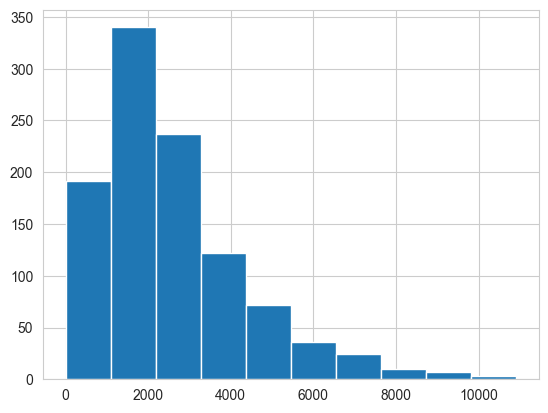

In [120]:
plt.hist(df.all_dwell)

In [121]:
max(df.all_dwell)/(60*19)

9.574561403508772

In [122]:
df.all_dwell.median()

2142.0

In [123]:
df.all_dwell.median()/(60*4)

8.925

# Dwell time as dosage

(array([472., 250., 140.,  80.,  35.,  26.,  19.,  10.,   9.,   2.]),
 array([   0. ,  263.5,  527. ,  790.5, 1054. , 1317.5, 1581. , 1844.5,
        2108. , 2371.5, 2635. ]),
 <BarContainer object of 10 artists>)

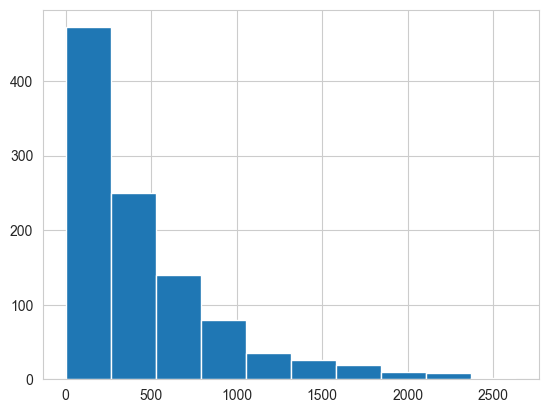

In [124]:
plt.hist(df.ih_dwell)

In [125]:
print(np.mean(df[df.condition == "treat"].dropna(subset=['ih_dwell']).ih_dwell))
print(np.mean(df[df.condition == "pure_control"].dropna(subset=['ih_dwell']).ih_dwell))
print(np.mean(df[df.condition == "control"].dropna(subset=['ih_dwell']).ih_dwell))
print()
print(np.median(df[df.condition == "treat"].dropna(subset=['ih_dwell']).ih_dwell))
print(np.median(df[df.condition == "pure_control"].dropna(subset=['ih_dwell']).ih_dwell))
print(np.median(df[df.condition == "control"].dropna(subset=['ih_dwell']).ih_dwell))
print()
print(stats.ttest_ind(df[df.condition == "control"].dropna(subset=['ih_dwell']).ih_dwell,
                df[df.condition == "treat"].dropna(subset=['ih_dwell']).ih_dwell))

print(stats.mannwhitneyu(df[df.condition == "control"].dropna(subset=['ih_dwell']).ih_dwell,
                df[df.condition == "treat"].dropna(subset=['ih_dwell']).ih_dwell))

407.8003663003663
nan
471.80281690140845

279.0
nan
329.0

Ttest_indResult(statistic=2.24842318501051, pvalue=0.024757762960645933)
MannwhitneyuResult(statistic=144932.5, pvalue=0.056810840638540826)


C:\Users\Austin\anaconda3\lib\site-packages\numpy\core\fromnumeric.py:3440: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\Austin\anaconda3\lib\site-packages\numpy\core\_methods.py:189: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


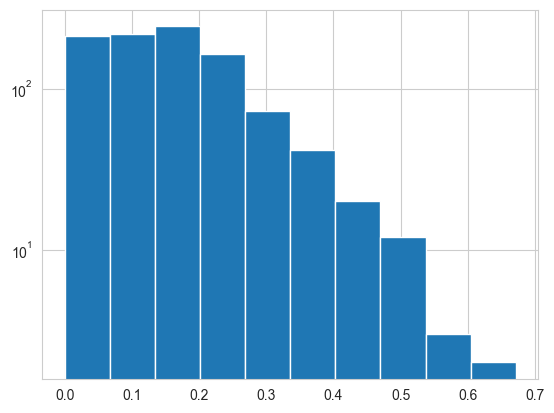

In [126]:
plt.hist(df.ih_dwell/df.all_dwell)
plt.yscale('log')

In [127]:
np.percentile(df.all_dwell, 90)/600

8.338000000000001

In [128]:
df.all_dwell.median()/600

3.57

In [129]:
max(df.all_dwell)/600

18.191666666666666

In [130]:
stats.spearmanr(df[df.condition != "pure_control"].dropna(subset=['ih_dwell','panas']).ih_dwell,
               df[df.condition != "pure_control"].dropna(subset=['ih_dwell','panas']).panas)

SpearmanrResult(correlation=-0.041266208534271154, pvalue=0.18296456295527558)

In [131]:
stats.spearmanr(df[df.condition == "control"].dropna(subset=['ih_dwell','panas']).ih_dwell,
               df[df.condition == "control"].dropna(subset=['ih_dwell','panas']).panas)

SpearmanrResult(correlation=0.027846596774013768, pvalue=0.5356825471839788)

In [132]:
stats.spearmanr(df[df.condition == "treat"].dropna(subset=['ih_dwell','panas']).ih_dwell,
               df[df.condition == "treat"].dropna(subset=['ih_dwell','panas']).panas)

SpearmanrResult(correlation=-0.090218200445419, pvalue=0.03506867063144539)

In [133]:
stats.spearmanr(df.dropna(subset=['ih_dwell','panas']).ih_dwell,
               df.dropna(subset=['ih_dwell','panas']).panas)

SpearmanrResult(correlation=-0.041266208534271154, pvalue=0.18296456295527558)

In [134]:
df['ih_dwell_log'] = np.log(df.ih_dwell + 1)

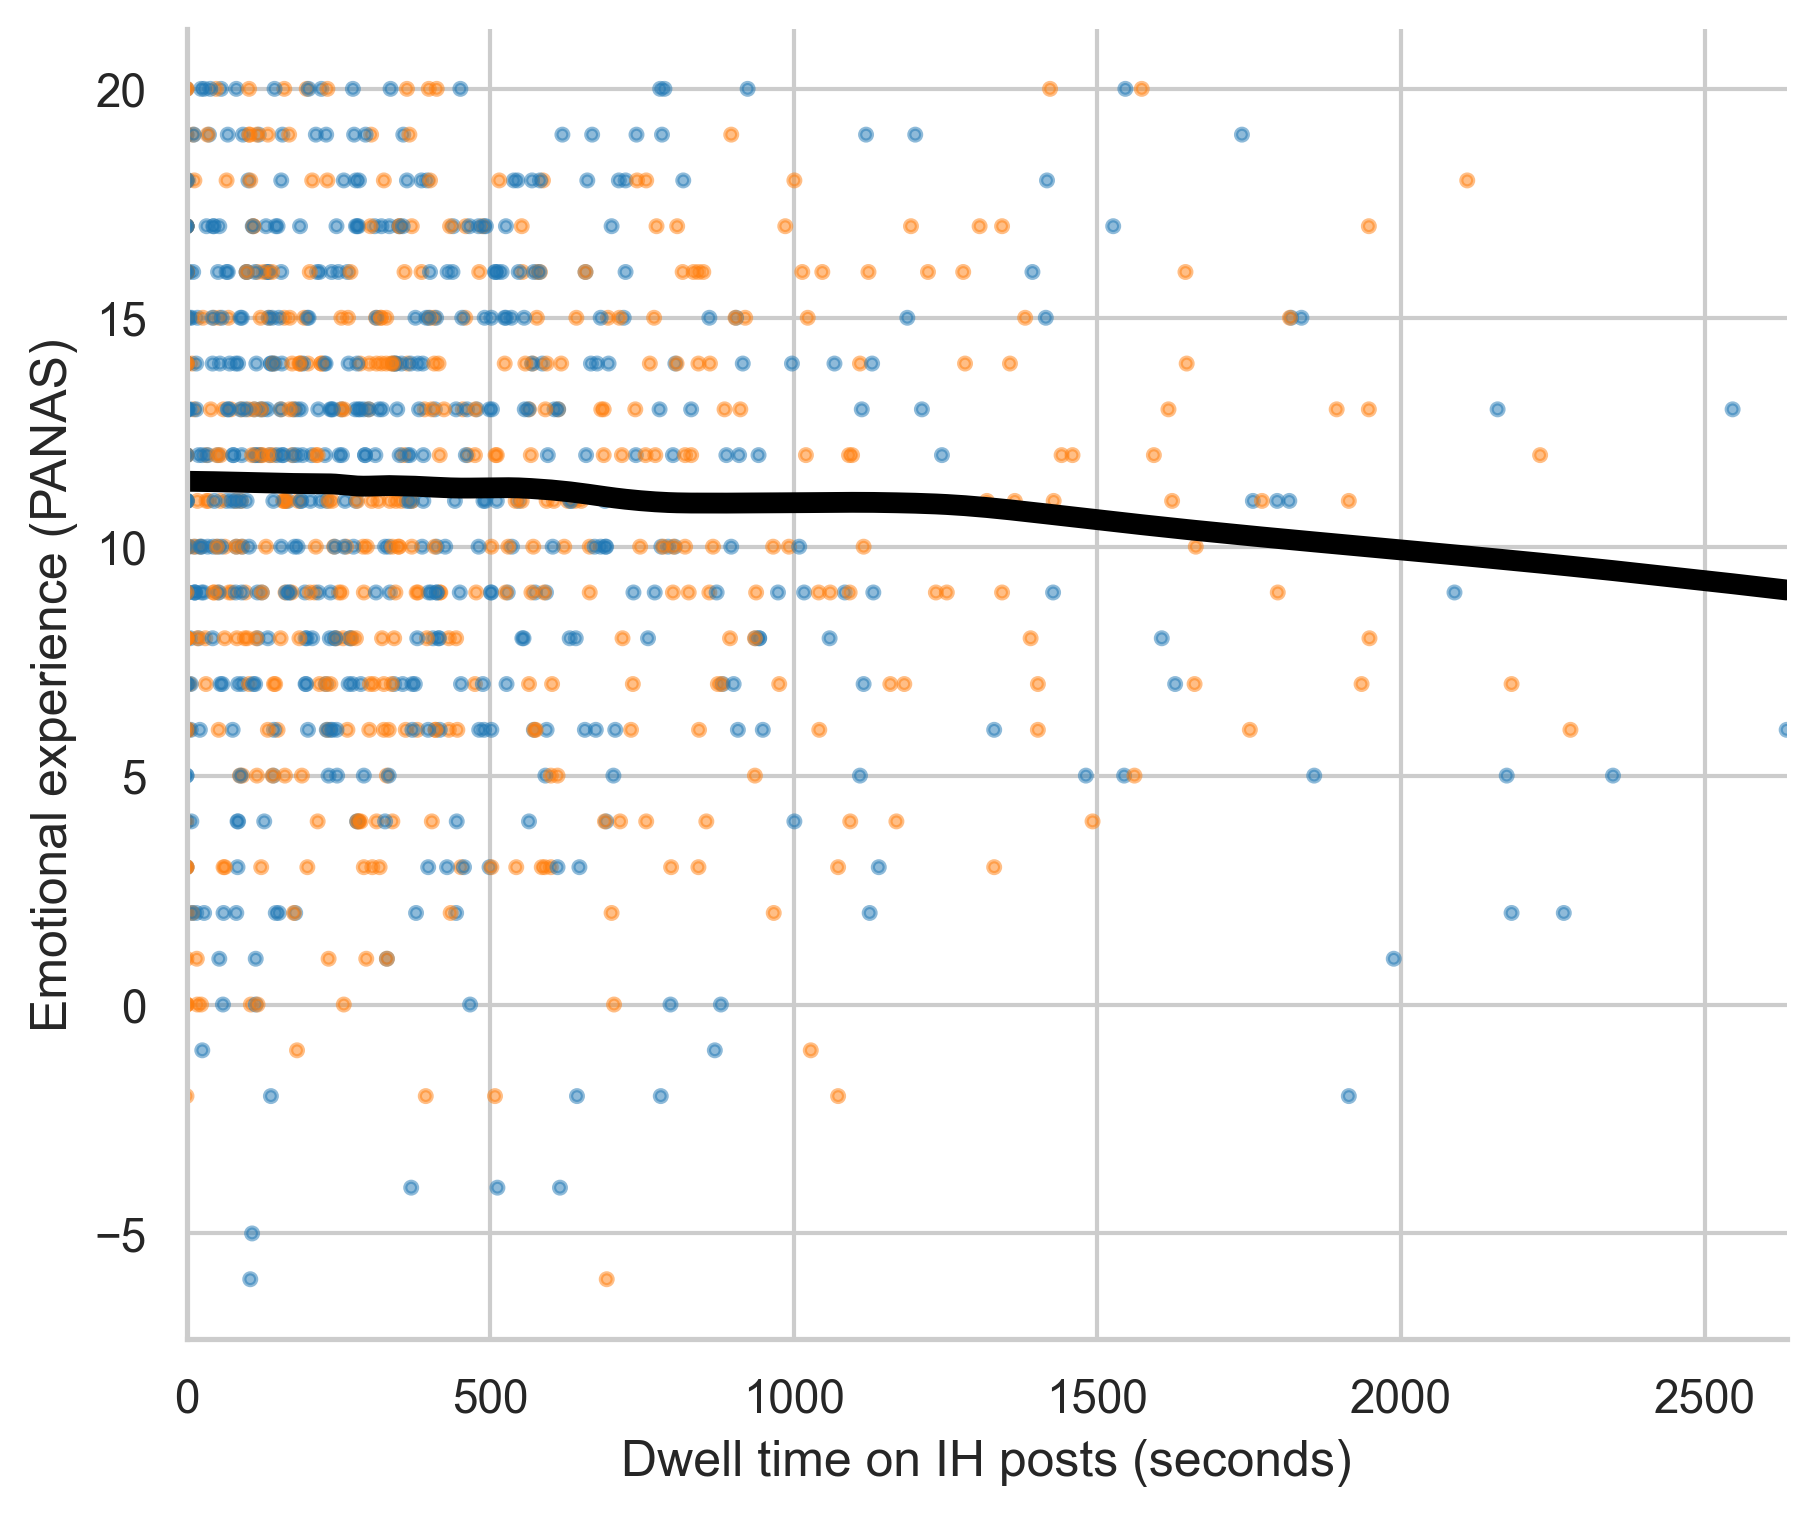

In [135]:
sb.set_theme(rc={'figure.dpi': 300})
sb.set_style("whitegrid")
sb.lmplot(data = df[df.condition != "pure_control"].dropna(subset=['ih_dwell','panas']), 
          x = 'ih_dwell', y = 'panas',
          scatter_kws = {'alpha': 0.5, "color": "grey", 's': 8, 'color': [{'treat': "tab:blue",'control': "tab:orange"}[x] for x in df[df.condition != "pure_control"].dropna(subset=['ih_dwell','panas']).condition]},
          line_kws = {"color": "black", 'lw': "5"},
         lowess=True,
         aspect=1.2)
plt.xlabel("Dwell time on IH posts (seconds)")
plt.ylabel("Emotional experience (PANAS)")
plt.show()

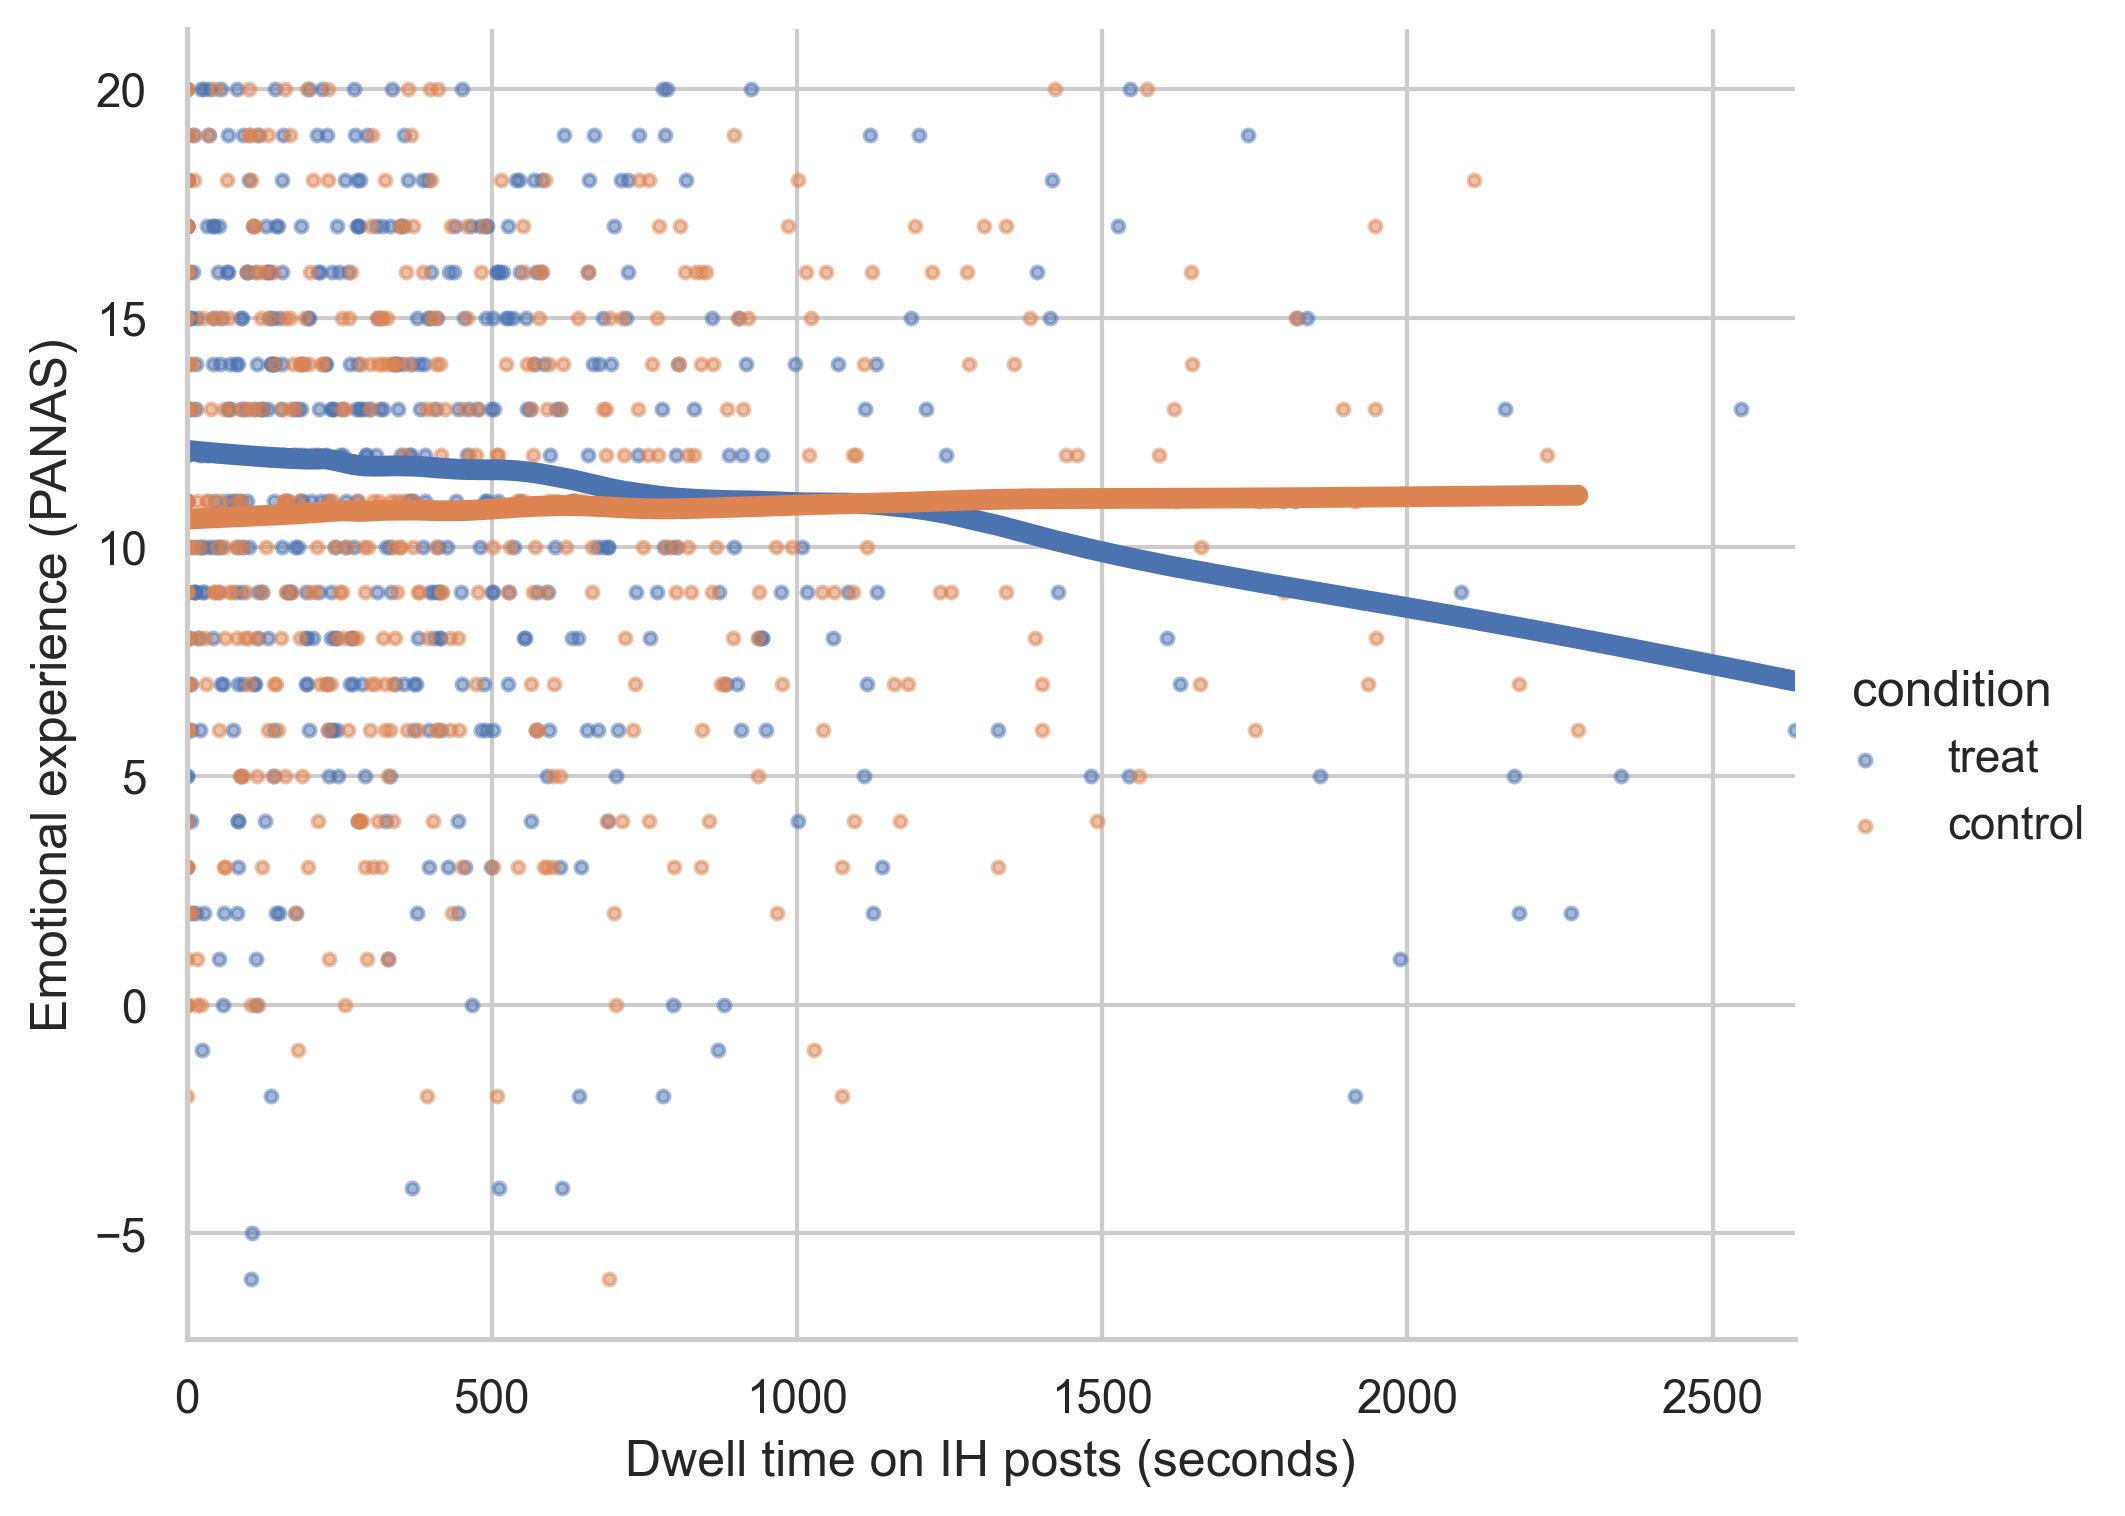

In [136]:
sb.set_theme(rc={'figure.dpi': 300})
sb.set_style("whitegrid")
sb.lmplot(data = df[df.condition != "pure_control"].dropna(subset=['ih_dwell','panas']), 
          x = 'ih_dwell', y = 'panas', hue="condition",
          scatter_kws = {'alpha': 0.5, 's': 8},
          line_kws = {'lw': "5"},
         lowess=True,
         aspect=1.2)
plt.xlabel("Dwell time on IH posts (seconds)")
plt.ylabel("Emotional experience (PANAS)")
plt.show()

In [137]:
ys = ["panas","third_order", "delta_ih", "future_use_n", "engaging", "toxic", "exhausting", "platform",
      "polite", "aggressive", "tolerant", "users", "users_b", "comfort"]

for y in ys:
    print(y)
    print("----------------")
    print(stats.pearsonr(df[df.condition == "treat"].dropna(subset=['ih_dwell',y])[y],
                          df[df.condition == "treat"].dropna(subset=['ih_dwell',y]).ih_dwell))
    print(stats.spearmanr(df[df.condition == "treat"].dropna(subset=['ih_dwell',y])[y],
                          df[df.condition == "treat"].dropna(subset=['ih_dwell',y]).ih_dwell))
    print()
    print(stats.pearsonr(df[df.condition != "pure_control"].dropna(subset=['ih_dwell',y])[y],
                          df[df.condition != "pure_control"].dropna(subset=['ih_dwell',y]).ih_dwell))
    print(stats.spearmanr(df[df.condition != "pure_control"].dropna(subset=['ih_dwell',y])[y],
                          df[df.condition != "pure_control"].dropna(subset=['ih_dwell',y]).ih_dwell))
    print()

panas
----------------
(-0.11743940805508199, 0.0060071929336412795)
SpearmanrResult(correlation=-0.090218200445419, pvalue=0.03506867063144539)

(-0.051898659987935386, 0.0938924709165621)
SpearmanrResult(correlation=-0.041266208534271154, pvalue=0.18296456295527558)

third_order
----------------
(-0.06007995065213218, 0.16094033265414523)
SpearmanrResult(correlation=-0.03381782075303193, pvalue=0.43033207308415755)

(-0.04651324984885367, 0.13330891310622678)
SpearmanrResult(correlation=-0.038067582746859195, pvalue=0.21930320901048536)

delta_ih
----------------
(0.049012667685363526, 0.2529040844220314)
SpearmanrResult(correlation=0.007754697129613453, pvalue=0.856533447754092)

(0.023503964682445498, 0.4485092941651076)
SpearmanrResult(correlation=-0.01537354403120295, pvalue=0.6201117131741276)

future_use_n
----------------
(-0.08887131466947965, 0.03789633153731077)
SpearmanrResult(correlation=-0.0829224259322501, pvalue=0.052804750650684046)

(-0.049368578513287256, 0.11106078

In [138]:
ys = ["panas","third_order", "delta_ih", "future_use_n", "engaging", "toxic", "exhausting", "platform",
      "polite", "aggressive", "tolerant", "users", "users_b", "comfort"]

for y in ys:
    print(y)
    print("----------------")
    print(stats.pearsonr(df[df.condition == "treat"].dropna(subset=['all_dwell',y])[y],
                          df[df.condition == "treat"].dropna(subset=['all_dwell',y]).all_dwell))
    print(stats.spearmanr(df[df.condition == "treat"].dropna(subset=['all_dwell',y])[y],
                          df[df.condition == "treat"].dropna(subset=['all_dwell',y]).all_dwell))
    print()
    print(stats.pearsonr(df[df.condition != "pure_control"].dropna(subset=['all_dwell',y])[y],
                          df[df.condition != "pure_control"].dropna(subset=['all_dwell',y]).all_dwell))
    print(stats.spearmanr(df[df.condition != "pure_control"].dropna(subset=['all_dwell',y])[y],
                          df[df.condition != "pure_control"].dropna(subset=['all_dwell',y]).all_dwell))
    print()

panas
----------------
(-0.10904384054856496, 0.01077982898678584)
SpearmanrResult(correlation=-0.08446554570421279, pvalue=0.04853210485050255)

(-0.037632142607898086, 0.22462477430561878)
SpearmanrResult(correlation=-0.03113606071449329, pvalue=0.31509298823606385)

third_order
----------------
(-0.037563581357730046, 0.3810124175419968)
SpearmanrResult(correlation=-0.02155770210370993, pvalue=0.6152208508746881)

(-0.02724421776916455, 0.3794153717767629)
SpearmanrResult(correlation=-0.022069484002399727, pvalue=0.47647883651979606)

delta_ih
----------------
(0.04626409111048037, 0.28052671696141357)
SpearmanrResult(correlation=-0.009691670406980372, pvalue=0.8212417830636812)

(0.03027723210201966, 0.32886600537028726)
SpearmanrResult(correlation=-0.01788460171609694, pvalue=0.564163369337212)

future_use_n
----------------
(-0.07295838608773864, 0.08853890789799745)
SpearmanrResult(correlation=-0.08680494561671144, pvalue=0.042609257560815336)

(-0.02157600494091754, 0.486395289

In [139]:
df['ih_dwell_p'] = df.ih_dwell/df.all_dwell

In [140]:
ys = ["panas","third_order", "delta_ih", "future_use_n", "engaging", "toxic", "exhausting", "platform",
      "polite", "aggressive", "tolerant", "users", "users_b", "comfort"]

for y in ys:
    print(y)
    print("----------------")
    print(stats.pearsonr(df[df.condition == "treat"].dropna(subset=['ih_dwell_p',y])[y],
                          df[df.condition == "treat"].dropna(subset=['ih_dwell_p',y]).ih_dwell_p))
    print(stats.spearmanr(df[df.condition == "treat"].dropna(subset=['ih_dwell_p',y])[y],
                          df[df.condition == "treat"].dropna(subset=['ih_dwell_p',y]).ih_dwell_p))
    print()
    print(stats.pearsonr(df[df.condition != "pure_control"].dropna(subset=['ih_dwell_p',y])[y],
                          df[df.condition != "pure_control"].dropna(subset=['ih_dwell_p',y]).ih_dwell_p))
    print(stats.spearmanr(df[df.condition != "pure_control"].dropna(subset=['ih_dwell_p',y])[y],
                          df[df.condition != "pure_control"].dropna(subset=['ih_dwell_p',y]).ih_dwell_p))
    print()

panas
----------------
(-0.07166588940108011, 0.09464954996386957)
SpearmanrResult(correlation=-0.08673774792721478, pvalue=0.042961932250298714)

(-0.04211151436173, 0.1848626513933627)
SpearmanrResult(correlation=-0.058879483311750275, pvalue=0.06364239530874581)

third_order
----------------
(-0.05375931396906613, 0.21018804406715738)
SpearmanrResult(correlation=-0.03489006904825442, pvalue=0.41627869501082115)

(-0.027448389821121258, 0.387574522994373)
SpearmanrResult(correlation=-0.02965698036148352, pvalue=0.35052258777440326)

delta_ih
----------------
(0.0361592609504964, 0.39951719438461547)
SpearmanrResult(correlation=0.015078557737106596, pvalue=0.725420140098675)

(0.0018778117449648347, 0.9528970695079075)
SpearmanrResult(correlation=-0.023080914703508995, pvalue=0.467754548354259)

future_use_n
----------------
(-0.043495562296844155, 0.310791582127082)
SpearmanrResult(correlation=-0.07019092086885995, pvalue=0.101655418219262)

(-0.03343126667097721, 0.29259309346009627

In [141]:
print(np.mean(df[df.condition == "treat"].dropna(subset=['ih_dwell_p']).ih_dwell_p))
print(np.mean(df[df.condition == "pure_control"].dropna(subset=['ih_dwell_p']).ih_dwell_p))
print(np.mean(df[df.condition == "control"].dropna(subset=['ih_dwell_p']).ih_dwell_p))
print()
print(np.median(df[df.condition == "treat"].dropna(subset=['ih_dwell_p']).ih_dwell_p))
print(np.median(df[df.condition == "pure_control"].dropna(subset=['ih_dwell_p']).ih_dwell_p))
print(np.median(df[df.condition == "control"].dropna(subset=['ih_dwell_p']).ih_dwell_p))
print()
print(stats.ttest_ind(df[df.condition == "control"].dropna(subset=['ih_dwell_p']).ih_dwell_p,
                df[df.condition == "treat"].dropna(subset=['ih_dwell_p']).ih_dwell_p))

print(stats.mannwhitneyu(df[df.condition == "control"].dropna(subset=['ih_dwell_p']).ih_dwell_p,
                df[df.condition == "treat"].dropna(subset=['ih_dwell_p']).ih_dwell_p))

0.1274443809623333
nan
0.2035824840052433

0.12576909156713717
nan
0.19300090006344708

Ttest_indResult(statistic=11.163723868037563, pvalue=2.4256212528321143e-27)
MannwhitneyuResult(statistic=166850.0, pvalue=2.3830545199794724e-23)


C:\Users\Austin\anaconda3\lib\site-packages\numpy\core\fromnumeric.py:3440: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\Austin\anaconda3\lib\site-packages\numpy\core\_methods.py:189: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


In [142]:


X = ['pid3', 'ideo7', 'race_new', 'device', 'new_educ', 'platforms_fb', 'platforms_insta', 'platforms_tiktok', 'platforms_x', 'platforms_truth', 'political_interest']

for x in X:
    print('{}: {}'.format(x, set(df[x])))

pid3: {'Democrat', 'Independent', 'Republican', 'Other'}
ideo7: {'Somewhat liberal', 'Conservative', 'Extremely liberal', 'Moderate or middle of the road', 'Somewhat conservative', 'Liberal', 'Extremely conservative'}
race_new: {'Mixed/Other', 'Black or African American', 'Asian', 'White', 'Hispanic'}
device: {'Android', 'Apple iPhone'}
new_educ: {'Bachelor’s degree', 'High school graduate or equivalent (GED)', 'Post-graduate degree', 'Some college but no degree', 'Associate degree in college', 'Less than high school'}
platforms_fb: {'Not at all', 'A lot', 'Some'}
platforms_insta: {'Not at all', 'A lot', 'Some'}
platforms_tiktok: {'Some', 'A lot', 'Not at all'}
platforms_x: {'Some', 'A lot', 'Not at all'}
platforms_truth: {'Some', 'A lot', 'Not at all'}
political_interest: {'Almost Never', 'About half the time', 'All the time', 'Once in a while', 'Most of the time'}


# Data Quality/Compliance Analysis

In [143]:
manip_check_correct = []

d = {"treat": 'The degree to which users respectfully engage with and learn from differing opinions.',
     "control": 'The degree to which the user is "popular", or the degree to which they are able to achieve "likes".',
     "pure_control": 'There were no user badges on the platform.'}

for i, row in df.iterrows():
    correct = d[row['condition']]
    manip_check_correct.append(int(correct == row['manip_check']))
    
df['mc_correct'] = manip_check_correct

In [144]:
n_orig_posts = content[pd.isnull(content.parentPost)].groupby('participantCode').size().to_dict()
df['n_op'] = df.participant_code.apply(lambda x: n_orig_posts[x] if x in n_orig_posts else 0)
n_comments = content[pd.notnull(content.parentPost)].groupby('participantCode').size().to_dict()
df['n_comments'] = df.participant_code.apply(lambda x: n_comments[x] if x in n_comments else 0)

In [145]:
df['zip_state_match'] = [int(x) for x in df.zip_state == df.state]
df['speeder'] = [int(x) for x in df.total_duration >= (df.total_duration.median()/2)]
df['commented'] = [int(x) for x in df.n_op > 0]
df['posted'] = [int(x) for x in df.n_comments > 0]
df['passcode'] = df.password.apply(lambda x: 'win' in str(x).lower())

In [204]:
1 - (127/len(df))

0.8782358581016299

In [146]:
print(len(df[(df.mc_correct == 0)]))
print(len(df[df.zip_state_match == 0]))
print(len(df[df.speeder == 0]))
print(len(df[(df.posted == 0)]))
print(len(df[(df.commented == 0)]))
print(len(df[(df.posted == 0) | (df.commented == 0)]))
print(len(df[(df.passcode == 0)]))

128
10
58
175
165
277
127


In [147]:
gold_star = []
for i, row in df.iterrows():
    if sum(row[['mc_correct', 'zip_state_match', 'speeder',
                'posted', 'commented', 'passcode']]) == 6:
        gold_star.append(1)
    else:
        gold_star.append(0)
        
df['gold_star'] = gold_star
df.groupby("gold_star").size()/len(df)

gold_star
0    0.454458
1    0.545542
dtype: float64

In [148]:
stats.mannwhitneyu(df[(df.condition == "treat") & (df.mc_correct==1)].dropna(subset=['panas']).panas,
                df[(df.condition == "control") & (df.mc_correct==1)].dropna(subset=['panas']).panas)

MannwhitneyuResult(statistic=115560.0, pvalue=0.00545560555611743)

In [149]:
x1 = df[(df.condition == "treat")].dropna(subset=['panas']).panas
x2 = df[(df.condition == "control")].dropna(subset=['panas']).panas
print((x1.mean() - x2.mean())/pd.concat([x1, x2]).std())

0.137416858229873


In [150]:
x1 = df[(df.condition == "treat") & (df.mc_correct==1)].dropna(subset=['panas']).panas
x2 = df[(df.condition == "control") & (df.mc_correct==1)].dropna(subset=['panas']).panas
print((x1.mean() - x2.mean())/pd.concat([x1, x2]).std())

0.16735423752959033


In [151]:
x1 = df[(df.condition == "treat") & (df.speeder==1)].dropna(subset=['panas']).panas
x2 = df[(df.condition == "control") & (df.speeder==1)].dropna(subset=['panas']).panas
print((x1.mean() - x2.mean())/pd.concat([x1, x2]).std())

0.13615518352574682


In [152]:
x1 = df[(df.condition == "treat") & (df.gold_star==1)].dropna(subset=['panas']).panas
x2 = df[(df.condition == "control") & (df.gold_star==1)].dropna(subset=['panas']).panas
print((x1.mean() - x2.mean())/pd.concat([x1, x2]).std())

0.11287045356272402


In [153]:
stats.mannwhitneyu(df[(df.condition == "treat") & (df.gold_star==1)].dropna(subset=['panas']).panas,
                df[(df.condition == "control") & (df.gold_star==1)].dropna(subset=['panas']).panas)

MannwhitneyuResult(statistic=43191.0, pvalue=0.11486844801611619)

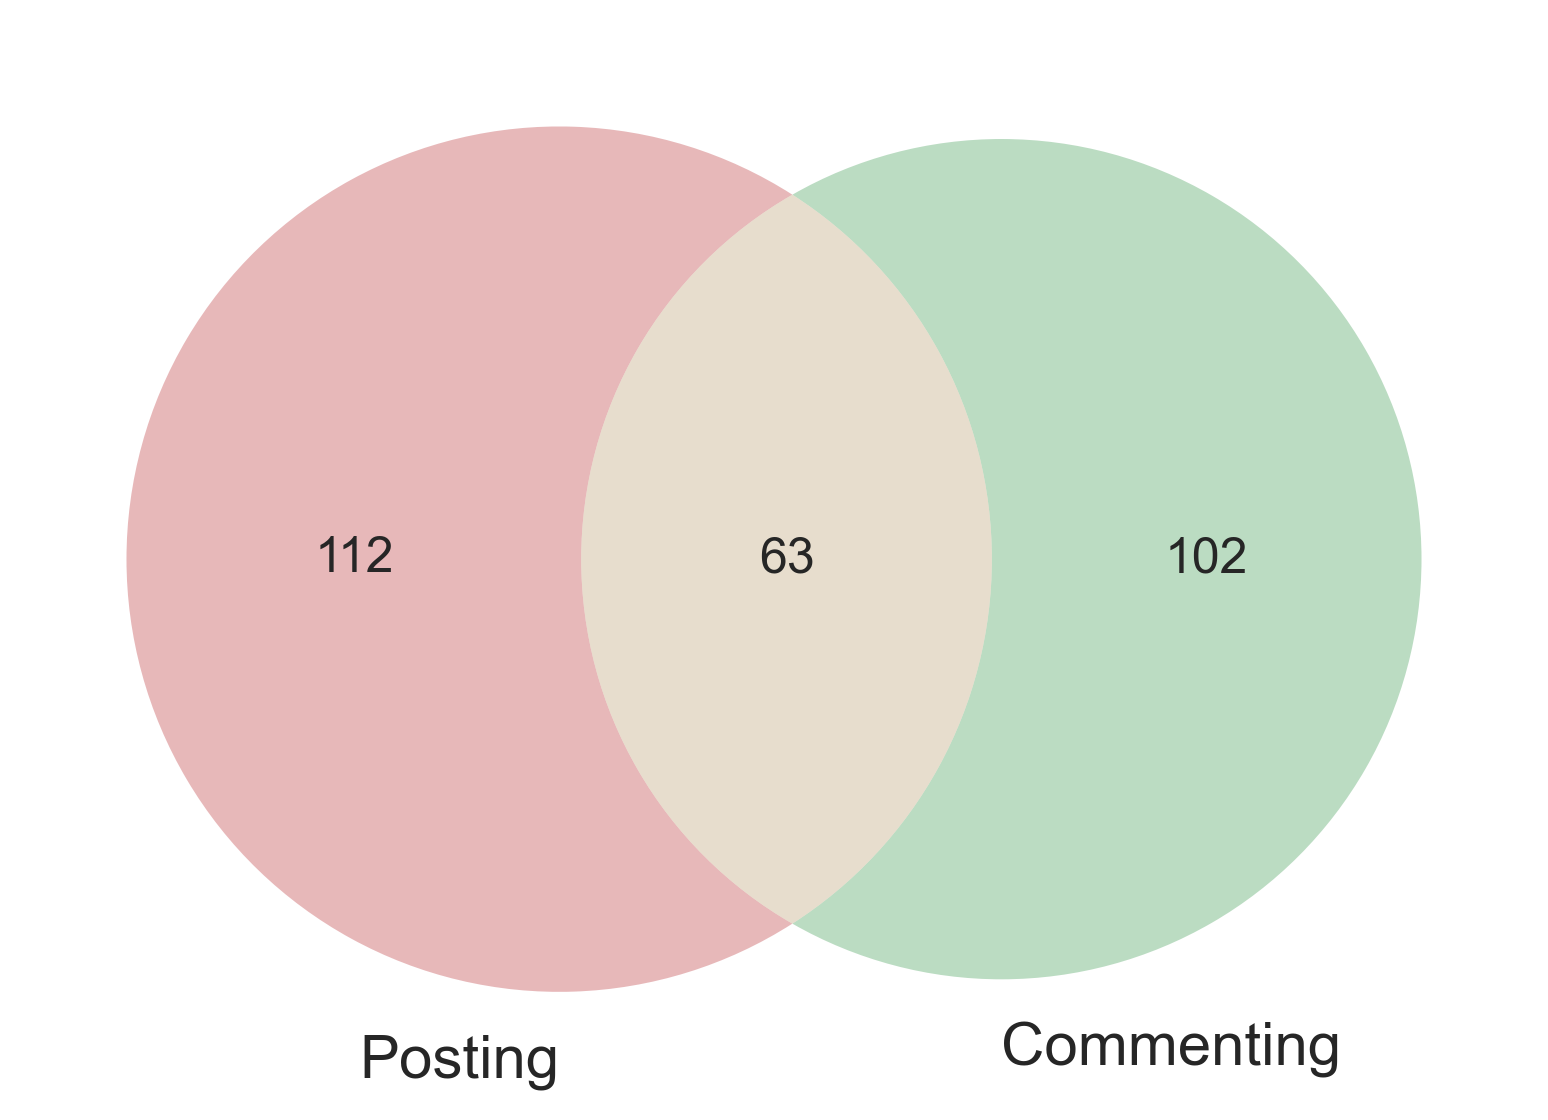

In [154]:
from matplotlib_venn import venn2

venn2([set(df[df.posted == 0].participant_code),
      set(df[df.commented == 0].participant_code)],
     ["Posting", "Commenting"])

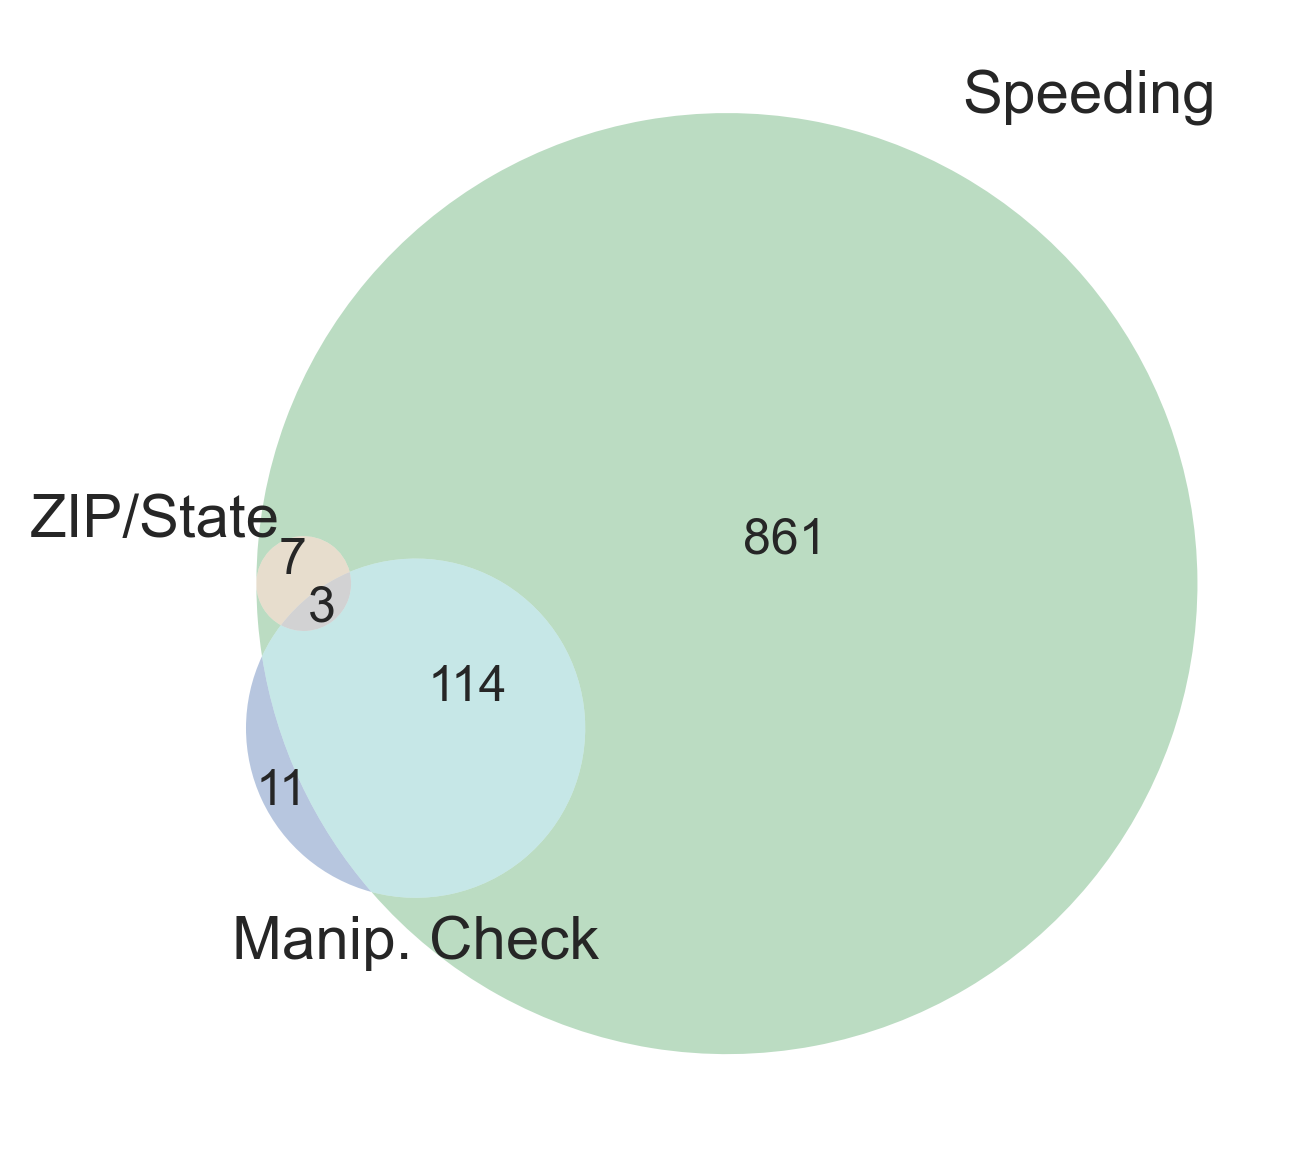

In [155]:
from matplotlib_venn import venn3

venn3([set(df[df.zip_state_match == 0].participant_code),
      set(df[df.speeder == 1].participant_code),
      set(df[df.mc_correct == 0].participant_code)],
     ["ZIP/State", "Speeding", "Manip. Check"])

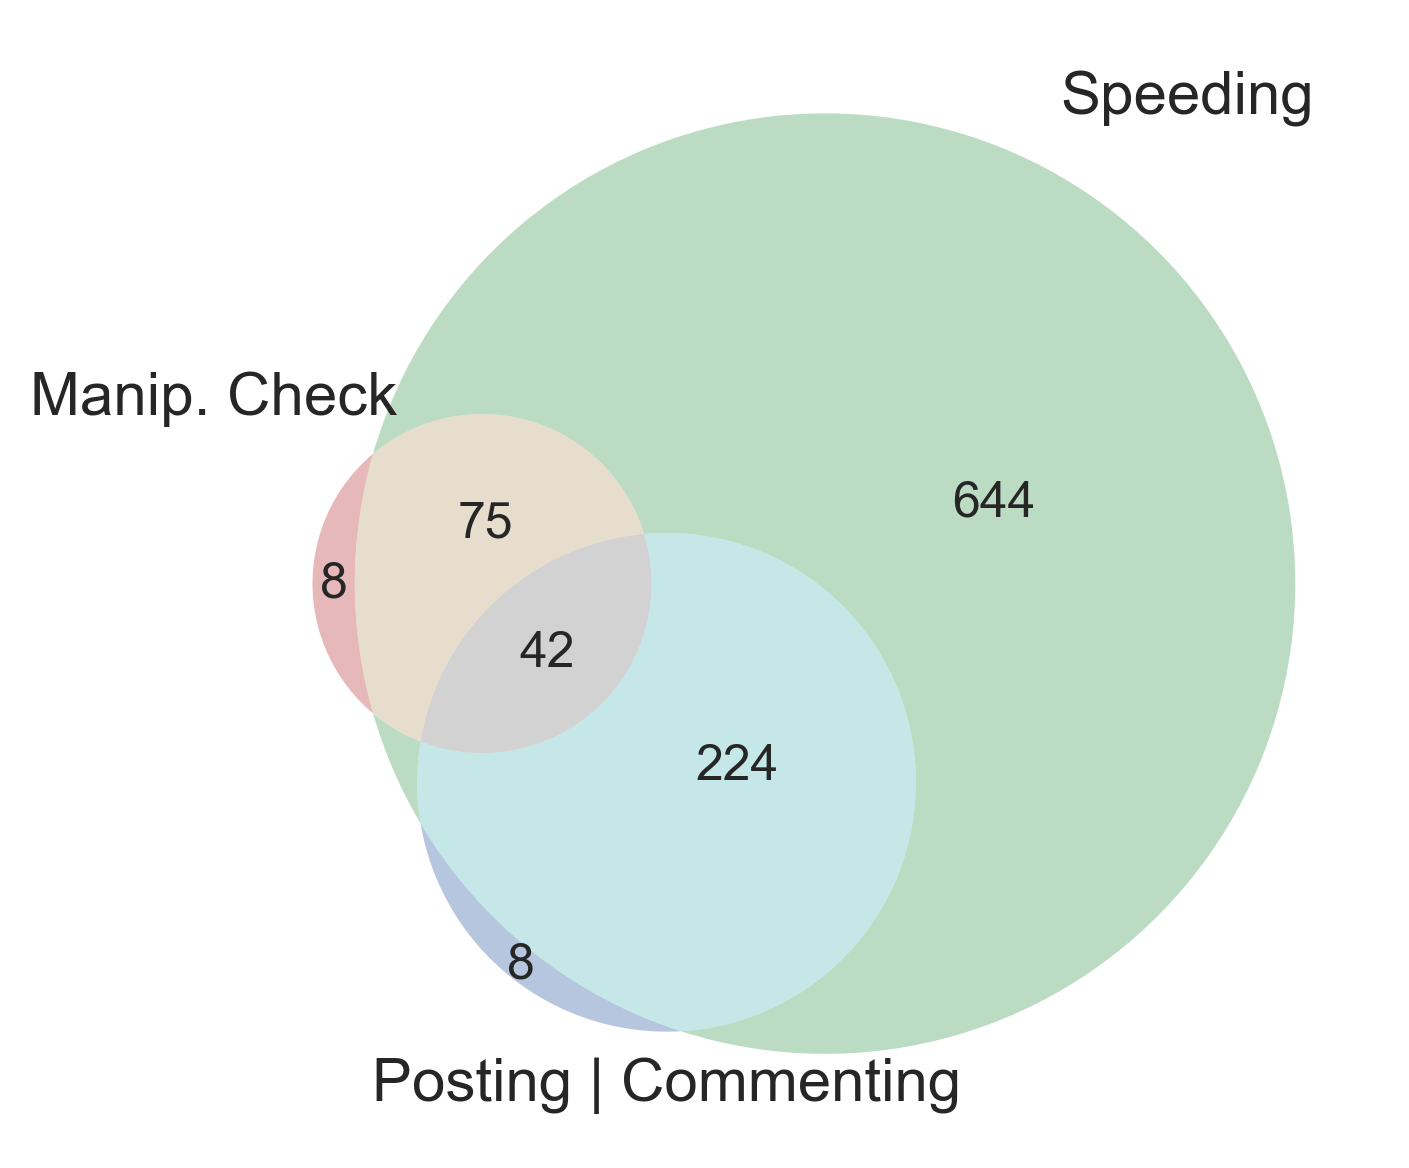

In [156]:
from matplotlib_venn import venn3

venn3([set(df[df.mc_correct == 0].participant_code),
      set(df[df.speeder == 1].participant_code),
      set(df[(df.posted == 0) | (df.commented == 0)].participant_code)],
     ["Manip. Check", "Speeding", "Posting | Commenting"])

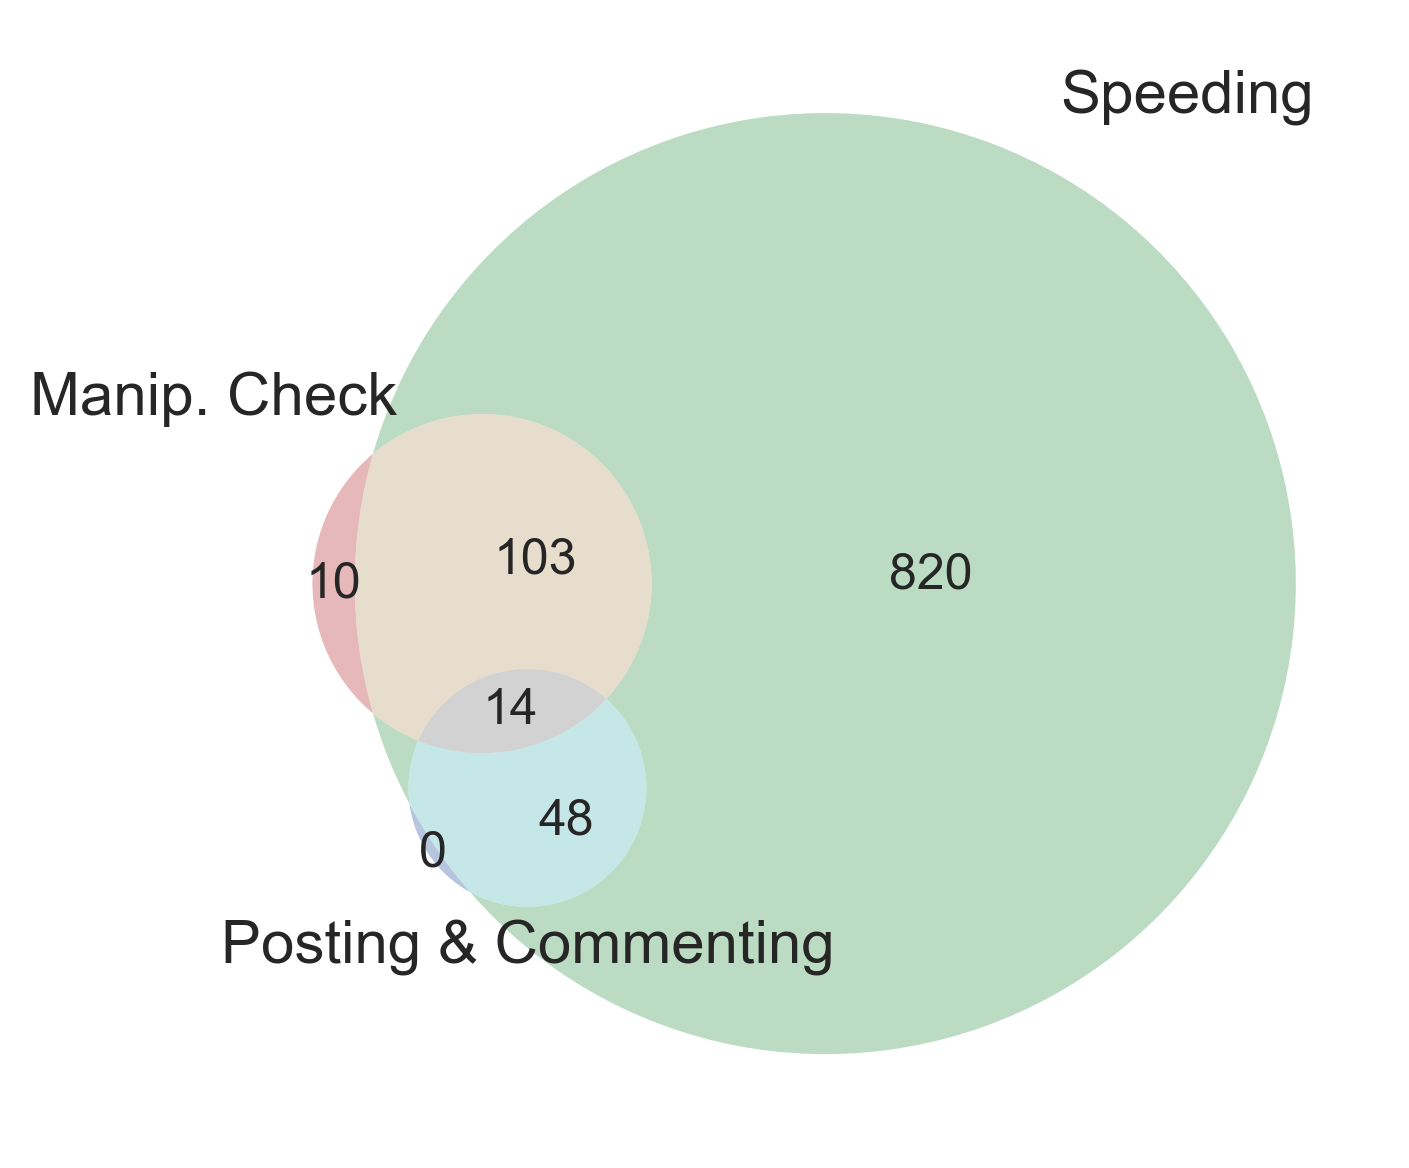

In [157]:
from matplotlib_venn import venn3

venn3([set(df[df.mc_correct == 0].participant_code),
      set(df[df.speeder == 1].participant_code),
      set(df[(df.posted == 0) & (df.commented == 0)].participant_code)],
     ["Manip. Check", "Speeding", "Posting & Commenting"])

# Attrition Analysis

In [205]:
intake = pd.read_csv("intake.csv")

new_codes = {'56e130548b1c33000a388671': 'VATZ46',
             '6287f4819c5fc8c4d48cc885': 'AVX9QE',
             '601d69a993d94008fb2b25dc': 'YWTGUB',
             '650464007006929ee0cd9695': 'ZWTG94',
             '614ce6a7a33bac955957f7a6': 'TPZZQA',
             '6317511c1dd0acb82cf4b131': 'VQWK3M',
             '5e3ae8e5ebfb032f9058ef33': 'KB39HV',
             '6554d0515dc2a90a0f6b3ae3': 'VNPHMU',
             '5ec59e86c9569f5e8000717b': 'ZN3EYY',
             '5ee834d45f0f48129a79b683': 'UGED4M'}

drops = {'a43n36','a6punv','84z39x','9eemkf','7wgznu','xx43nc'}

#intake = pd.read_csv("intake.csv").dropna(subset="participant_code")
intake['participant_code'] = intake.apply(lambda x: x['participant_code'] if x['PROLIFIC_PID'] not in new_codes else new_codes[x['PROLIFIC_PID']], axis=1)
intake['participant_code'] = intake.participant_code.apply(lambda x: x.lower() if pd.notnull(x) else x)

pretreat = pd.read_csv("pre.csv")
posttreat = pd.read_csv("post.csv")

total_n = len(intake)
print("STARTED INTAKE: {}".format(total_n))

consent_drop = len(intake[intake.Consent == 'No, I do NOT consent'])
print("Did not consent: {} ({}%)".format(consent_drop, round((consent_drop/total_n)*100, 1)))

jive_drop = len(intake[(intake.platforms_jive == 'A lot') | (intake.platforms_jive == 'Some')])
print("Reported using JiveHive: {} ({}%)".format(jive_drop, round((jive_drop/total_n)*100, 1)))

device_drop = len(intake[(intake.device == 'Something else')])
print("Reported not having iPhone or Android: {} ({}%)".format(device_drop, round((device_drop/total_n)*100, 1)))

download_drop = len(intake[(intake.download_apple == 'No, I am NOT') | (intake.download_android == 'No, I am NOT')])
print("Not willing to download app: {} ({}%)".format(download_drop, round((download_drop/total_n)*100, 1)))

image_drop = len(intake[(intake.screen_image != 3.0) & pd.notnull(intake.screen_image)])
print("Could not identify number 3: {} ({}%)".format(image_drop, round((image_drop/total_n)*100, 1)))

age_drop = len(intake[(intake.age < 18) & pd.notnull(intake.age)])
print("Less than eighteen years old: {} ({}%)".format(age_drop, round((age_drop/total_n)*100, 1)))

us_drop = len(intake[intake.state == "I do not reside in the United States"])
print("Does not reside in US: {} ({}%)".format(us_drop, round((us_drop/total_n)*100, 1)))

forced_attrit = consent_drop + jive_drop + device_drop + download_drop + image_drop + age_drop + us_drop

intake_completes = len(intake.dropna(subset=['participant_code']))
unforced_attrit_intake = (total_n - intake_completes) - forced_attrit

print("Unforced attrition in intake: {} ({}%)".format(unforced_attrit_intake, round((unforced_attrit_intake/total_n)*100, 1)))

print("FINISHED INTAKE: {}".format(intake_completes))

pretreat_n = len(pretreat)
attrit_intake_pretreat = intake_completes - pretreat_n

print("Lost while downloading app: {} ({}%)".format(attrit_intake_pretreat, round((attrit_intake_pretreat/total_n)*100, 1)))

print("STARTED PRETREAT: {}".format(pretreat_n))

pretreat_completes = len(pretreat[pd.notnull(pretreat['Q111_Page Submit'])])

print("FINISHED PRETREAT: {}".format(pretreat_completes))

posttreat_n = len(posttreat)

attrit_pre_post = pretreat_completes - posttreat_n

print("Lost during newsfeed: {} ({}%)".format(attrit_pre_post, round((attrit_pre_post/total_n)*100, 1)))

print("STARTED PROSTTREAT: {}".format(posttreat_n))

posttreat_completes = len(posttreat[posttreat.Progress >= 93])

print("FINISHED POSTTREAT: {}".format(posttreat_completes))

STARTED INTAKE: 1836
Did not consent: 4 (0.2%)
Reported using JiveHive: 60 (3.3%)
Reported not having iPhone or Android: 4 (0.2%)
Not willing to download app: 11 (0.6%)
Could not identify number 3: 0 (0.0%)
Less than eighteen years old: 0 (0.0%)
Does not reside in US: 0 (0.0%)
Unforced attrition in intake: 17 (0.9%)
FINISHED INTAKE: 1740
Lost while downloading app: 139 (7.6%)
STARTED PRETREAT: 1601
FINISHED PRETREAT: 1600
Lost during newsfeed: 56 (3.1%)
STARTED PROSTTREAT: 1544
FINISHED POSTTREAT: 1544


In [159]:
np.random.seed(8675309)
intake['participant_code'] = intake.participant_code.apply(lambda x: str(x).lower() if pd.notnull(x) else 'FAKE_' + 
                                                           str(np.random.randint(999999999)))

# Pandas merge is being weird...

a = set(intake.participant_code)
b = set(pretreat.participant_code)
c = set(posttreat.participant_code)

#attrit_ids = a.difference(b).union(a.intersection(b))

#intake = intake[[i in attrit_ids for i in intake.participant_code]]
#pretreat = pretreat[[i in attrit_ids for i in pretreat.participant_code]]
#posttreat = posttreat[[i in attrit_ids for i in posttreat.participant_code]]

df_attrit = intake.merge(pretreat, on="participant_code",how="left", suffixes=('_intake', '_pretreat'))
df_attrit = df_attrit.merge(posttreat, how="left",on="participant_code")
df_attrit = df_attrit[[i not in drops for i in df_attrit.participant_code]]

# Participant who completed multiple pretreatment surveys
df_attrit = df_attrit[df_attrit.participant_code != 'zyw7q7']

df_attrit

,StartDate_intake,EndDate_intake,Status_intake,IPAddress_intake,Progress_intake,Duration (in seconds)_intake,Finished_intake,RecordedDate_intake,ResponseId_intake,RecipientLastName_intake,...,timer.open.end_Last Click,timer.open.end_Page Submit,timer.open.end_Click Count,feedback,timer.complete.code_First Click,timer.complete.code_Last Click,timer.complete.code_Page Submit,timer.complete.code_Click Count,Party1_post,Party2_post
0,12/12/2023 10:12,12/12/2023 10:18,IP Address,24.29.192.116,100,375,True,12/12/2023 10:18,R_3NWyN7ZVsrM9asN,NaN,...,35.231,35.852,2.0,I didn't experience any harassment or glitches.,0.000,0.000,62.077,0.0,Democratic,Republican
1,12/12/2023 10:27,12/12/2023 10:28,IP Address,98.200.184.129,100,33,True,12/12/2023 10:28,R_2qDXm3Mh3EKVNJg,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,12/12/2023 10:31,12/12/2023 10:35,IP Address,66.212.218.70,100,248,True,12/12/2023 10:35,R_1MPR9oqcVLSh9Ha,NaN,...,2.664,8.279,1.0,No problems,0.000,0.000,7.101,0.0,Democratic,Republican
3,12/12/2023 10:34,12/12/2023 10:37,IP Address,71.74.10.152,100,204,True,12/12/2023 10:37,R_1eyLOxZm3bXJ1lT,NaN,...,2.800,5.433,1.0,No,0.000,0.000,21.084,0.0,Democratic,Republican
4,12/12/2023 10:34,12/12/2023 10:39,IP Address,24.197.171.212,100,277,True,12/12/2023 10:39,R_2bPhZcnomsC5oyS,NaN,...,0.000,2.973,0.0,NaN,7.153,11.275,24.198,2.0,Democratic,Republican
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1839,12/13/2023 14:33,12/13/2023 14:37,IP Address,68.228.153.94,91,292,False,12/15/2023 0:35,R_1sfvIQFMtG78jgB,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1840,12/13/2023 14:33,12/13/2023 14:35,IP Address,66.27.188.175,91,114,False,12/15/2023 0:35,R_6pIjHzoMgYjrgyJ,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1841,12/13/2023 14:33,12/13/2023 14:47,IP Address,76.37.101.134,91,801,False,12/15/2023 0:35,R_2edVn7q7TMK2uAR,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1842,12/13/2023 10:26,12/13/2023 10:50,IP Address,12.75.8.141,91,1414,False,12/15/2023 0:36,R_bIxafuZRwgEfyqB,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [160]:
end_time = []

for i, row in df_attrit.iterrows():
    if pd.notnull(row['EndDate']):
        end_time.append(row['EndDate'])
    elif pd.notnull(row['EndDate_pretreat']):
        end_time.append(row['EndDate_pretreat'])
    elif pd.notnull(row['EndDate_intake']):
        end_time.append(row['EndDate_intake'])
    else:
        frmt = '%m/%d/%Y %H:%M'
        start = datetime.strptime(row['StartDate_intake'], frmt)
        duration = datetime.timedelta(seconds=int(df_attrit['Duration (in seconds)_intake']))
        end_time.append(datetime.strftime(start+duration, frmt))
        
df_attrit['end_time'] = end_time

## Identifying Crash Survivors

In [161]:
crash_times = [('12/12/2023 11:25', '12/12/2023 11:27'),
               ('12/12/2023 11:31', '12/12/2023 11:33'),
               ('12/12/2023 11:36', '12/12/2023 11:38'),
               ('12/12/2023 11:42', '12/12/2023 11:44'),
               ('12/13/2023 14:50', '12/13/2023 14:50'),
               ('12/13/2023 14:56', '12/13/2023 14:58'),
               ('12/13/2023 15:14', '12/13/2023 15:16'),
               ('12/13/2023 15:17', '12/13/2023 15:19'),
               ('12/13/2023 15:22', '12/13/2023 15:24'),
               ('12/13/2023 15:24', '12/13/2023 15:26')]

frmt = '%m/%d/%Y %H:%M'
crash_times = [(datetime.strptime(x[0], frmt), datetime.strptime(x[1], frmt)) for x in crash_times]

In [162]:
survivors = []

for i, row in df_attrit.iterrows():
    start = datetime.strptime(row['StartDate_intake'], frmt)
    end = datetime.strptime(row['end_time'], frmt)
    for crash in crash_times:
        crash_start = crash[0]
        crash_end = crash[1]
        pid = row['participant_code']
        if end < crash_start:
            pass
        elif start > crash_end:
            pass
        else:
            survivors.append(pid)
            
survivors = set(survivors)
df_attrit['crash'] = df_attrit['participant_code'].apply(lambda x: x in survivors)
sum(df_attrit.crash)

241

In [163]:
# Party ID

pid7_cat = []
pid7_num = []
for i, row in df_attrit.iterrows():
  if row['pid3'] in ['Other', 'Independent']:
    if row['pid_lean'] == "Closer to Republican Party":
      pid7_cat.append("Lean Republican")
      pid7_num.append(3)
    elif row['pid_lean'] == 'Closer to Democratic Party':
      pid7_cat.append("Lean Democrat")
      pid7_num.append(5)
    elif row['pid_lean'] == "Neither":
      pid7_cat.append("True Independent/Other")
      pid7_num.append(4)
    else:
      pid7_cat.append(None)
      pid7_num.append(None)
  elif row['pid3'] == "Republican":
    if row['pid_strong'] == "Not very strong ${q://QID41/ChoiceGroup/SelectedChoices}":
      pid7_cat.append("Weak Republican")
      pid7_num.append(2)
    elif row['pid_strong'] == 'Strong ${q://QID41/ChoiceGroup/SelectedChoices}':
      pid7_cat.append("Strong Republican")
      pid7_num.append(1)
    else:
      pid7_cat.append(None)
      pid7_num.append(None)
  elif row['pid3'] == "Democrat":
    if row['pid_strong'] == "Not very strong ${q://QID41/ChoiceGroup/SelectedChoices}":
      pid7_cat.append("Weak Democrat")
      pid7_num.append(6)
    elif row['pid_strong'] == 'Strong ${q://QID41/ChoiceGroup/SelectedChoices}':
      pid7_cat.append("Strong Democrat")
      pid7_num.append(7)
    else:
      pid7_cat.append(None)
      pid7_num.append(None)
  else:
    pid7_cat.append(None)
    pid7_num.append(None)

df_attrit['pid7_cat'] = pid7_cat
df_attrit['pid7_num'] = pid7_num

# Party ID Extremity

df_attrit['pid_extreme'] = df_attrit.pid7_num.apply(lambda x: abs(x-4) if pd.notnull(x) else None)

# Ideo7

d = {'Extremely conservative': 1,
     'Conservative': 2,
     'Somewhat conservative': 3,
     'Moderate or middle of the road': 4,
     'Somewhat liberal': 5,
     'Liberal': 6,
     'Extremely liberal': 7}

df_attrit['ideo7_num'] = df_attrit.ideo7.apply(lambda x: d[x] if x in d else None)

# Ideology Extreme

df_attrit['ideo_extreme'] = df_attrit.ideo7_num.apply(lambda x: abs(x-4) if pd.notnull(x) else None)

## Dropped while downloading app

In [164]:
df_attrit['drop_download'] = (['fake_' not in i for i in df_attrit.participant_code] & pd.isnull(df_attrit.StartDate_pretreat)).values
df_attrit['drop_download'] = df_attrit.drop_download.apply(lambda x: int(x))
sum(df_attrit.drop_download)

246

In [165]:
pd.crosstab(df_attrit.crash, df_attrit.drop_download)

drop_download,0,1
crash,,
False,1376,212
True,207,34


In [166]:
stats.chi2_contingency(pd.crosstab(df_attrit.crash, df_attrit.drop_download))

(0.048380452462646314,
 0.8259057578419444,
 1,
 array([[1374.41443412,  213.58556588],
        [ 208.58556588,   32.41443412]]))

In [167]:
df_attrit[['crash','drop_download']].groupby('crash').mean()*100

,drop_download
crash,
False,13.350126
True,14.107884


In [168]:
print(smf.logit(formula='drop_download ~ pid7_num', data=df_attrit).fit().summary())
print(smf.logit(formula='drop_download ~ C(pid7_num)', data=df_attrit).fit().summary())
print(smf.logit(formula='drop_download ~ pid_extreme', data=df_attrit).fit().summary())
print(smf.logit(formula='drop_download ~ C(pid_extreme)', data=df_attrit).fit().summary())
print(smf.logit(formula='drop_download ~ ideo7_num', data=df_attrit).fit().summary())
print(smf.logit(formula='drop_download ~ C(ideo7_num)', data=df_attrit).fit().summary())
print(smf.logit(formula='drop_download ~ ideo_extreme', data=df_attrit).fit().summary())
print(smf.logit(formula='drop_download ~ C(ideo_extreme)', data=df_attrit).fit().summary())

Optimization terminated successfully.
         Current function value: 0.293860
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:          drop_download   No. Observations:                 1733
Model:                          Logit   Df Residuals:                     1731
Method:                           MLE   Df Model:                            1
Date:                Wed, 21 Feb 2024   Pseudo R-squ.:                0.002155
Time:                        14:32:34   Log-Likelihood:                -509.26
converged:                       True   LL-Null:                       -510.36
Covariance Type:            nonrobust   LLR p-value:                    0.1380
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -2.6839      0.244    -11.013      0.000      -3.162      -2.206
pid7_num       0.0662      0.

In [169]:
df_attrit[['pid_extreme','drop_download']].groupby('pid_extreme').mean()*100

,drop_download
pid_extreme,
0.0,7.220217
1.0,8.080808
2.0,6.315789
3.0,11.884550


In [170]:
df_attrit[['ideo_extreme','drop_download']].groupby('ideo_extreme').mean()*100

,drop_download
ideo_extreme,
0.0,8.009709
1.0,6.233766
2.0,8.885017
3.0,11.602210


## Dropped During Newsfeed

In [171]:
df_attrit['drop_newsfeed'] = (pd.notnull(df_attrit.EndDate_pretreat) & pd.isnull(df_attrit.StartDate)).values
df_attrit['drop_newsfeed'] = df_attrit.drop_newsfeed.apply(lambda x: int(x))
sum(df_attrit.drop_newsfeed)

49

In [172]:
pd.crosstab(df_attrit.crash, df_attrit.drop_newsfeed)

drop_newsfeed,0,1
crash,,
False,1544,44
True,236,5


In [173]:
stats.chi2_contingency(pd.crosstab(df_attrit.crash, df_attrit.drop_newsfeed))

(0.16770962046439097,
 0.6821554140489541,
 1,
 array([[1545.45653362,   42.54346638],
        [ 234.54346638,    6.45653362]]))

In [174]:
print(smf.logit(formula='drop_newsfeed ~ pid7_num', data=df_attrit).fit().summary())
print(smf.logit(formula='drop_newsfeed ~ C(pid7_num)', data=df_attrit).fit().summary())
print(smf.logit(formula='drop_newsfeed ~ pid_extreme', data=df_attrit).fit().summary())
print(smf.logit(formula='drop_newsfeed ~ C(pid_extreme)', data=df_attrit).fit().summary())
print(smf.logit(formula='drop_newsfeed ~ ideo7_num', data=df_attrit).fit().summary())
print(smf.logit(formula='drop_newsfeed ~ C(ideo7_num)', data=df_attrit).fit().summary())
print(smf.logit(formula='drop_newsfeed ~ ideo_extreme', data=df_attrit).fit().summary())
print(smf.logit(formula='drop_newsfeed ~ C(ideo_extreme)', data=df_attrit).fit().summary())

Optimization terminated successfully.
         Current function value: 0.128496
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:          drop_newsfeed   No. Observations:                 1733
Model:                          Logit   Df Residuals:                     1731
Method:                           MLE   Df Model:                            1
Date:                Wed, 21 Feb 2024   Pseudo R-squ.:                0.001531
Time:                        14:32:34   Log-Likelihood:                -222.68
converged:                       True   LL-Null:                       -223.02
Covariance Type:            nonrobust   LLR p-value:                    0.4086
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -3.2534      0.363     -8.972      0.000      -3.964      -2.543
pid7_num      -0.0600      0.

In [175]:
df_attrit[['ideo7_num','drop_newsfeed']].groupby('ideo7_num').mean() * 100

,drop_newsfeed
ideo7_num,
1.0,9.836066
2.0,1.226994
3.0,2.547771
4.0,4.611650
5.0,2.631579
6.0,1.459854
7.0,1.993355


In [176]:
df_attrit[['ideo_extreme','drop_newsfeed']].groupby('ideo_extreme').mean() * 100

,drop_newsfeed
ideo_extreme,
0.0,4.611650
1.0,2.597403
2.0,1.393728
3.0,3.314917


In [177]:
condition = {'imm_treat': "treat",
             'gc_treat': "treat",
             'imm_pc': "pure_control",
             'gc_pc': "pure_control",
             "imm_control1": "control",
             "imm_control2": "control",
             "imm_control3": "control",
             "gc_control1": "control",
             "gc_control2": "control",
             "gc_control3": "control",
             np.NaN: None}

df_attrit['condition'] = df_attrit.treatment_arm.apply(lambda x: condition[x])

In [178]:
d = df_attrit[(pd.notnull(df_attrit.condition)) & (df_attrit.condition != "pure_control")]

print(smf.logit(formula='drop_newsfeed ~ pid7_num + condition + pid7_num:condition', data=d).fit().summary())
print(smf.logit(formula='drop_newsfeed ~ C(pid7_num) + condition + C(pid7_num):condition', data=d).fit().summary())
print(smf.logit(formula='drop_newsfeed ~ pid_extreme + condition + pid_extreme:condition', data=d).fit().summary())
print(smf.logit(formula='drop_newsfeed ~ C(pid_extreme) + condition + C(pid_extreme):condition', data=d).fit().summary())
print(smf.logit(formula='drop_newsfeed ~ ideo7_num + condition + ideo7_num:condition', data=d).fit().summary())
print(smf.logit(formula='drop_newsfeed ~ C(ideo7_num) + condition + C(ideo7_num):condition', data=d).fit().summary())
print(smf.logit(formula='drop_newsfeed ~ ideo_extreme + condition + ideo_extreme:condition', data=d).fit().summary())
print(smf.logit(formula='drop_newsfeed ~ C(ideo_extreme) + condition + C(ideo_extreme):condition', data=d).fit().summary())

Optimization terminated successfully.
         Current function value: 0.128900
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:          drop_newsfeed   No. Observations:                 1074
Model:                          Logit   Df Residuals:                     1070
Method:                           MLE   Df Model:                            3
Date:                Wed, 21 Feb 2024   Pseudo R-squ.:                 0.01431
Time:                        14:32:34   Log-Likelihood:                -138.44
converged:                       True   LL-Null:                       -140.45
Covariance Type:            nonrobust   LLR p-value:                    0.2595
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept                      -2.6012      0.555     -4.685      0.000   

C:\Users\Austin\anaconda3\lib\site-packages\statsmodels\base\model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Austin\anaconda3\lib\site-packages\statsmodels\base\model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Austin\anaconda3\lib\site-packages\statsmodels\base\model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Austin\anaconda3\lib\site-packages\statsmodels\base\model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## Descriptives of Attriters

In [179]:
attrits = df_attrit[['FAKE_' not in i for i in df_attrit.participant_code] & pd.isnull(df_attrit['timer.open.end_Page Submit'])]
attrits

,StartDate_intake,EndDate_intake,Status_intake,IPAddress_intake,Progress_intake,Duration (in seconds)_intake,Finished_intake,RecordedDate_intake,ResponseId_intake,RecipientLastName_intake,...,end_time,crash,pid7_cat,pid7_num,pid_extreme,ideo7_num,ideo_extreme,drop_download,drop_newsfeed,condition
8,12/12/2023 10:42,12/12/2023 10:46,IP Address,172.56.232.20,100,260,True,12/12/2023 10:46,R_1ovWRsTazevEqrC,NaN,...,12/12/2023 10:50,False,Lean Democrat,5.0,1.0,2.0,2.0,0,1,treat
11,12/12/2023 10:47,12/12/2023 10:52,IP Address,70.172.10.126,100,316,True,12/12/2023 10:52,R_A0bUYP96OoyE9cl,NaN,...,12/12/2023 10:57,False,Lean Republican,3.0,1.0,4.0,0.0,0,1,control
14,12/12/2023 10:48,12/12/2023 10:54,IP Address,97.136.130.11,100,382,True,12/12/2023 10:54,R_2U9jy3LjRkkoU0M,NaN,...,12/12/2023 10:54,False,Weak Republican,2.0,2.0,2.0,2.0,1,0,None
47,12/12/2023 11:19,12/12/2023 11:22,IP Address,172.58.164.94,100,151,True,12/12/2023 11:22,R_sGVY6sNKzv9S5Ut,NaN,...,12/12/2023 11:24,False,Strong Republican,1.0,3.0,1.0,3.0,0,1,control
53,12/12/2023 11:17,12/12/2023 11:23,IP Address,73.141.239.109,100,411,True,12/12/2023 11:24,R_3hmaNvd3zkO4eox,NaN,...,12/12/2023 11:25,True,Lean Democrat,5.0,1.0,7.0,3.0,0,1,pure_control
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1839,12/13/2023 14:33,12/13/2023 14:37,IP Address,68.228.153.94,91,292,False,12/15/2023 0:35,R_1sfvIQFMtG78jgB,NaN,...,12/13/2023 14:37,False,Strong Democrat,7.0,3.0,7.0,3.0,1,0,None
1840,12/13/2023 14:33,12/13/2023 14:35,IP Address,66.27.188.175,91,114,False,12/15/2023 0:35,R_6pIjHzoMgYjrgyJ,NaN,...,12/13/2023 14:35,False,Lean Democrat,5.0,1.0,5.0,1.0,1,0,None
1841,12/13/2023 14:33,12/13/2023 14:47,IP Address,76.37.101.134,91,801,False,12/15/2023 0:35,R_2edVn7q7TMK2uAR,NaN,...,12/13/2023 14:47,False,Strong Republican,1.0,3.0,2.0,2.0,1,0,None
1842,12/13/2023 10:26,12/13/2023 10:50,IP Address,12.75.8.141,91,1414,False,12/15/2023 0:36,R_bIxafuZRwgEfyqB,NaN,...,12/13/2023 11:03,False,True Independent/Other,4.0,0.0,4.0,0.0,0,1,control


In [180]:
# Race

race_new = []
for i, row in attrits.iterrows():
  if pd.isnull(row['race ']):
    race_new.append("Missing")
  elif row['race '] == "Hispanic,White":
    race_new.append('Hispanic')
  elif row['race '] == "Something else":
    race_new.append("Mixed/Other")
  elif len(row['race '].split(',')) > 1:
    race_new.append('Mixed/Other')
  else:
    race_new.append(row['race '])
    
attrits['race_new'] = race_new

# Education

new_educ = []

for i, row in attrits.iterrows():
  done = False
  for n in range(1,10):
    if pd.notnull(row['educ_' + str(n)]):
      new_educ.append(row['educ_' + str(n)])
      done = True
  if not done:
    new_educ.append("Missing")

attrits['new_educ'] = new_educ

# Partisan ID

attrits['pid3'] = attrits.pid3.apply(lambda x: "Missing" if pd.isnull(x) else x)

# Ideology

attrits['ideo7'] = attrits.ideo7.apply(lambda x: "Missing" if pd.isnull(x) else x)

<ipython-input-180-1a4136e56156>:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  attrits['race_new'] = race_new
<ipython-input-180-1a4136e56156>:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  attrits['new_educ'] = new_educ
<ipython-input-180-1a4136e56156>:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/inde

In [181]:
for d in ['pid3','ideo7','race_new','new_educ']:
    print(attrits.groupby(d).size()/len(attrits))
    print()

pid3
Democrat       0.497487
Independent    0.296482
Other          0.035176
Republican     0.170854
dtype: float64

ideo7
Conservative                      0.095477
Extremely conservative            0.065327
Extremely liberal                 0.206030
Liberal                           0.201005
Moderate or middle of the road    0.261307
Somewhat conservative             0.055276
Somewhat liberal                  0.115578
dtype: float64

race_new
Asian                        0.040201
Black or African American    0.236181
Hispanic                     0.105528
Mixed/Other                  0.055276
White                        0.562814
dtype: float64

new_educ
Associate degree in college                 0.095477
Bachelor’s degree                           0.361809
High school graduate or equivalent (GED)    0.170854
Less than high school                       0.010050
Post-graduate degree                        0.160804
Some college but no degree                  0.201005
dtype: float64



In [182]:
attrits.age.median()

38.0

In [183]:
for d in ['pid3','ideo7','race_new','new_educ']:
    print(df.groupby(d).size()/len(df))
    print()

pid3
Democrat       0.477469
Independent    0.294343
Other          0.039310
Republican     0.188878
dtype: float64

ideo7
Conservative                      0.093001
Extremely conservative            0.033557
Extremely liberal                 0.165868
Liberal                           0.240652
Moderate or middle of the road    0.231064
Somewhat conservative             0.093001
Somewhat liberal                  0.142857
dtype: float64

race_new
Asian                        0.089166
Black or African American    0.151486
Hispanic                     0.090125
Mixed/Other                  0.069990
White                        0.599233
dtype: float64

new_educ
Associate degree in college                 0.122723
Bachelor’s degree                           0.341323
High school graduate or equivalent (GED)    0.139022
Less than high school                       0.012464
Post-graduate degree                        0.131352
Some college but no degree                  0.253116
dtype: float64



In [184]:
df.age.median()

35.0

# Open-Ended Manipulation Check

In [185]:
np.random.seed(8675309)
list(df[df.condition == "treat"].sample(100).open_badge)

['The badge is earned if one respects others opinions on the discussed button.',
 nan,
 "To earn the badge you must be respectful (i.e. do not insult, harass, or bully those with different opinions). I imagine they must also be open minded and able to hold a conversation where they're willing to let their mind be changed. ",
 'If they engage in conversations about topics and have different opinions and change of opinions throughout time. ',
 'Seeing both and responding to people that may or may not agree with them',
 'I think you can easily recieve the badge if your posts seemed to gain a lot of attention and sparked a lot of conversation. ',
 'If you agreed with someone even when they changed your mind.',
 'I think that polite language and engaging with all types of posts would help earn that badge.',
 'Having a bland weak take',
 'Having a good mix of followers and likes from people all over the spectrum of thought.',
 'open minded, a user than engaged in a post or conversation that 

In [186]:
np.random.seed(8675309)
list(df[df.condition == "control"].sample(100).open_badge)

['Posting a lot and getting reactions and comments from people ',
 'Posting things that many people would agree with and therefore like',
 'Being popular getting likes. Making an engaging message or post to people',
 'Interacting more with posts, posting more, and having many people react and interact with your post. ',
 'Receiving a lot of “likes” from other users',
 nan,
 'Being positive and good natured.',
 'I believe having a lot of activity on the platform would lead to a wider audience, leading to a greater amount of people to witness your posts and to interact with ',
 "I think it's posting a lot of generic content that they think will be pleasing ",
 'I would expect users earned the popular badge by posting controversial things that got a lot of views and engagement. ',
 'Posting more frequently to allow more chances to gain Likes from other users would be my first guess. The content of the post would also be important but if the goal is to drive engagement then saying controve

In [187]:
def wf_test(d, w, y, y_values, text="text"):
  '''
  d = a Pandas dataframe
  w = the word to be analyzed (i.e., a string)
  y = the characteristic the two groups differ on (name of the column in d)
  y_values = the two values of the y characteristic to test against (e.g., ['D', 'R'])
  Returns: the results of a scipy ranksums test of whether the two groups used
           w at the same rate
  '''
  # For each row in the data, at what rate was the word w used?
  X = d[text].apply(lambda x: x.count(w)/len(x))

  # Create a convenient dataframe with this information as well as each rows'
  # value of Y
  r = pd.DataFrame({'X': X, "Y": d[y]})

  # Compare the two groups' values of X using a ranksums test
  return stats.ranksums(r[r.Y==y_values[0]].X,
                        r[r.Y==y_values[1]].X)

stops = stopwords.words('english')
stops

#Add tokens to our list of stop words
stops += ['.',',','’',':','&','!','qt','-','"','?','“','”',')','(','/',"'",'–',
          '*',';','‘','>','<','u']

#Remove tokens from our list of stop words
for w in ['he','we','she','our','if']:
  stops.remove(w)

grams = Counter()
lemtzr = WordNetLemmatizer()

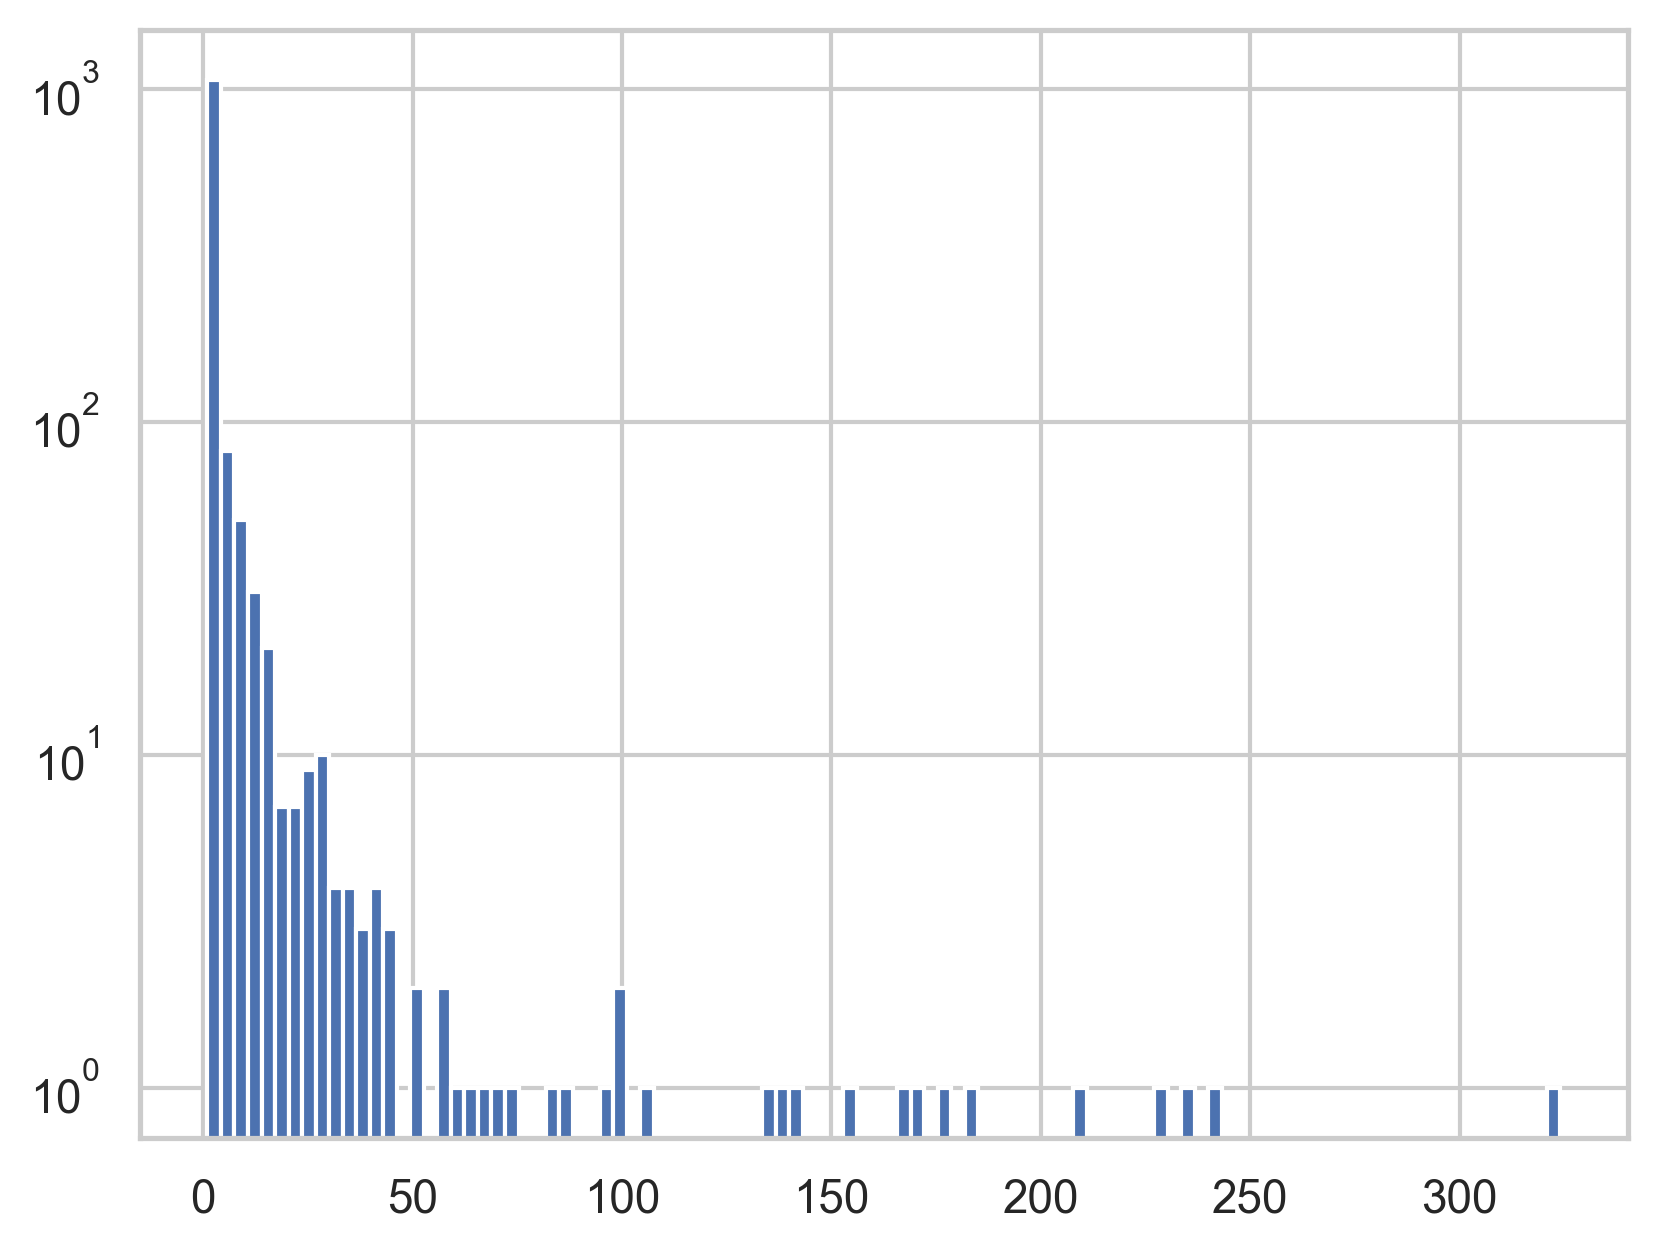

['post',
 'like',
 'badge',
 'opinion',
 'user',
 'people',
 'would',
 'lot',
 'open',
 'think',
 'engaging',
 'others',
 'if',
 'comment',
 'posting',
 'earn',
 'respectful',
 'view',
 'minded',
 'popular',
 'get',
 'engagement',
 'conversation',
 'someone',
 'different',
 'polite',
 'many',
 'side',
 'agree',
 'commenting',
 'getting',
 'platform',
 'also',
 'well',
 'respectfully',
 'active',
 'discussion',
 'differing',
 'person',
 'willing',
 'without',
 'content',
 'way',
 'good',
 'engage',
 'one',
 'making',
 'follower',
 'manner',
 'point']

In [188]:
def wf_test(d, w, y, y_values, text="text"):
  '''
  d = a Pandas dataframe
  w = the word to be analyzed (i.e., a string)
  y = the characteristic the two groups differ on (name of the column in d)
  y_values = the two values of the y characteristic to test against (e.g., ['D', 'R'])
  Returns: the results of a scipy ranksums test of whether the two groups used
           w at the same rate
  '''
  # For each row in the data, at what rate was the word w used?
  X = d[text].apply(lambda x: int(w in x))

  # Create a convenient dataframe with this information as well as each rows'
  # value of Y
  r = pd.DataFrame({'X': X, "Y": d[y]})

  # Compare the two groups' values of X using a ranksums test
  return stats.ranksums(r[r.Y==y_values[0]].X,
                        r[r.Y==y_values[1]].X)

stops = stopwords.words('english')
stops

#Add tokens to our list of stop words
stops += ['.',',','’',':','&','!','qt','-','"','?','“','”',')','(','/',"'",'–',
          '*',';','‘','>','<','u']

#Remove tokens from our list of stop words
for w in ['he','we','she','our','if']:
  stops.remove(w)

grams = Counter()
lemtzr = WordNetLemmatizer()

def clean(s, stops=stops, tknzr=tknzr, lemtzr=lemtzr):
  '''
  Function that takes in a string and returns a "clean" list of words.

  s should be a string, stops should be an iterable (e.g. a list or set), and
  tknzr should be an object with a method .tokenize() which takes in a string
  and returns an iterable (e.g. a list or set).
  '''

  #lowercase the string
  s = s.lower()

  #tokenize the string
  s = tknzr.tokenize(s)

  #remove stop words
  s = [w for w in s if w not in stops]

  #remove empty string chunks and lemmatize
  s = [lemtzr.lemmatize(w) for w in s if len(w) > 0]

  return s

for m in df.open_badge:
    if pd.notnull(m):
        grams.update(clean(m))

plt.hist([i[1] for i in grams.items()], bins=100)
plt.yscale('log')
plt.show()

top_n = 50

vocab = [i[0] for i in sorted(grams.items(), key=lambda x: x[1], reverse=True)[:top_n]]

vocab

In [189]:
dla_df = df[pd.notnull(df.open_badge)]
dla_df['open_badge_clean'] = dla_df.open_badge.apply(clean)
dla_df = dla_df[[len(x) > 0 for x in dla_df.open_badge_clean]]

# Create receptacles for the results of the DLA
p_values = []
test_stats = []

# For each of our 1k most frequent words...
for w in vocab:

  # Calculate whether Democrats and Republicans use the word at different rates
  t, p = wf_test(dla_df, w, 'condition', ['treat','control'], text="open_badge_clean")

  # And add that information to our receptacles
  p_values.append(p)
  test_stats.append(t)

# Put all that information into a convenient dataframe
dla_results = pd.DataFrame({'test_stat': test_stats,
                            'p_values': p_values,
                            'w': vocab})

dla_results['k'] = dla_results.p_values.rank()
m = len(dla_results)
dla_results['p_bh'] = dla_results.apply(lambda x: (x['p_values'] * m)/x['k'], axis=1)
dla_results['t'] = dla_results.apply(lambda x: (x['k']/m)*0.05, axis=1)

dla_results.sort_values('p_values')

<ipython-input-189-f8989dcef75d>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dla_df['open_badge_clean'] = dla_df.open_badge.apply(clean)


,test_stat,p_values,w,k,p_bh,t
1,-10.088793,6.192617e-24,like,1.0,3.096309e-22,0.001
8,7.912729,2.518062e-15,open,2.0,6.295156e-14,0.002
7,-7.313979,2.593454e-13,lot,3.0,4.322424e-12,0.003
0,-6.923724,4.399217e-12,post,4.0,5.499021e-11,0.004
3,5.777057,7.601867e-09,opinion,5.0,7.601867e-08,0.005
18,3.845060,1.205229e-04,minded,6.0,1.004358e-03,0.006
14,-3.762213,1.684168e-04,posting,7.0,1.202977e-03,0.007
19,-3.754525,1.736708e-04,popular,8.0,1.085442e-03,0.008
11,3.373450,7.423265e-04,others,9.0,4.124036e-03,0.009
13,-3.227721,1.247807e-03,comment,10.0,6.239036e-03,0.010


In [190]:
dla_results[dla_results.p_bh < 0.05].sort_values('test_stat')

,test_stat,p_values,w,k,p_bh,t
1,-10.088793,6.192617e-24,like,1.0,3.096309e-22,0.001
7,-7.313979,2.593454e-13,lot,3.0,4.322424e-12,0.003
0,-6.923724,4.399217e-12,post,4.0,5.499021e-11,0.004
14,-3.762213,1.684168e-04,posting,7.0,1.202977e-03,0.007
19,-3.754525,1.736708e-04,popular,8.0,1.085442e-03,0.008
13,-3.227721,1.247807e-03,comment,10.0,6.239036e-03,0.010
21,-3.011767,2.597321e-03,engagement,12.0,1.082217e-02,0.012
17,2.620709,8.774721e-03,view,14.0,3.133829e-02,0.014
24,2.686803,7.213949e-03,different,13.0,2.774596e-02,0.013
16,3.021864,2.512230e-03,respectful,11.0,1.141923e-02,0.011


In [191]:
len(dla_results[dla_results.p_bh < 0.05])

14

In [192]:
df.to_csv("Cleaned_study_data.csv", index=False)

# All Descriptives

In [193]:
set(df.post_policy_1)

{'Agree',
 'Disagree',
 'Neither agree nor disagree',
 'Somewhat agree',
 'Somewhat disagree',
 'Strongly agree',
 'Strongly disagree'}

In [194]:
# Affective Polarization

def pre_ingroup_warm(x):
    if x['pid3'] == "Democrat":
        if x['Party1'] == "Democratic":
            return x['pre_therm_1']
        else:
            return x['pre_therm_2']
    elif x['pid3'] == "Republican":
        if x['Party1'] == "Republican":
            return x['pre_therm_1']
        else:
            return x['pre_therm_2']
    else:
        return None
    
def pre_outgroup_warm(x):
    if x['pid3'] == "Republican":
        if x['Party1'] == "Democratic":
            return x['pre_therm_1']
        else:
            return x['pre_therm_2']
    elif x['pid3'] == "Democrat":
        if x['Party1'] == "Republican":
            return x['pre_therm_1']
        else:
            return x['pre_therm_2']
    else:
        return None
    
def post_ingroup_warm(x):
    if x['pid3'] == "Democrat":
        if x['Party1_post'] == "Democratic":
            return x['post_therm_1']
        else:
            return x['post_therm_2']
    elif x['pid3'] == "Republican":
        if x['Party1_post'] == "Republican":
            return x['post_therm_1']
        else:
            return x['post_therm_2']
    else:
        return None
    
def post_outgroup_warm(x):
    if x['pid3'] == "Republican":
        if x['Party1_post'] == "Democratic":
            return x['post_therm_1']
        else:
            return x['post_therm_2']
    elif x['pid3'] == "Democrat":
        if x['Party1_post'] == "Republican":
            return x['post_therm_1']
        else:
            return x['post_therm_2']
    else:
        return None
    
def pre_ap(x):
    ingroup = pre_ingroup_warm(x)
    outgroup = pre_outgroup_warm(x)
    if sum(pd.isnull([ingroup, outgroup])) == 0:
        return ingroup - outgroup
    else:
        return None
    
def post_ap(x):
    ingroup = post_ingroup_warm(x)
    outgroup = post_outgroup_warm(x)
    if sum(pd.isnull([ingroup, outgroup])) == 0:
        return ingroup - outgroup
    else:
        return None
    
df['pre_ingroup_warm'] = df.apply(pre_ingroup_warm, axis=1)
df['pre_outgroup_warm'] = df.apply(pre_outgroup_warm, axis=1)
df['post_ingroup_warm'] = df.apply(post_ingroup_warm, axis=1)
df['post_outgroup_warm'] = df.apply(post_outgroup_warm, axis=1)

df['pre_ap'] = df.apply(pre_ap, axis=1)
df['post_ap'] = df.apply(post_ap, axis=1)

# Political Interest

d = {"Almost Never": 1,
     "Once in a while": 2,
     "About half the time": 3,
     "Most of the time": 4,
     "All the time": 5}

df['pol_int_num'] = df.political_interest.apply(lambda x: d[x] if x in d else None)

# PID 7

pid7_cat = []
pid7_num = []
for i, row in df.iterrows():
  if row['pid3'] in ['Other', 'Independent']:
    if row['pid_lean'] == "Closer to Republican Party":
      pid7_cat.append("Lean Republican")
      pid7_num.append(3)
    elif row['pid_lean'] == 'Closer to Democratic Party':
      pid7_cat.append("Lean Democrat")
      pid7_num.append(5)
    elif row['pid_lean'] == "Neither":
      pid7_cat.append("True Independent/Other")
      pid7_num.append(4)
    else:
      pid7_cat.append(None)
      pid7_num.append(None)
  elif row['pid3'] == "Republican":
    if row['pid_strong'] == "Not very strong ${q://QID41/ChoiceGroup/SelectedChoices}":
      pid7_cat.append("Weak Republican")
      pid7_num.append(2)
    elif row['pid_strong'] == 'Strong ${q://QID41/ChoiceGroup/SelectedChoices}':
      pid7_cat.append("Strong Republican")
      pid7_num.append(1)
    else:
      pid7_cat.append(None)
      pid7_num.append(None)
  elif row['pid3'] == "Democrat":
    if row['pid_strong'] == "Not very strong ${q://QID41/ChoiceGroup/SelectedChoices}":
      pid7_cat.append("Weak Democrat")
      pid7_num.append(6)
    elif row['pid_strong'] == 'Strong ${q://QID41/ChoiceGroup/SelectedChoices}':
      pid7_cat.append("Strong Democrat")
      pid7_num.append(7)
    else:
      pid7_cat.append(None)
      pid7_num.append(None)
  else:
    pid7_cat.append(None)
    pid7_num.append(None)

df['pid7_cat'] = pid7_cat
df['pid7_num'] = pid7_num

# Ideo7

d = {'Extremely conservative': 1,
     'Conservative': 2,
     'Somewhat conservative': 3,
     'Moderate or middle of the road': 4,
     'Somewhat liberal': 5,
     'Liberal': 6,
     'Extremely liberal': 7}

df['ideo7_num'] = df.ideo7.apply(lambda x: d[x] if x in d else None)

# Policy Attitudes

df.rename(columns={'post_policy_1': 'post_policy_imm',"post_policy_2": "post_policy_gc"}, inplace=True)

d = {'Strongly disagree': 1,
     'Disagree': 2,
     'Somewhat disagree': 3,
     'Neither agree nor disagree': 4,
     'Somewhat agree': 5,
     'Agree': 6,
     'Strongly agree': 7}

for v in ['pre_policy_imm', 'pre_policy_gc', 'post_policy_imm', 'post_policy_gc']:
    df[v + '_num'] = df[v].apply(lambda x: d[x] if x in d else None)

# PANAS measures

d = {"Very slightly or not at all": 1,
     "A little": 2,
     "Moderately": 3,
     "Quite a bit": 4,
     "Extremely": 5}

for f in ['active', 'attentive', 'alert', 'determined', 'inspired',
          'hostile', 'ashamed', 'upset', 'afraid', 'nervous']:
    v = 'panas_' + f
    df[v + '_num'] = df[v].apply(lambda x: d[x] if x in d else None)
    
# Bots

d = {'No, I did not encounter any bots': 1,
     'Yes, I encountered one or two bots': 2,
     'Yes, I encountered several bots': 3,
     'Yes, I encountered many bots': 4,}

df['bots_num'] = df.bots.apply(lambda x: d[x] if x in d else None)

In [195]:
cont_var = ['smu', 'age', 'pre_ih', 'post_ih', 'panas', 'users', 'platform', 'pre_ap', 'post_ap']

for var in cont_var:
    print(var)
    print("Mean: ", df[var].mean())
    print("SD: ", df[var].std())
    print("Min: ", df[var].min())
    print("Max: ", df[var].max())
    print("Missing Obs: ", sum(pd.isnull(df[var])))
    print()
    
def diversity(x, d):
    return sum((d.groupby(x).size()/len(d.dropna(subset=[x])))**2)

nom_var = ['apple', 'race_new', 'pid3']

for var in nom_var:
    print(var)
    print('Mode: ', (df.groupby(var).size()/len(df.dropna(subset=[var]))).sort_values().tail(1))
    print('Values: ', len(set(df[var])))
    print("Diversity: ", diversity(var, df))
    print("Missing Obs: ", sum(pd.isnull(df[var])))
    print()
    
    
ord_var = ['platforms_fb_n', 'platforms_insta_n','platforms_tiktok_n','platforms_x_n', 'platforms_truth_n',
           'pid7_num', 'ideo7_num', 'new_educ_num','pol_int_num','pre_policy_imm_num','post_policy_imm_num',
          'pre_policy_gc_num','post_policy_gc_num','panas_active_num','panas_attentive_num','panas_alert_num',
          'panas_determined_num','panas_inspired_num','panas_hostile_num',
           'panas_ashamed_num','panas_upset_num','panas_afraid_num','panas_nervous_num',
           'polite','aggressive','tolerant','engaging','toxic','exhausting','future_use_n','comfort',
          'bots_num','third_order']

for var in ord_var:
    print(var)
    print("Median: ", df[var].median())
    print("Min: ", df[var].min())
    print("Max: ", df[var].max())
    print('25th: ', df[var].quantile(0.25))
    print('75th: ', df[var].quantile(0.75))
    print("Missing Obs: ", sum(pd.isnull(df[var])))
    print()

smu
Mean:  4.615532118887824
SD:  1.9208993963896093
Min:  0
Max:  10
Missing Obs:  0

age
Mean:  37.52732502396932
SD:  12.214964047282637
Min:  18.0
Max:  78.0
Missing Obs:  0

pre_ih
Mean:  16.535508637236084
SD:  4.122195280347611
Min:  0.0
Max:  24.0
Missing Obs:  1

post_ih
Mean:  16.815915627996166
SD:  4.299338854740808
Min:  0
Max:  24
Missing Obs:  0

panas
Mean:  10.963566634707574
SD:  5.0316288990974645
Min:  -6.0
Max:  20.0
Missing Obs:  0

users
Mean:  3.814317673378076
SD:  0.7179087797689273
Min:  1.0
Max:  5.0
Missing Obs:  0

platform
Mean:  1.9411952700543305
SD:  0.8009071811144641
Min:  1.0
Max:  5.0
Missing Obs:  0

pre_ap
Mean:  44.64028776978417
SD:  28.919147749290776
Min:  -47.0
Max:  100.0
Missing Obs:  348

post_ap
Mean:  43.69928057553957
SD:  29.613459574225818
Min:  -70.0
Max:  100.0
Missing Obs:  348

apple


KeyError: 'apple'

In [ ]:
df[pd.isnull(df.pre_ih)].condition

In [ ]:
print(smf.ols(formula='panas ~ condition', 
              data=df[(df.condition != "pure_control")].fit().summary())

In [ ]:
print(smf.ols(formula='panas ~ condition + pid7', 
              data=df[df.condition != "pure_control"]).fit().summary())

In [ ]:
print(smf.ols(formula='panas ~ condition + pid7 + condition:pid7', 
              data=df[df.condition != "pure_control"]).fit().summary())

In [ ]:
print(smf.ols(formula='panas ~ condition + pid7_num', 
              data=df[df.condition != "pure_control"]).fit().summary())

In [ ]:
df[df.condition != "pure_control"].groupby("pid7").size()/len(df[df.condition != "pure_control"])

In [ ]:
print(smf.ols(formula='panas ~ condition + bots_num + bots_num:condition', 
              data=df[df.condition != "pure_control"]).fit().summary())

In [ ]:
print(round(df['Duration (in seconds)'].quantile(0.25)/60, 1))
print(round(df['Duration (in seconds)'].median()/60, 1))
print(round(df['Duration (in seconds)'].quantile(0.75)/60, 1))

In [ ]:
print(round(df['Duration (in seconds)_pre'].quantile(0.25)/60, 1))
print(round(df['Duration (in seconds)_pre'].median()/60, 1))
print(round(df['Duration (in seconds)_pre'].quantile(0.75)/60, 1))

In [ ]:
print(round(df['Duration (in seconds)_post'].quantile(0.25)/60, 1))
print(round(df['Duration (in seconds)_post'].median()/60, 1))
print(round(df['Duration (in seconds)_post'].quantile(0.75)/60, 1))